<header>
<h1> <b> Hobo Logger SOP Script </b> </h1>
</header>
This is a script that will handle the steps outlined in the Hobo Logger SOP. <br>
Written by Travis Hamlin and Cole Sheeley
<br>Edited: 3/26/2024: date of file generation

## Steps outlined by the SOP
1. Downloading and merging the data files
2. Checking, processing, and naming the .csv file
3. Exporting hobo file details and creating a metadata file
4. Create the metadata file
5. Upload and update files
#### NOTE: Although outlined in the SOP, this code in its current version, will not complete steps 3 through 5, so make sure these are completed manually!


## <B> BEFORE YOU START
<li>This code will process the HOBO Logger data after it has been put into '.csv' format.
<li>This code uses the metadata that is in the Temperature_UVI_deployment_log that is on google drive.
<li>The Temperature_UVI_deployment_log needs to be downloaded as a '.csv'.
<li>All of the date columns in the UVI deployment log must be formated as month/day/full year. e.g. 1/1/2024
<li>All of the time columns in the UVI deployment log must be formatted as hh:mm:ss in military time. e.g. 14:30:00

### <b>FILE NAMING: duplicate files should be named _a and _b and offset files should be named _c and _d
<li>e.g. "BT_TCCB08_2210_a"

## <u>NOTE: If error occurs, it was most likely due to running a previous cell that caused an overwrite of a variable. To fix it, rerun the code from the top!</u>

## Working log: updates on issues and fixes that we ran into
There must be either an a or a blank for the files. the code will not process it if there is only a 'b' file. e.g. BT_TFLTC_2310_b had to be changed to _a

## Importing libraries:
These are the libaries you will need to run this code. If not previously installed, make sure to use the function pip install in the console: e.g. pip install os
</ol> Below is a list of the libraries and a breif description of what they do.
<li>os: This module in python provides functions to interact with the operating system such as navigating, accesing environment variables, and executing system commands.
<li>pandas(pd): pandas is used for data manipulation and analysis library providing data structures like DataFrames and Series, allowing you to work with structured data easily
<li>glob: provides a way to search for files that match a specified pattern
<li>matplotlib.pyplot(plt): this is a plotting library that enables the creation of plots and visualizations. The 'pyplot' module provides a MATLAB-like interface for creating plots interactively
<li>datetime: provides classes for working with dates and times, allowing you to create, manipulate, format, and perform operations on dates and times.

In [1]:
#%% Imports
import os
import pandas as pd
import glob
import matplotlib.pyplot as plt
from datetime import datetime
from datetime import timedelta
import copy
import matplotlib.dates as mdates
import numpy as np

## <b>Step 1. Downloading the data files and wrangling

### Getting the file paths:
This cell block accesses the folder path where the .csv files are stored. The lower case r before 'folderpath' is to avoid having to change the backslashes to foward slashes because of using a PC. If using a MAC, you can copy and paste the folderpath and remove the lower case r as foward slashes are default for that operating system.
<li><u>Make sure to update the folder path in the cell!</u>

In [ ]:
#%% Get file paths
 
# Define folder path where your CSV files are located
folder_path = r'C:\UVI\QAQC stuff\Temp_Panama_2025'

# Define pattern to match CSV files
file_pattern = '*.csv'

# Use glob to get a list of file paths matching the pattern set in file_pattern
csv_files = glob.glob(folder_path + '/' + file_pattern)

# Print file paths
print(csv_files)

['C:\\UVI\\QAQC stuff\\Temp_Panama_2025\\BT_PAUVGC_2306_a.csv', 'C:\\UVI\\QAQC stuff\\Temp_Panama_2025\\BT_PCAR03_2306_a.csv', 'C:\\UVI\\QAQC stuff\\Temp_Panama_2025\\BT_PCAR03_2306_b.csv', 'C:\\UVI\\QAQC stuff\\Temp_Panama_2025\\BT_PCAW10_2306_a.csv', 'C:\\UVI\\QAQC stuff\\Temp_Panama_2025\\BT_PCAW10_2306_b.csv', 'C:\\UVI\\QAQC stuff\\Temp_Panama_2025\\BT_PCO3M_2306_.csv', 'C:\\UVI\\QAQC stuff\\Temp_Panama_2025\\BT_PCT18M_2306_.csv', 'C:\\UVI\\QAQC stuff\\Temp_Panama_2025\\BT_PDG10M_2306_a.csv', 'C:\\UVI\\QAQC stuff\\Temp_Panama_2025\\BT_PDG10M_2306_b.csv', 'C:\\UVI\\QAQC stuff\\Temp_Panama_2025\\BT_PDG20M_2306_a.csv', 'C:\\UVI\\QAQC stuff\\Temp_Panama_2025\\BT_PDG20M_2306_b.csv', 'C:\\UVI\\QAQC stuff\\Temp_Panama_2025\\BT_PIG10M_2306_.csv', 'C:\\UVI\\QAQC stuff\\Temp_Panama_2025\\BT_PIG20M_2306_.csv', 'C:\\UVI\\QAQC stuff\\Temp_Panama_2025\\BT_PSA11M_2306_.csv', 'C:\\UVI\\QAQC stuff\\Temp_Panama_2025\\BT_PSA3M_2306_.csv', 'C:\\UVI\\QAQC stuff\\Temp_Panama_2025\\BT_PUVCCP_2306_a.csv',

### Site codes:
This cell block contains all of the site codes, and if new ones are created, add them here. If not added, the code will not catch them.
<h2></ol> <b> MAKE SURE TO ADD NEW SITE CODES TO THE METADATA DOCUMENTS BEFORE ADDING THEM HERE!!! <br>
 OR ELSE...

In [45]:
# %% Generate a list of all site codes

site_codes = ["TCCORB","TCFSHB","TCMERI","TCBKPT","TCBOTB","TCBRWB","TCBKIT",
              "TCCORK","TCCLGE","TCFLTC","TCGB63","TCGMKT","TCHB40","TCHB30",
              "TCHB20","TCMAGB","TCSAVA","TCSHCS","TCSCAP","TCSC35","TCSWAT",
              "TCLSTJ","TCBKIX","TCBX33","TCCB08","TCCB40","TCCB99","TCCB67",
              "TCCSTL","TCEAGR","TCGRPD","TCJCKB","TCKNGC","TCLBEM","TCLB99",
              "TCLB67","TCLBRH","TCMT24","TCMT40","TCSR30","TCSR99","TCSR41",
              "TCSR67","TCSR10","TCSPTH"]
## NOTE: site code TCCB60 was not in the site code metadata

# make a list for the panama site codes
panama_codes = ["PCAR04","PCAW10","PDG4X5","PDG20M","PUVCCP","PUVGC",
                "PUVM18","PUVR10","PUVR20","PUVR30","PAUVGC","PCAR03",
                "PCO3M","PCT18M","PDG10M","PIG10M","PIG20M","PSA3M",
                "PSA11M","PUVF10","PUVFLT"]

### Generating dataframes:
To handle the 'a' and 'b' files, this code generates an empty dictionary to store them that can then be called through a nested dictionary structure. The nested dictonary structure splits the file name by the _ (underscore) to organize each file through a number of identifiers. If the file name does not contain a letter at the end of it, it will be assigned as 'a'. The code then checks the existence of each identifier through a series of if statements in a for loop, by doing nothing if it exists and moving to the next identifier. If the identifier doesn't exist, the else statements create that identifier for the file. The last if and else statement (the middle of the loop), checks if there is two 'a' identifiers for the file; if so then a warning message should appear indicating a duplicate file, if not then adds it to the dictionary. (example for calling a file provided at bottom of the cell)

In [46]:
#%% Generate dataframes that can be called through a nested dictonary structure
# This creates a nested dictionary that can handle situations when site codes 
# have multiple different start times and multiple files i.e. 'a' and 'b' files

# Create an empty dictionary to store DataFrames structured by site code, file number, file identifier, and file name
df_files = {}

# Iterate through each CSV file
for csv_file in csv_files:
    # Extract site code, file number, file identifier, and file name from the file name
    file_name = os.path.basename(csv_file).split('.')[0]  # Remove the file extension
    parts = file_name.split('_')
    site_code = parts[1]  # Extract the site code
    file_number = parts[2]  # Extract the file number
    file_identifier = parts[-1] if len(parts) > 3 and parts[-1] != '' else "a" # Extract the file identifier ('a', 'b', etc.), assign 'a' if not present
    
    # Read CSV file into a DataFrame
    df = pd.read_csv(csv_file)
    
    # Extract the base file name without the extension
    base_file_name = os.path.splitext(os.path.basename(csv_file))[0]
    
    # Check if the site code already exists in the dictionary
    if site_code in df_files:
        # Check if the file number already exists in the dictionary for the site code
        if file_number in df_files[site_code]:
            # If the file number exists, check if the file identifier already exists
            if file_identifier in df_files[site_code][file_number]:
                print(f"Warning: Duplicate file identifier {file_identifier} for site code {site_code} and file number {file_number}. Ignoring.")
            else:
                # If the file identifier doesn't exist, add the DataFrame and file name to the dictionary
                df_files[site_code][file_number][file_identifier] = {'DataFrame': df, 'File Name': base_file_name}
        else:
            # If the file number doesn't exist, create a new dictionary for the file number
            df_files[site_code][file_number] = {file_identifier: {'DataFrame': df, 'File Name': base_file_name}}
    else:
        # If the site code doesn't exist, create a new dictionary for the site code
        df_files[site_code] = {file_number: {file_identifier: {'DataFrame': df, 'File Name': base_file_name}}}
    
    # Check if the site code is valid
    if site_code not in site_codes and site_code not in panama_codes:
        raise ValueError(f"Error: Site code '{site_code}' in {csv_file} is not in the valid site codes or Panama site codes list.")


## False header check:
Some of the files have "Plot Title" in the first row that offsets what the actual column names are supposed to be
this code loops through the files, prints those with Plot Title and removes it.

In [47]:
for site_code, site_data in df_files.items():
    for file_number, file_data in site_data.items():
        for file_identifier, file_info in file_data.items():
            file_name = file_info['File Name']
            df = file_info['DataFrame']

            # Check if any column name contains 'plot title'
            if any('plot title' in col.lower() for col in df.columns):
                print(f"Cleaning File: {file_name}")

                # Drop any rows containing 'plot title' in any cell
                df = df[~df.apply(
                    lambda row: row.astype(str).str.lower().str.contains('plot title').any(),
                    axis=1
                )].reset_index(drop=True)

                # Use the first row as the new header
                new_header = df.iloc[0]
                df = df[1:].reset_index(drop=True)
                df.columns = new_header

                # Store cleaned DataFrame back
                file_info['DataFrame'] = df

                print(f"  Cleaned and reheadered. New shape: {df.shape}")
                print(f"  New Columns: {df.columns.tolist()}")
                print("-" * 50)
            else:
                print('No sites found with Plot Title as a column name')

No sites found with Plot Title as a column name
No sites found with Plot Title as a column name
No sites found with Plot Title as a column name
No sites found with Plot Title as a column name
No sites found with Plot Title as a column name
No sites found with Plot Title as a column name
No sites found with Plot Title as a column name
No sites found with Plot Title as a column name
No sites found with Plot Title as a column name
No sites found with Plot Title as a column name
No sites found with Plot Title as a column name
No sites found with Plot Title as a column name
No sites found with Plot Title as a column name
No sites found with Plot Title as a column name
No sites found with Plot Title as a column name
No sites found with Plot Title as a column name
No sites found with Plot Title as a column name
No sites found with Plot Title as a column name
No sites found with Plot Title as a column name
No sites found with Plot Title as a column name
No sites found with Plot Title as a colu

## Panama Time Change:
The local time in Panama is GMT 5 but the loggers are in GMT 4 so this cell loops through the panama files and converts the date time column

In [48]:
# Loop through the df_files dictionary
for site_code, files in df_files.items():
    # Only process if the site code is in the Panama codes
    if site_code in panama_codes:
        for file_number, file_versions in files.items():
            for identifier, file_data in file_versions.items():
                df = file_data['DataFrame']
                
                # Check for the column
                datetime_col = "Date Time, GMT-04:00"
                if datetime_col in df.columns:
                    # Convert to datetime if not already
                    df[datetime_col] = pd.to_datetime(df[datetime_col], errors='coerce')
                    
                    # Subtract 1 hour to convert GMT-4 to GMT-5
                    df[datetime_col] = df[datetime_col] - timedelta(hours=1)

                    # Rename
                    df.rename(columns={datetime_col: "Date Time, GMT-05:00"}, inplace=True)
                    
                else:
                    print(f"Warning: '{datetime_col}' not found in {file_data['File Name']}")
    else:
        print('File not in Panama codes')

C:\Users\magic\AppData\Local\Temp\ipykernel_4116\2972976250.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[datetime_col] = pd.to_datetime(df[datetime_col], errors='coerce')
C:\Users\magic\AppData\Local\Temp\ipykernel_4116\2972976250.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[datetime_col] = pd.to_datetime(df[datetime_col], errors='coerce')
C:\Users\magic\AppData\Local\Temp\ipykernel_4116\2972976250.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[datetime_col] = pd.to_datetime(df[datetime_col], errors='coerce')
C:\Users\magic\AppData\Local\Temp\

## Naming Convention Check:
This cell make sure the files follow the naming conventions

In [49]:
# Iterate through each site code in the dictionary
for site_code, site_data in df_files.items():
    
    # Collect updates to avoid modifying the dictionary while iterating
    updated_files = {}
    
    for file_number, file_data in site_data.items():
        
        for file_identifier, file_info in file_data.items():
            file_name = file_info['File Name']  # Get the file name
            
            # Remove "SIO" from the file name (split by "_")
            file_name_parts = file_name.split("_")
            new_file_name_parts = [part for part in file_name_parts if part != "SIO"]
            new_file_name = "_".join(new_file_name_parts)
            
            # Overwrite the file name in the dictionary
            file_info['File Name'] = new_file_name
            
            # Extract the new file number from the third part of the UPDATED file name
            if len(new_file_name_parts) > 2:
                new_file_number = new_file_name_parts[2]
            else:
                new_file_number = file_number  # Fallback if there's no third part
            
            print(f"Updated File Name: {file_name} → {new_file_name}")
            print(f"Updated File Number: {file_number} → {new_file_number}")

            # Store the updated file data under the new file number
            if new_file_number not in updated_files:
                updated_files[new_file_number] = {}
            updated_files[new_file_number][file_identifier] = file_info

            # Update csv_file_names if it exists and contains this file
            if 'csv_file_names' in globals() and file_name in csv_file_names:
                csv_file_names[csv_file_names.index(file_name)] = new_file_name

            # Rename the actual .csv file in the folder
            old_path = os.path.join(folder_path, file_name + ".csv")
            new_path = os.path.join(folder_path, new_file_name + ".csv")

            if os.path.exists(old_path):
                os.rename(old_path, new_path)
                print(f"Renamed File: {old_path} → {new_path}")
            else:
                print(f"File not found, skipping: {old_path}")

    # Replace the original file data with the updated version
    df_files[site_code] = updated_files

Updated File Name: BT_PAUVGC_2306_a → BT_PAUVGC_2306_a
Updated File Number: 2306 → 2306
Renamed File: C:\UVI\QAQC stuff\Temp_Panama_2025\BT_PAUVGC_2306_a.csv → C:\UVI\QAQC stuff\Temp_Panama_2025\BT_PAUVGC_2306_a.csv
Updated File Name: BT_PCAR03_2306_a → BT_PCAR03_2306_a
Updated File Number: 2306 → 2306
Renamed File: C:\UVI\QAQC stuff\Temp_Panama_2025\BT_PCAR03_2306_a.csv → C:\UVI\QAQC stuff\Temp_Panama_2025\BT_PCAR03_2306_a.csv
Updated File Name: BT_PCAR03_2306_b → BT_PCAR03_2306_b
Updated File Number: 2306 → 2306
Renamed File: C:\UVI\QAQC stuff\Temp_Panama_2025\BT_PCAR03_2306_b.csv → C:\UVI\QAQC stuff\Temp_Panama_2025\BT_PCAR03_2306_b.csv
Updated File Name: BT_PCAW10_2306_a → BT_PCAW10_2306_a
Updated File Number: 2306 → 2306
Renamed File: C:\UVI\QAQC stuff\Temp_Panama_2025\BT_PCAW10_2306_a.csv → C:\UVI\QAQC stuff\Temp_Panama_2025\BT_PCAW10_2306_a.csv
Updated File Name: BT_PCAW10_2306_b → BT_PCAW10_2306_b
Updated File Number: 2306 → 2306
Renamed File: C:\UVI\QAQC stuff\Temp_Panama_2025

## File identifier check:
This cell reports all the files that have an 'a' identifier that is assigned when imported. If there is a file without an 'a' identifier, that means there is only a 'b' file and will not be processed by the code. <u> This file needs to then be changed to 'a' so the code can process it.<u>

In [50]:
for site_code, site_data in df_files.items():
    for file_number, file_data in site_data.items():
        if 'a' not in file_data:
            print(f"Warning: No 'a' identifier found for site code {site_code} and file number {file_number}.")
        else:
            file_name = file_data['a']['File Name']
            print(f"File with 'a' identifier found for site code {site_code} and file number {file_number}: {file_name}")


File with 'a' identifier found for site code PAUVGC and file number 2306: BT_PAUVGC_2306_a
File with 'a' identifier found for site code PCAR03 and file number 2306: BT_PCAR03_2306_a
File with 'a' identifier found for site code PCAW10 and file number 2306: BT_PCAW10_2306_a
File with 'a' identifier found for site code PCO3M and file number 2306: BT_PCO3M_2306_
File with 'a' identifier found for site code PCT18M and file number 2306: BT_PCT18M_2306_
File with 'a' identifier found for site code PDG10M and file number 2306: BT_PDG10M_2306_a
File with 'a' identifier found for site code PDG20M and file number 2306: BT_PDG20M_2306_a
File with 'a' identifier found for site code PIG10M and file number 2306: BT_PIG10M_2306_
File with 'a' identifier found for site code PIG20M and file number 2306: BT_PIG20M_2306_
File with 'a' identifier found for site code PSA11M and file number 2306: BT_PSA11M_2306_
File with 'a' identifier found for site code PSA3M and file number 2306: BT_PSA3M_2306_
File with

## Offset File Check
This cell checks if there are 2 files for a site and the time difference between the first measurements for each file. If the difference is greater than 10 minutes then the 'a' file is labeled as 'c' and the 'b' as 'd

In [51]:
# Iterate through each site code in the dictionary
for site_code, site_data in df_files.items():
    for file_number, file_data in site_data.items():
        # Check if both 'a' and 'b' identifiers exist, otherwise print message and skip
        if 'a' not in file_data or 'b' not in file_data:
            print(f"Skipping site {site_code}, file {file_number}: Only one file present.")
            continue

        df_a = file_data['a']['DataFrame']
        df_b = file_data['b']['DataFrame']

        # Determine which datetime column to use based on site_code
        if site_code in panama_codes:
            datetime_col = "Date Time, GMT-05:00"
        else:
            datetime_col = "Date Time, GMT-04:00"

        # Check that the column exists in both dataframes
        if datetime_col not in df_a.columns or datetime_col not in df_b.columns:
            print(f"Skipping site {site_code}, file {file_number}: '{datetime_col}' column not found in both files.")
            continue

        # Convert first row to datetime
        try:
            first_time_a = pd.to_datetime(df_a.iloc[0][datetime_col], errors='coerce')
            first_time_b = pd.to_datetime(df_b.iloc[0][datetime_col], errors='coerce')
        except Exception as e:
            print(f"Error processing site {site_code}, file {file_number}: {e}")
            continue

        # Calculate the time difference
        time_diff = abs(first_time_a - first_time_b)

        # If time difference is greater than 10 minutes, rename identifiers
        if time_diff > timedelta(minutes=10):
            file_data['c'] = file_data.pop('a')
            file_data['d'] = file_data.pop('b')
            print(f"Renamed identifiers for site {site_code}, file {file_number}: 'a' -> 'c', 'b' -> 'd'")
        else:
            print(f"Skipping site {site_code}, file {file_number}: Time difference ({time_diff}) is not greater than 10 minutes.")


Skipping site PAUVGC, file 2306: Only one file present.
Renamed identifiers for site PCAR03, file 2306: 'a' -> 'c', 'b' -> 'd'
Renamed identifiers for site PCAW10, file 2306: 'a' -> 'c', 'b' -> 'd'
Skipping site PCO3M, file 2306: Only one file present.
Skipping site PCT18M, file 2306: Only one file present.
Renamed identifiers for site PDG10M, file 2306: 'a' -> 'c', 'b' -> 'd'
Renamed identifiers for site PDG20M, file 2306: 'a' -> 'c', 'b' -> 'd'
Skipping site PIG10M, file 2306: Only one file present.
Skipping site PIG20M, file 2306: Only one file present.
Skipping site PSA11M, file 2306: Only one file present.
Skipping site PSA3M, file 2306: Only one file present.
Renamed identifiers for site PUVCCP, file 2306: 'a' -> 'c', 'b' -> 'd'
Skipping site PUVF10, file 2306: Only one file present.
Renamed identifiers for site PUVFLT, file 2306: 'a' -> 'c', 'b' -> 'd'
Renamed identifiers for site PUVM18, file 2306: 'a' -> 'c', 'b' -> 'd'
Renamed identifiers for site PUVR10, file 2306: 'a' -> 'c

### Read in deployment log:
The importance of reading in the deployment log is to make sure that the .csv files from the working folder match the loggers that have been deployed and import the metadata for each logger in the working folder, so that they can be called without having to search the deployment log. Make sure to download Temperature_UVI_deployment_log from the google drive as a .csv file.
<li><u>Make sure to update the folder path in the cell!</u>

In [52]:
# %% Read in deployment log metadata sheet

deployment_df = pd.read_csv(r'C:\UVI\QAQC stuff\Temperature_UVI_deployment_log.csv')

### Filtering the deployment log:
The cell takes the file names imported from the working folder and uses them to filter out the uncessary files that do not match those imported.

In [53]:
# %% Filter deployment log metatdata sheet csv

# Extract file names from csv_files
csv_file_names = [os.path.basename(csv_file).split('.')[0] for csv_file in csv_files]

# Filter deployment_df to only include entries that match the file names in csv_files
filtered_deployment_df = deployment_df[deployment_df['Offloaded Filename'].isin(csv_file_names)]

# Print the filtered DataFrame
print(filtered_deployment_df)

      Status                                       Location     Project  \
828  Removed                 Canal de Afuera Reef 3m PCAR03      Panama   
829  Removed     Canal de Afuera Reef 3m PCAR03 (duplicate)      Panama   
830  Removed                       CanaldeTierra-18m PCT18M  Panama-SIO   
833  Removed                             Contadora-3m PCO3M  Panama-SIO   
834  Removed                            Iglesias-10m PIG10M  Panama-SIO   
835  Removed                            Iglesias-20m PIG20M  Panama-SIO   
841  Removed                              Saboga-11m PSA11M  Panama-SIO   
842  Removed                                Saboga-3m PSA3M  Panama-SIO   
843  Removed                          Secas Dog 10m PDG10M       Panama   
844  Removed               Secas Dog 10m PDG10M (duplicate)      Panama   
845  Removed                           Secas Dog 20m PDG20M      Panama   
846  Removed               Secas Dog 20m PDG20M (duplicate)      Panama   
849  Removed             

### Warning check 1: unmatched files
If there are names in the .csv files imported from the working folder that do not match those in the deployment log, the cell below will report a warning and the file(s) that does not match. This may occur from manipulating the names in the working folder, and need to be fixed or the working folder may need to be redownloaded.

In [54]:
# %% Find which file names you are processing did not match with the file names in the deployment log.


# Extract file names from csv_files
csv_file_names = [os.path.basename(csv_file).split('.')[0] for csv_file in csv_files]

# Filter deployment_df to only include entries that match the file names in csv_files
matched_files = deployment_df[deployment_df['Offloaded Filename'].isin(csv_file_names)]['Offloaded Filename'].tolist()

# Identify files in csv_files that did not match
unmatched_files = [file_name for file_name in csv_file_names if file_name not in matched_files]

# Print files in csv_files that did not match
print("!!!!!WARNING CHECK:!!!!!")
print("Files in csv_files that did not match:")
print(unmatched_files)
# These file names need to be fixed in the google sheet version and the sheet 
# needs to be redownloaded and the code needs to be run again.

!!!!!WARNING CHECK:!!!!!
Files in csv_files that did not match:
[]


### Subsetting column names:
Filters the columns from the deployment log needed for the metadata of each logger.

In [55]:
# %% Subset columns from filtered_deployment_df

subset_columns = ['Offloaded Filename','Date In','Time In', 'Date Full', 'Date Out', 'Time Out']
filtered_deployment_df = filtered_deployment_df[subset_columns]
print(filtered_deployment_df)

    Offloaded Filename    Date In   Time In Date Full   Date Out  Time Out
828   BT_PCAR03_2306_a  6/19/2023  11:30:00       NaN  3/12/2025  13:00:00
829   BT_PCAR03_2306_b  6/19/2023  11:30:00       NaN  3/12/2025  13:00:00
830    BT_PCT18M_2306_  6/19/2023  12:34:00       NaN  3/12/2025  15:13:00
833     BT_PCO3M_2306_  6/15/2023  11:30:00       NaN   3/7/2025  13:05:00
834    BT_PIG10M_2306_  6/21/2023  14:40:00       NaN  3/12/2025  17:35:00
835    BT_PIG20M_2306_  6/21/2023  14:30:00       NaN  3/12/2025   9:15:00
841    BT_PSA11M_2306_  6/15/2023  14:30:00       NaN   3/7/2025  14:10:00
842     BT_PSA3M_2306_  6/15/2023  11:30:00       NaN   3/7/2025  13:10:00
843   BT_PDG10M_2306_a  6/20/2023  13:10:00       NaN  3/11/2025  10:45:00
844   BT_PDG10M_2306_b  6/20/2023  13:10:00       NaN  3/11/2025  10:45:00
845   BT_PDG20M_2306_a  6/20/2023  13:15:00       NaN  3/11/2025  10:35:00
846   BT_PDG20M_2306_b  6/20/2023  13:15:00       NaN  3/11/2025  10:35:00
849   BT_PUVCCP_2306_a  6

### Warning check 2: ? in the time columns
In the deployment log, it was discovered that there were occasional question marks in the time in and time out columns. This cell identifies those areas that would need to be changed manually in the deployment log. If you run the cell and get "SyntaxWarning..." do not worry, as long as there is a check mark at the bottom left of the cell that means it worked.

In [56]:
#%% Check to see if there is a "?" in the "Time In" or the "Time Out" Columns
# May want to expand this to account for other instances of Incorrect metadata inputs
# Convert columns to strings
filtered_deployment_df['Time In'] = filtered_deployment_df['Time In'].astype(str)
filtered_deployment_df['Time Out'] = filtered_deployment_df['Time Out'].astype(str)

# Filter rows containing "?" in either Time In or Time Out
rows_with_question_mark = filtered_deployment_df[filtered_deployment_df['Time In'].str.contains('\?') | filtered_deployment_df['Time Out'].str.contains('\?')]

# Print the value of Offloaded Filename where there is a "?" in Time In or Time Out
if not rows_with_question_mark.empty:
    print("!!!!!WARNING CHECK!!!!!!:"
           "'?' file row", rows_with_question_mark['Offloaded Filename'].values[0],
           "May want to process file separately")


<>:8: SyntaxWarning: invalid escape sequence '\?'
<>:8: SyntaxWarning: invalid escape sequence '\?'
<>:8: SyntaxWarning: invalid escape sequence '\?'
<>:8: SyntaxWarning: invalid escape sequence '\?'
C:\Users\magic\AppData\Local\Temp\ipykernel_4116\2226248557.py:8: SyntaxWarning: invalid escape sequence '\?'
  rows_with_question_mark = filtered_deployment_df[filtered_deployment_df['Time In'].str.contains('\?') | filtered_deployment_df['Time Out'].str.contains('\?')]
C:\Users\magic\AppData\Local\Temp\ipykernel_4116\2226248557.py:8: SyntaxWarning: invalid escape sequence '\?'
  rows_with_question_mark = filtered_deployment_df[filtered_deployment_df['Time In'].str.contains('\?') | filtered_deployment_df['Time Out'].str.contains('\?')]


### Convert back to datetime
To check for the ? in the columns, the datetime was convereted to a string. So to revert the process, the cell below does just that and checks the data type just to make sure. Formatting for date in and out was not done in the code, because it should have been formatted before importing.

In [57]:
#%% Convert back to datetime format
# Convert Time In and Time Out columns to datetime format
filtered_deployment_df['Time In'] = pd.to_datetime(filtered_deployment_df['Time In'], format='%H:%M:%S', errors='coerce')
filtered_deployment_df['Time Out'] = pd.to_datetime(filtered_deployment_df['Time Out'], format='%H:%M:%S', errors='coerce')

#%% Convert Date In and Date Out columns to datetime format
filtered_deployment_df['Date In'] = pd.to_datetime(filtered_deployment_df['Date In'])
filtered_deployment_df['Date Out'] = pd.to_datetime(filtered_deployment_df['Date Out'])



print(filtered_deployment_df.dtypes)  # Check the data types after conversion

Offloaded Filename            object
Date In               datetime64[ns]
Time In               datetime64[ns]
Date Full                     object
Date Out              datetime64[ns]
Time Out              datetime64[ns]
dtype: object


### Combine Date and Time:
Now that both the Date and Time are in the same format (datetime) the Date and Time the logger entered and exited deployment are combined into the same column respectively. Then if needed (commented out) the code drops the uncombined columns from the filtered_deployment_df.

In [58]:
# Combine the date and time columns for Date In Time In
filtered_deployment_df['Date In Time In'] = pd.to_datetime(filtered_deployment_df['Date In'].astype(str) + ' ' + filtered_deployment_df['Time In'].astype(str))

# Combine the date and time columns for Date Out Time Out
filtered_deployment_df['Date Out Time Out'] = pd.to_datetime(filtered_deployment_df['Date Out'].astype(str) + ' ' + filtered_deployment_df['Time Out'].astype(str))

# Drop the separate Date In, Time In, Date Out, and Time Out columns if needed
#filtered_deployment_df.drop(columns=['Date In', 'Time In', 'Date Out', 'Time Out'], inplace=True)

print(filtered_deployment_df)

print(filtered_deployment_df['Date In Time In'], filtered_deployment_df['Date Out Time Out'])

    Offloaded Filename    Date In             Time In Date Full   Date Out  \
828   BT_PCAR03_2306_a 2023-06-19 1900-01-01 11:30:00       NaN 2025-03-12   
829   BT_PCAR03_2306_b 2023-06-19 1900-01-01 11:30:00       NaN 2025-03-12   
830    BT_PCT18M_2306_ 2023-06-19 1900-01-01 12:34:00       NaN 2025-03-12   
833     BT_PCO3M_2306_ 2023-06-15 1900-01-01 11:30:00       NaN 2025-03-07   
834    BT_PIG10M_2306_ 2023-06-21 1900-01-01 14:40:00       NaN 2025-03-12   
835    BT_PIG20M_2306_ 2023-06-21 1900-01-01 14:30:00       NaN 2025-03-12   
841    BT_PSA11M_2306_ 2023-06-15 1900-01-01 14:30:00       NaN 2025-03-07   
842     BT_PSA3M_2306_ 2023-06-15 1900-01-01 11:30:00       NaN 2025-03-07   
843   BT_PDG10M_2306_a 2023-06-20 1900-01-01 13:10:00       NaN 2025-03-11   
844   BT_PDG10M_2306_b 2023-06-20 1900-01-01 13:10:00       NaN 2025-03-11   
845   BT_PDG20M_2306_a 2023-06-20 1900-01-01 13:15:00       NaN 2025-03-11   
846   BT_PDG20M_2306_b 2023-06-20 1900-01-01 13:15:00       NaN 

C:\Users\magic\AppData\Local\Temp\ipykernel_4116\719418287.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered_deployment_df['Date In Time In'] = pd.to_datetime(filtered_deployment_df['Date In'].astype(str) + ' ' + filtered_deployment_df['Time In'].astype(str))
C:\Users\magic\AppData\Local\Temp\ipykernel_4116\719418287.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered_deployment_df['Date Out Time Out'] = pd.to_datetime(filtered_deployment_df['Date Out'].astype(str) + ' ' + filtered_deployment_df['Time Out'].astype(str))


### Problematic rows
If the above cell block returns and error, this means that there are indiscrepencies in the data, likely the deployment log. Input the postion number in the code below that the error message states and it will tell you where the error occurs in the data.
<b>IF the above code runs without an error, then you don't need to run this cell!


In [14]:
problematic_row = filtered_deployment_df.iloc[28] #position number
print(problematic_row)

Offloaded Filename             BT_TCSHCS_2403_a
Date In                     2024-03-07 00:00:00
Time In                     1900-01-01 07:00:00
Date Full                             5/16/2025
Date Out                    2024-10-29 00:00:00
Time Out                    1900-01-01 11:07:00
Date In Time In       2024-03-07 07:00:00-01:00
Date Out Time Out     2024-10-29 11:07:00-01:00
Name: 947, dtype: object


### Deployment data dictionary:
To quickly search for the deployment data without having to look through the deployment log, this cell creates a dictionary to call the related deployment data for each site code.

In [59]:
#%% Make a dictonary for each record contained in the filtered_deployment_df

# Create a dictionary to hold entries based on Offloaded Filename
deployment_data_dict = {}

# Iterate through DataFrame rows
for index, row in filtered_deployment_df.iterrows():
    file_info = {
        'Date In': row['Date In'], #From here
        'Time In': row['Time In'],
        'Date Full': row['Date Full'],
        'Date Out': row['Date Out'],
        'Time Out': row['Time Out'], #To here would need to be commented out if dropped in previous cell
        'Date In Time In': row['Date In Time In'],
        'Date Out Time Out': row['Date Out Time Out'],
        'Offloaded Filename': row['Offloaded Filename']
    }
    # Append file info to the dictionary using Offloaded Filename as key
    deployment_data_dict[row['Offloaded Filename']] = file_info

# Print the created dictionary
for filename, file_info in deployment_data_dict.items():
    print(f"Offloaded Filename: {filename}")
    print(f"File Info: {file_info}")

Offloaded Filename: BT_PCAR03_2306_a
File Info: {'Date In': Timestamp('2023-06-19 00:00:00'), 'Time In': Timestamp('1900-01-01 11:30:00'), 'Date Full': nan, 'Date Out': Timestamp('2025-03-12 00:00:00'), 'Time Out': Timestamp('1900-01-01 13:00:00'), 'Date In Time In': Timestamp('2023-06-19 11:30:00-0100', tz='UTC-01:00'), 'Date Out Time Out': Timestamp('2025-03-12 13:00:00-0100', tz='UTC-01:00'), 'Offloaded Filename': 'BT_PCAR03_2306_a'}
Offloaded Filename: BT_PCAR03_2306_b
File Info: {'Date In': Timestamp('2023-06-19 00:00:00'), 'Time In': Timestamp('1900-01-01 11:30:00'), 'Date Full': nan, 'Date Out': Timestamp('2025-03-12 00:00:00'), 'Time Out': Timestamp('1900-01-01 13:00:00'), 'Date In Time In': Timestamp('2023-06-19 11:30:00-0100', tz='UTC-01:00'), 'Date Out Time Out': Timestamp('2025-03-12 13:00:00-0100', tz='UTC-01:00'), 'Offloaded Filename': 'BT_PCAR03_2306_b'}
Offloaded Filename: BT_PCT18M_2306_
File Info: {'Date In': Timestamp('2023-06-19 00:00:00'), 'Time In': Timestamp('190

### Example deployment metadata call using the deployment_data_dict dictionary:

In [47]:
# Example deployment data call
#deployment_data_dict["BT_TCSR41_2210_a"]

### Match the Date Times data type in deployment data dictionary to the times data type in df_files ###
This loop iterates through each file in the deployment data dictionary and converts the Date Times into a stringtime format.

In [60]:
#%% Change Date Times in deployment_data_dict to match the times in df_files

# Iterate through deployment_data_dict
for filename, file_info in deployment_data_dict.items():
    # Convert 'Date In Time Out' and 'Date Out Time Out' to the specified format
    file_info['Date In Time In'] = file_info['Date In Time In'].strftime('%m/%d/%y %H:%M:%S')
    file_info['Date Out Time Out'] = file_info['Date Out Time Out'].strftime('%m/%d/%y %H:%M:%S')

# Now the values for 'Date In Time Out' and 'Date Out Time Out' are in the specified time format

## Plot pre-trimmed files
This plots the pre-trimmed version of the files

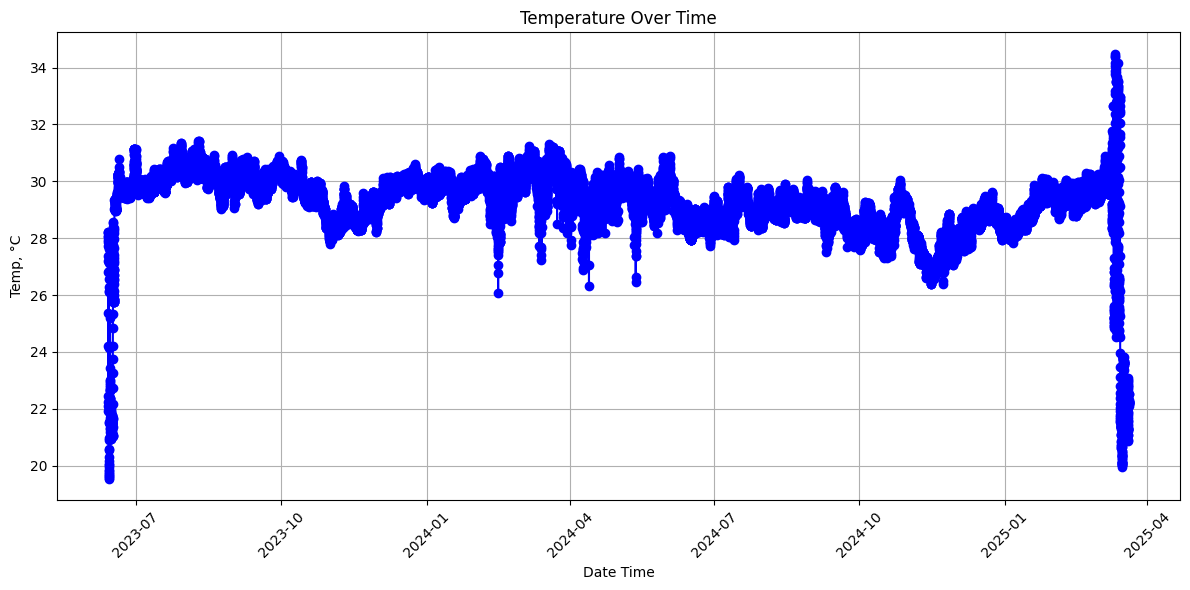

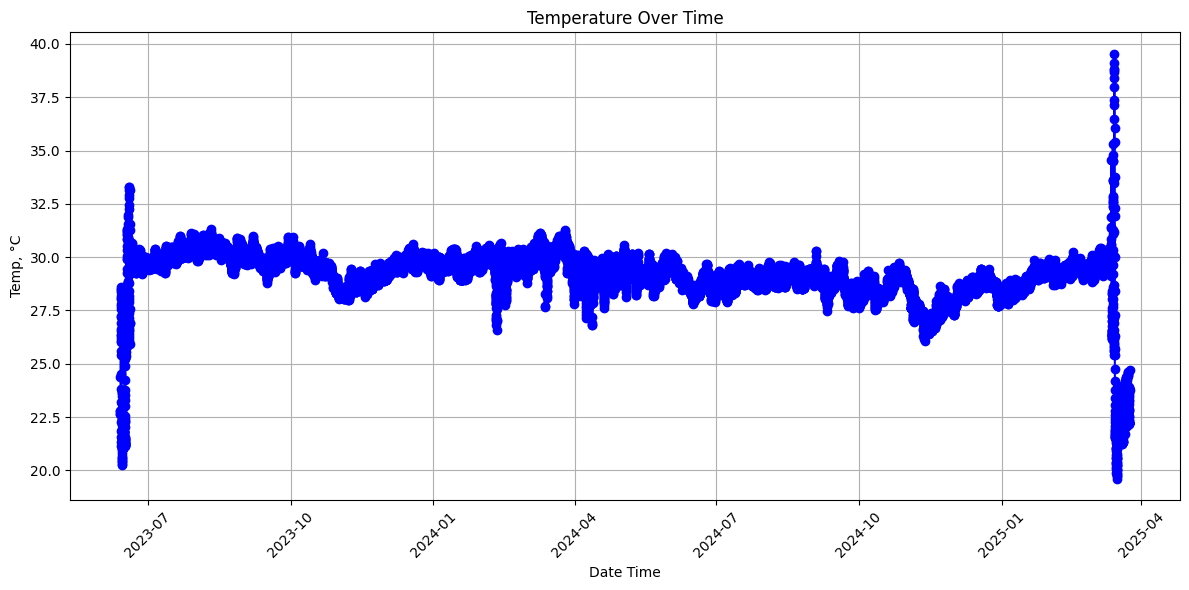

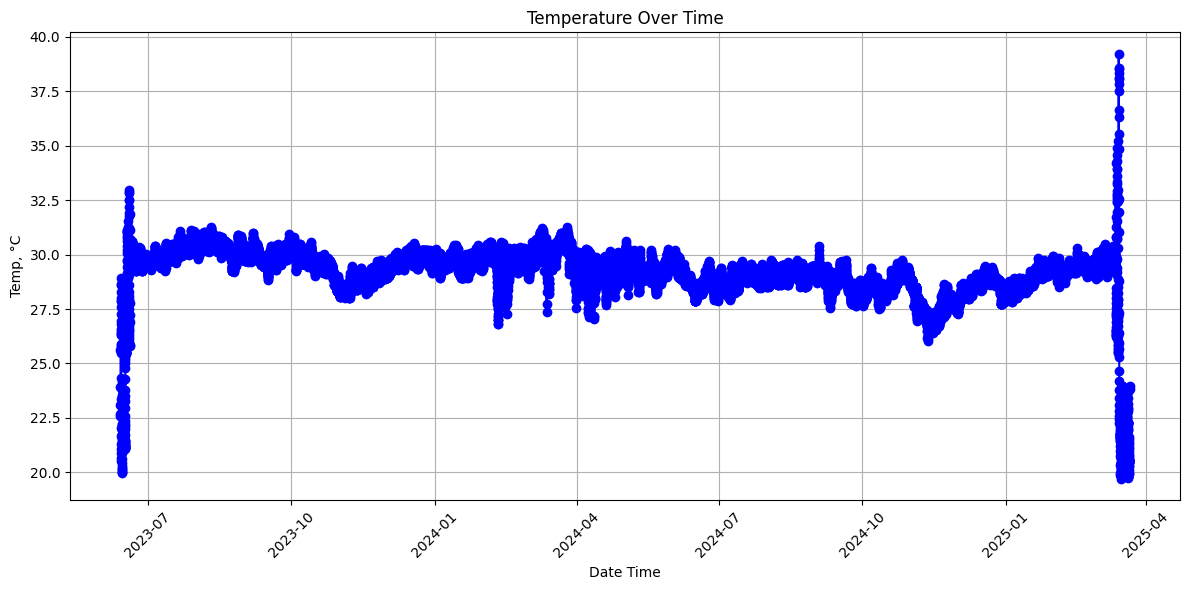

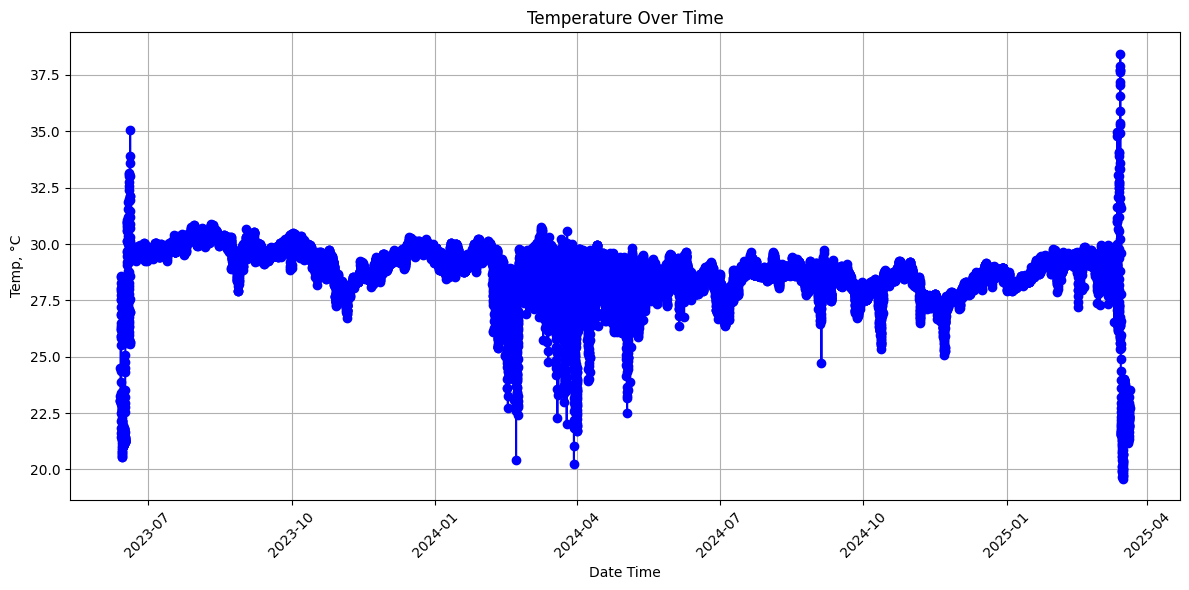

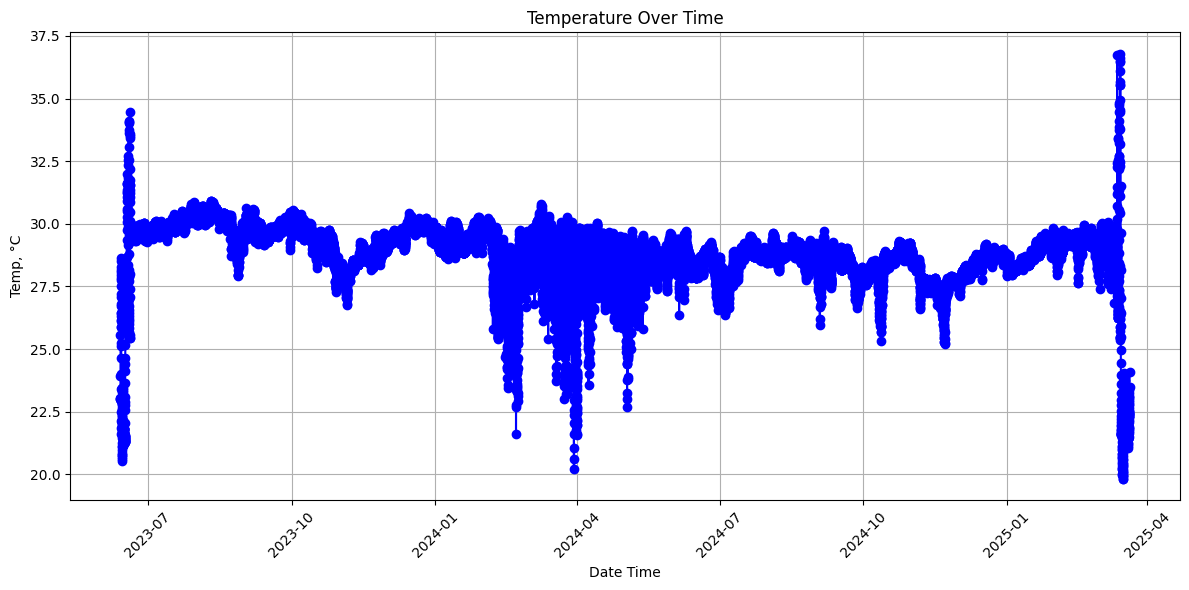

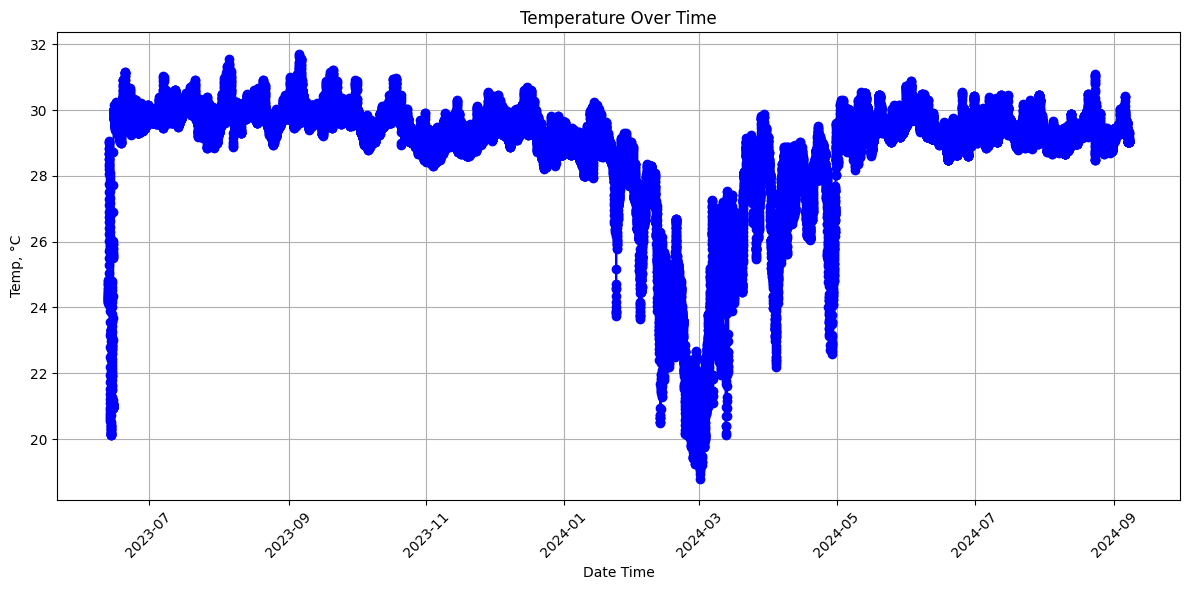

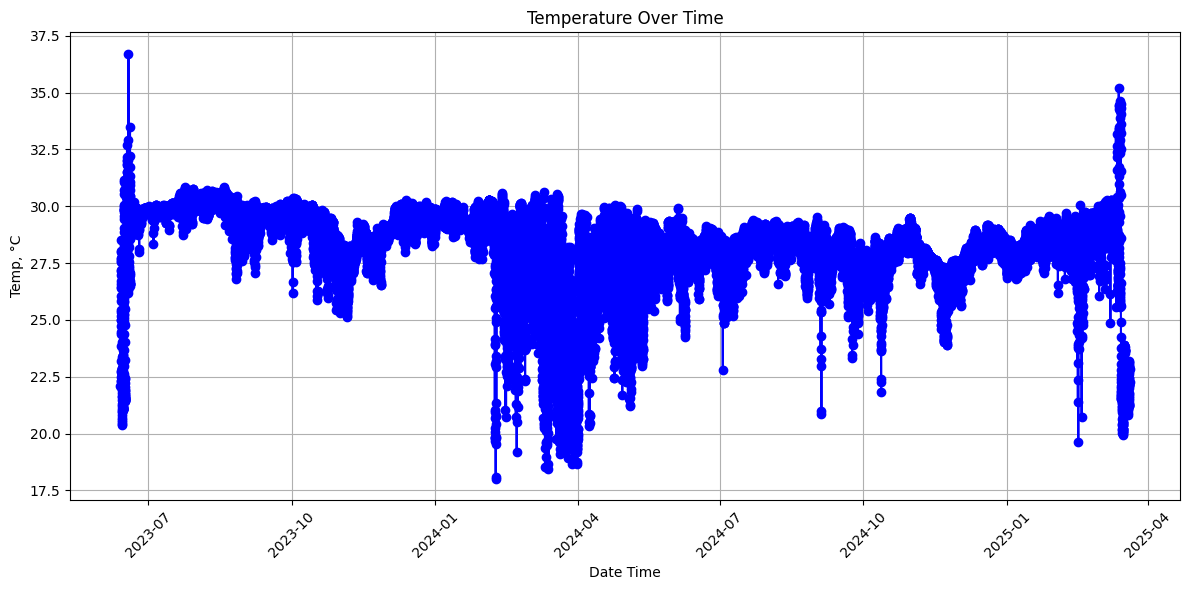

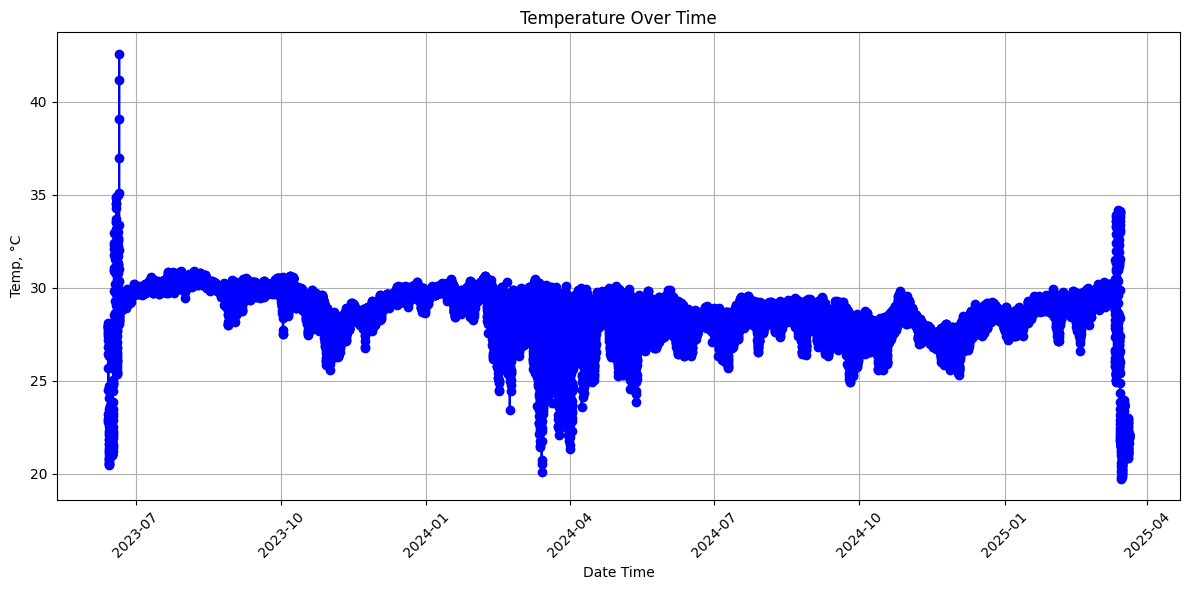

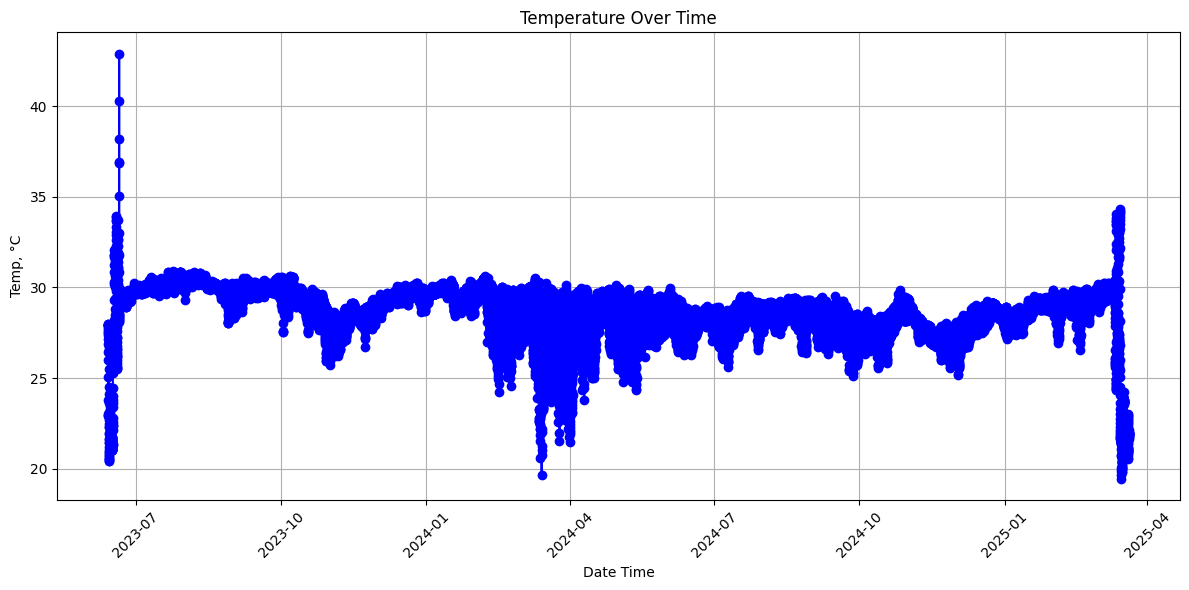

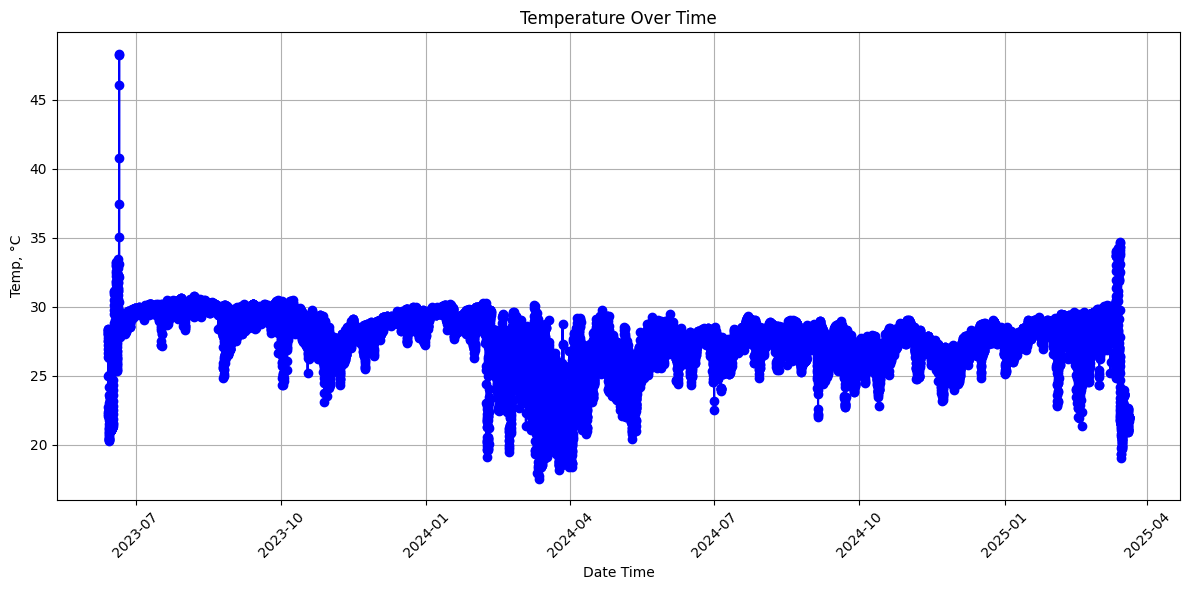

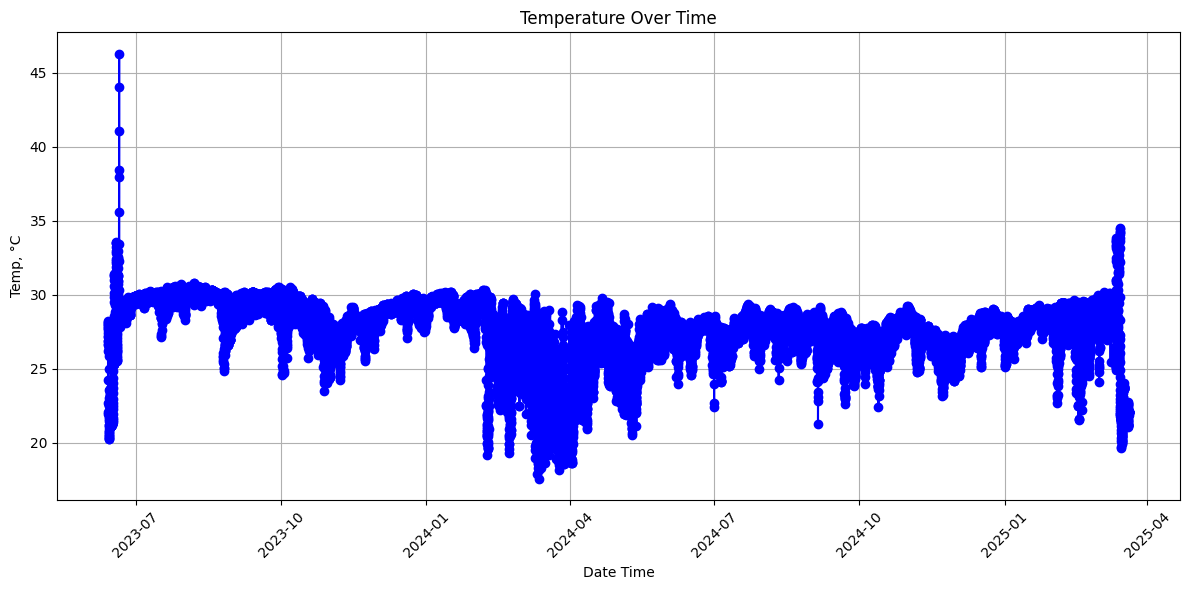

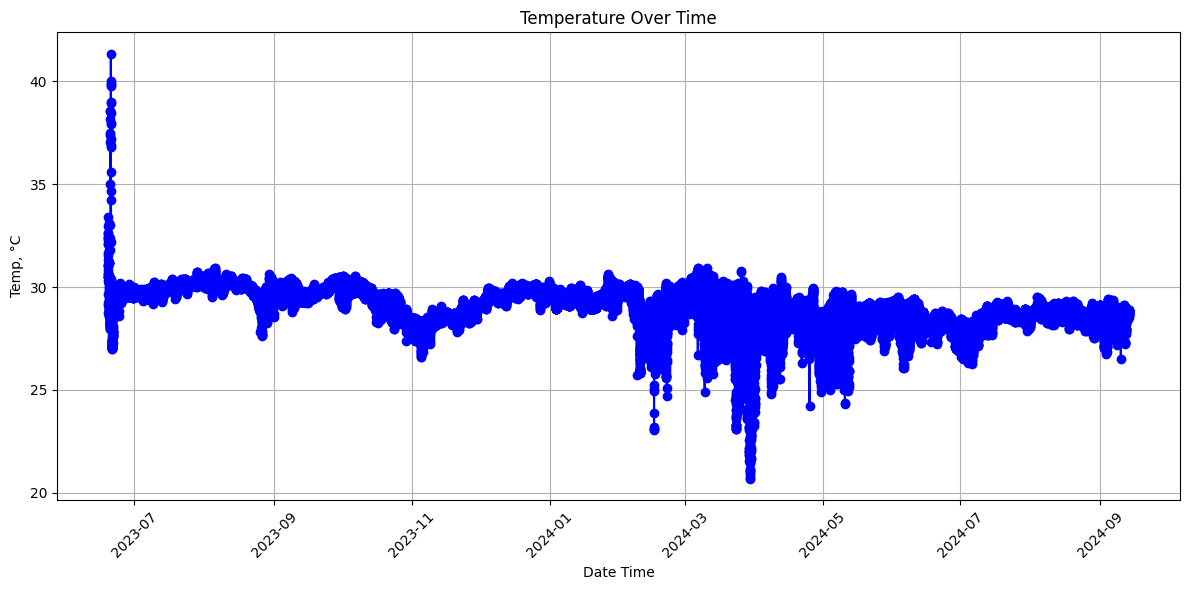

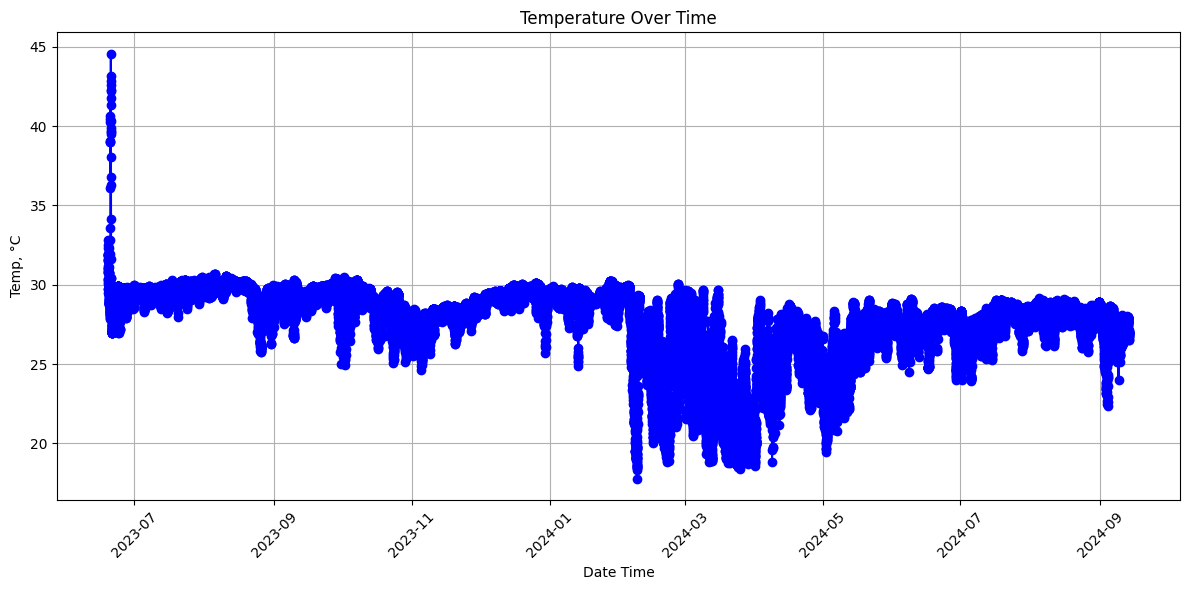

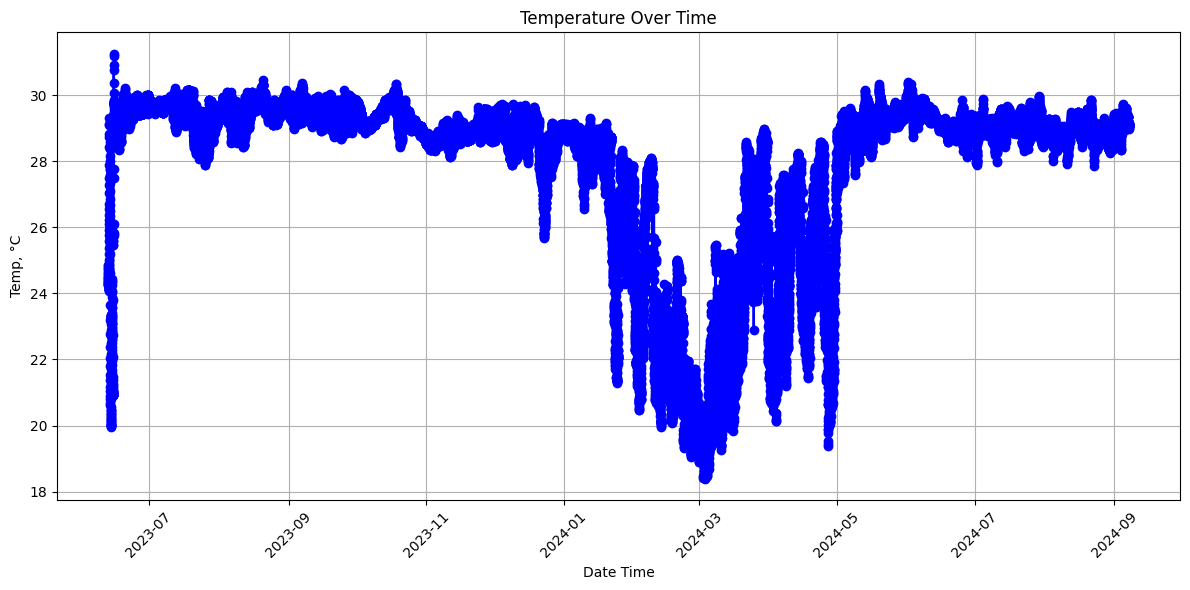

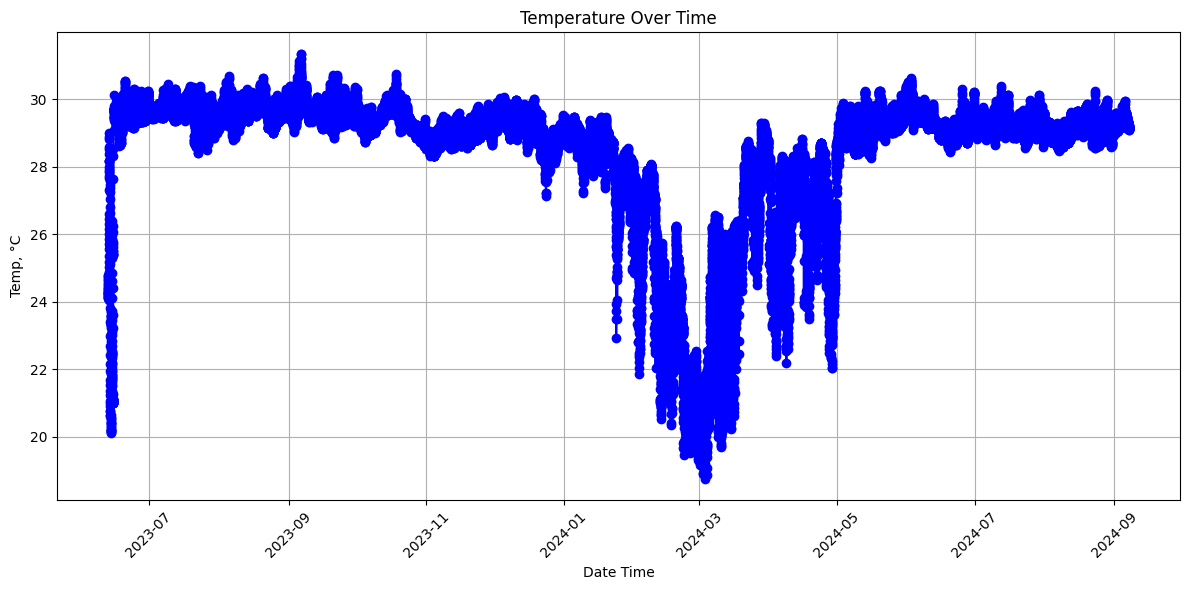

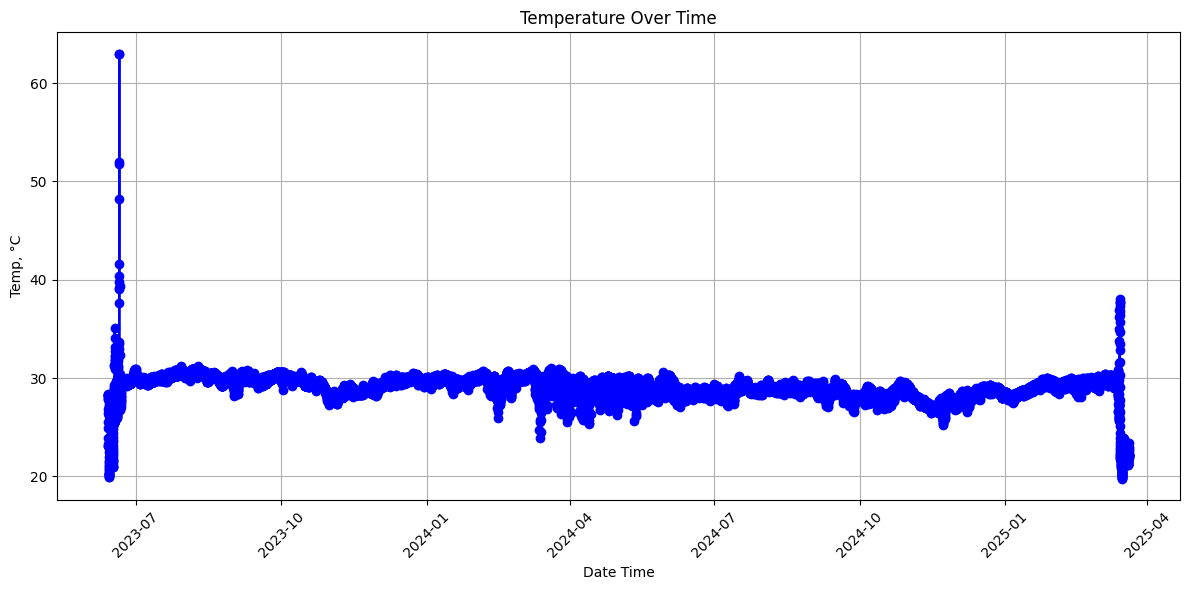

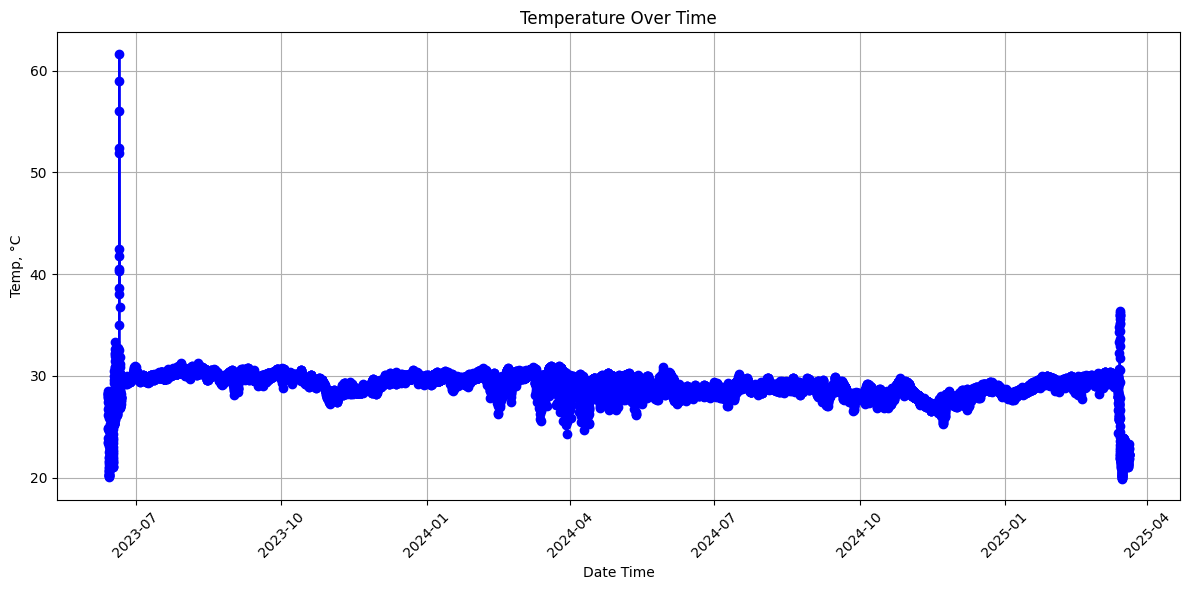

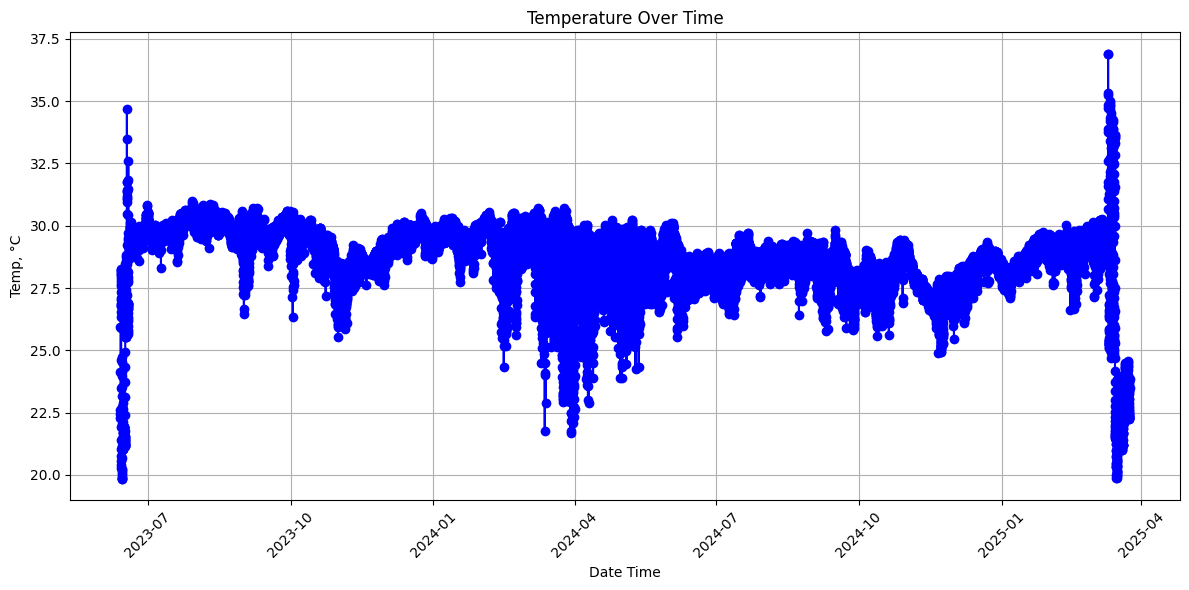

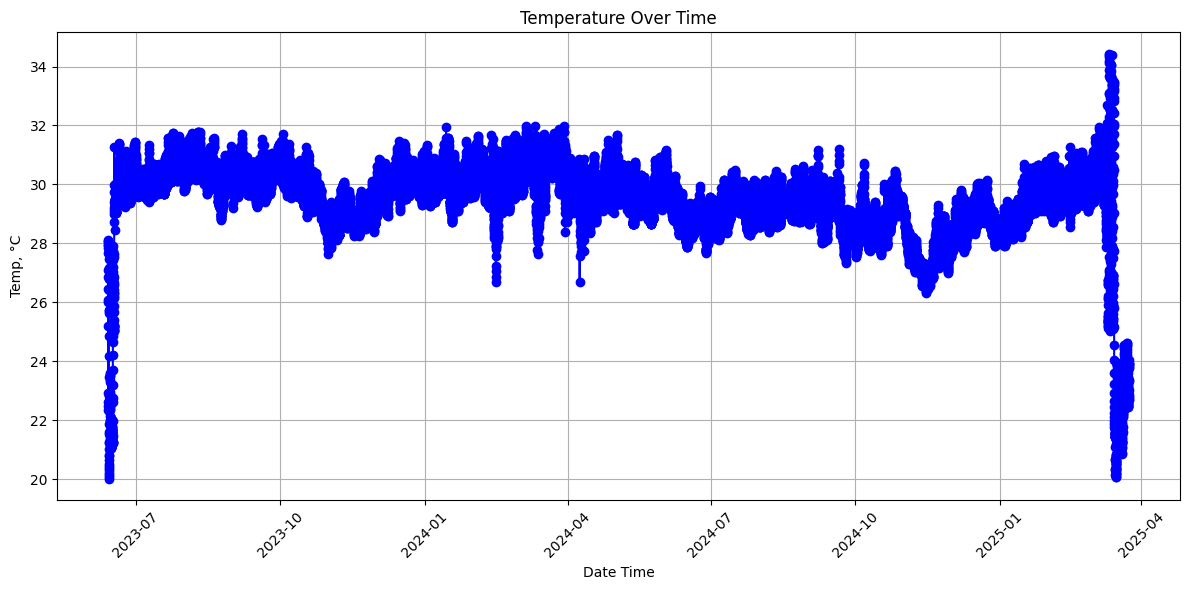

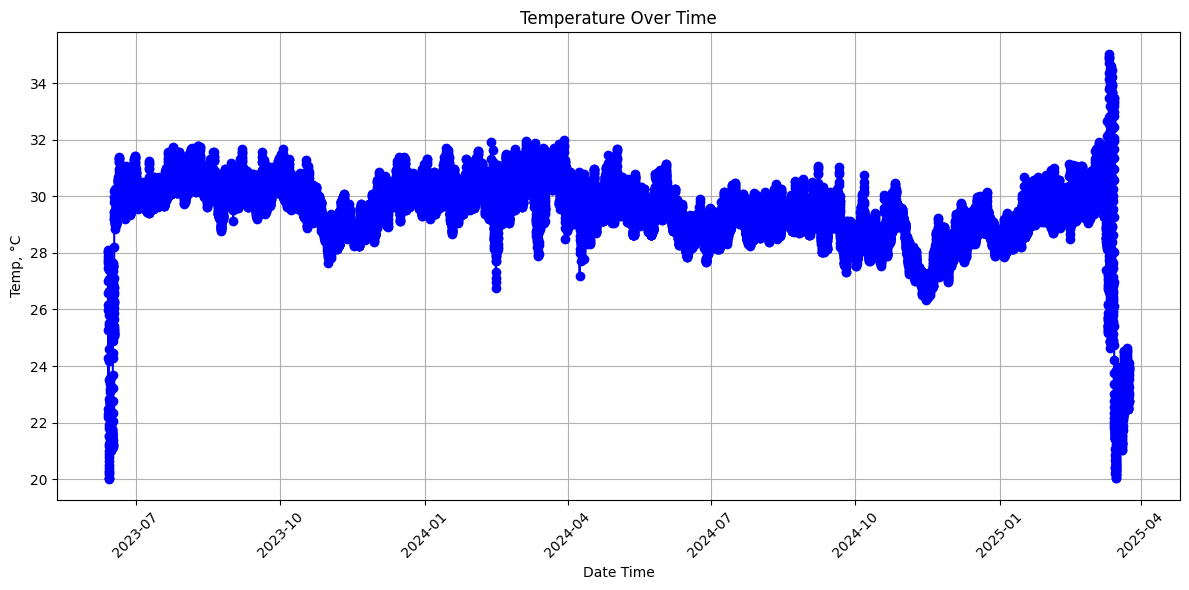

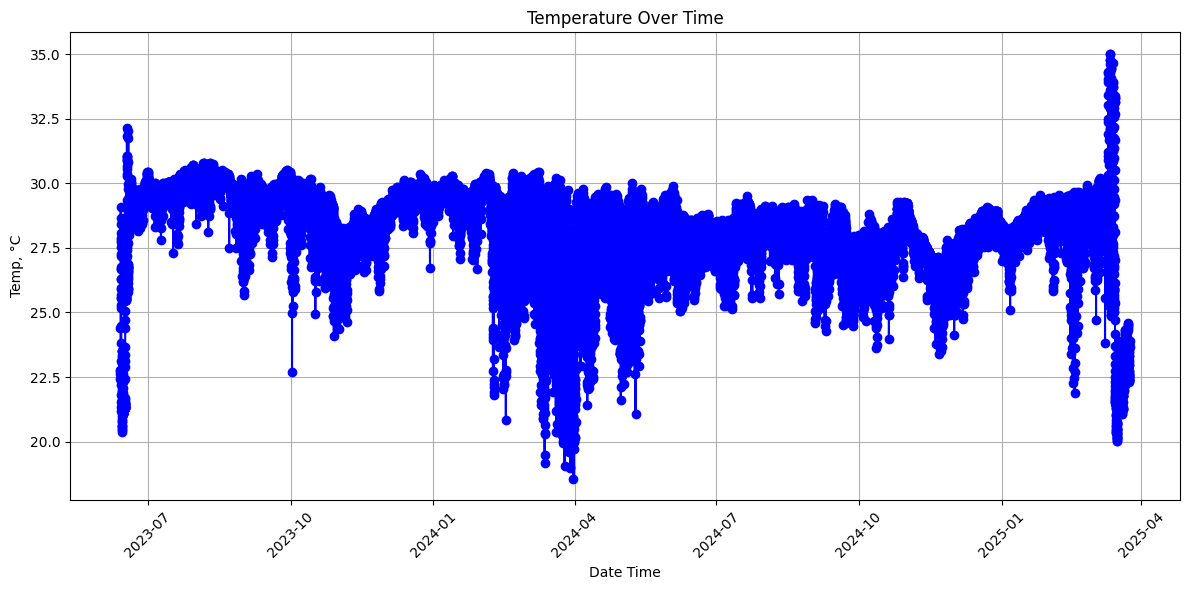

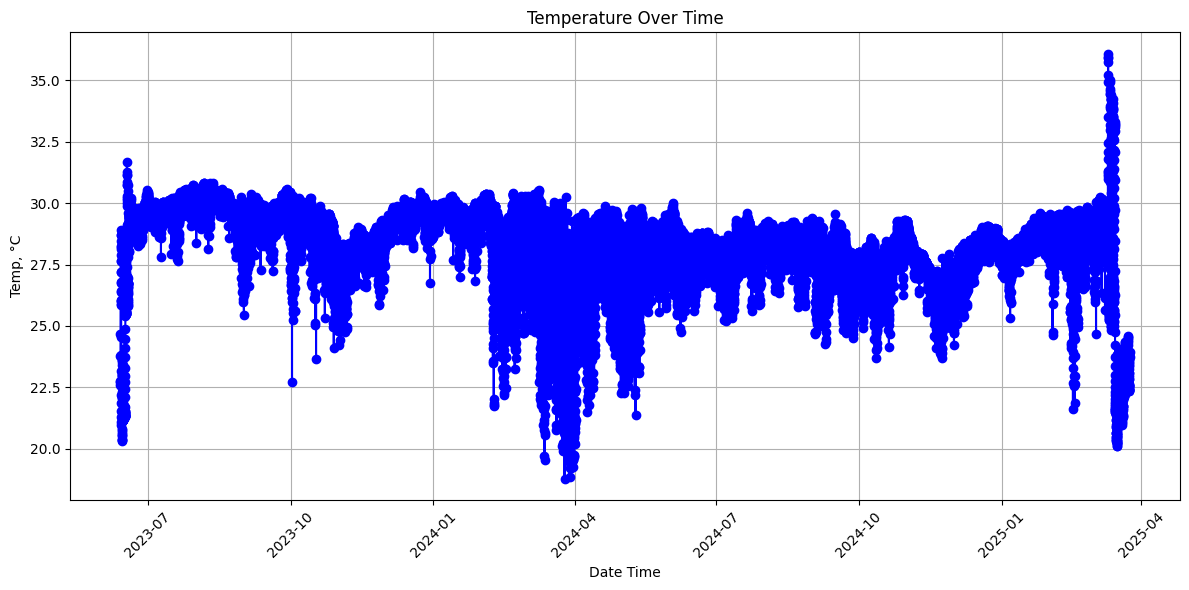

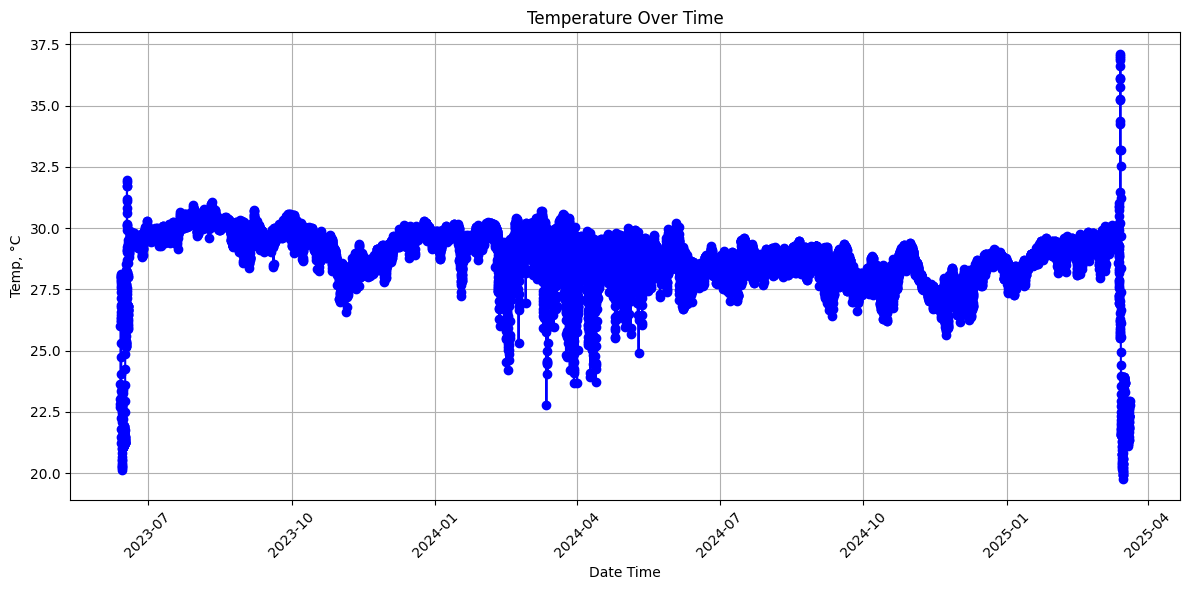

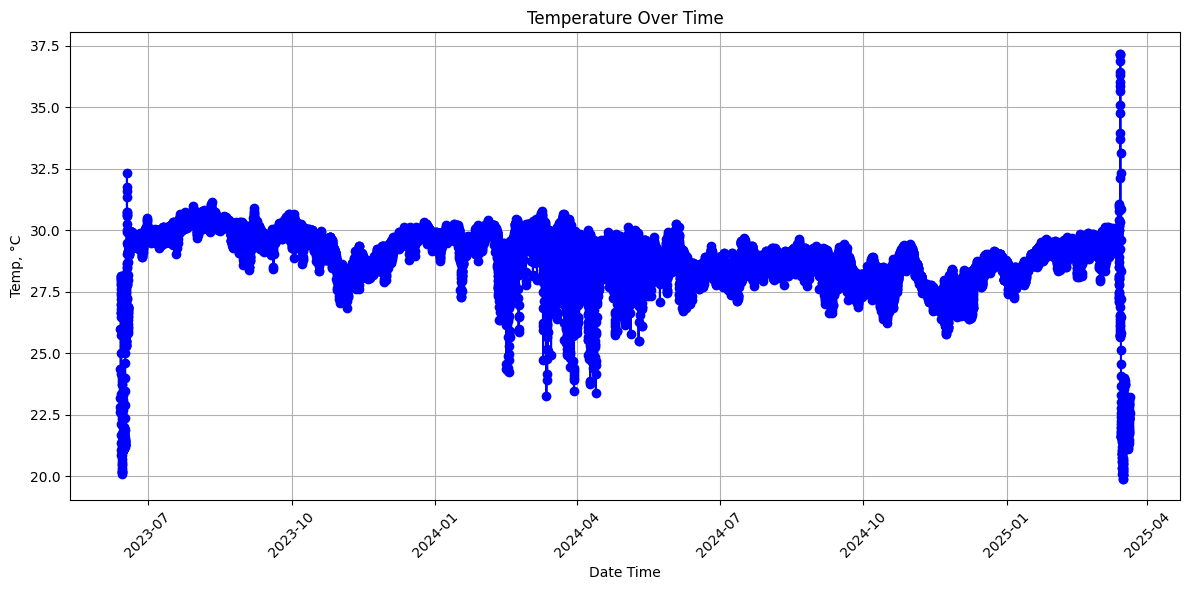

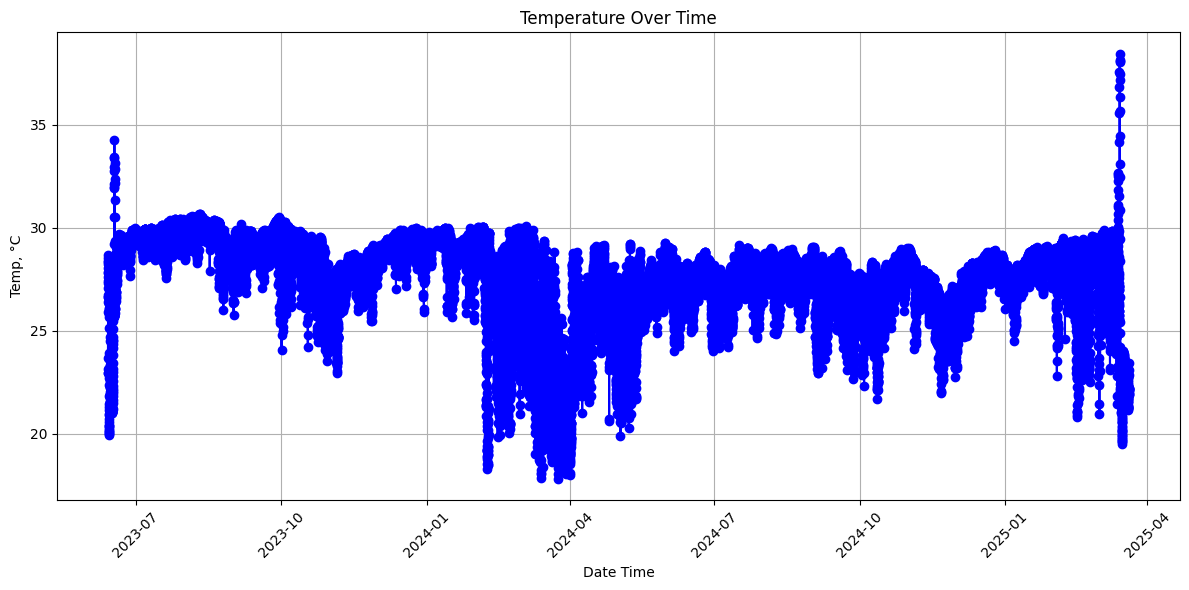

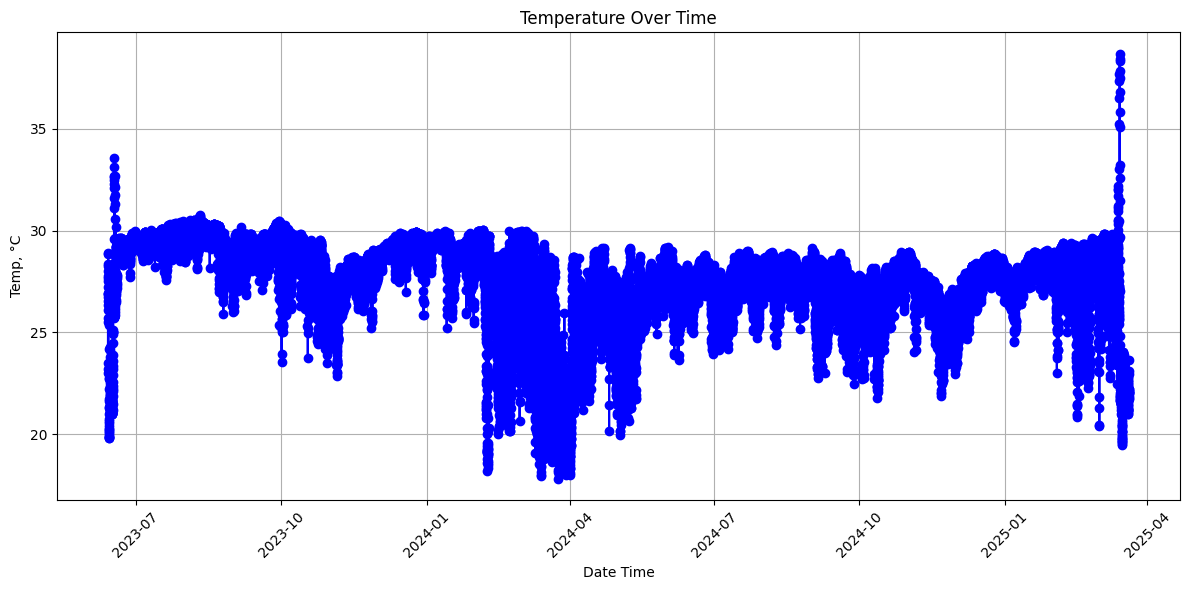

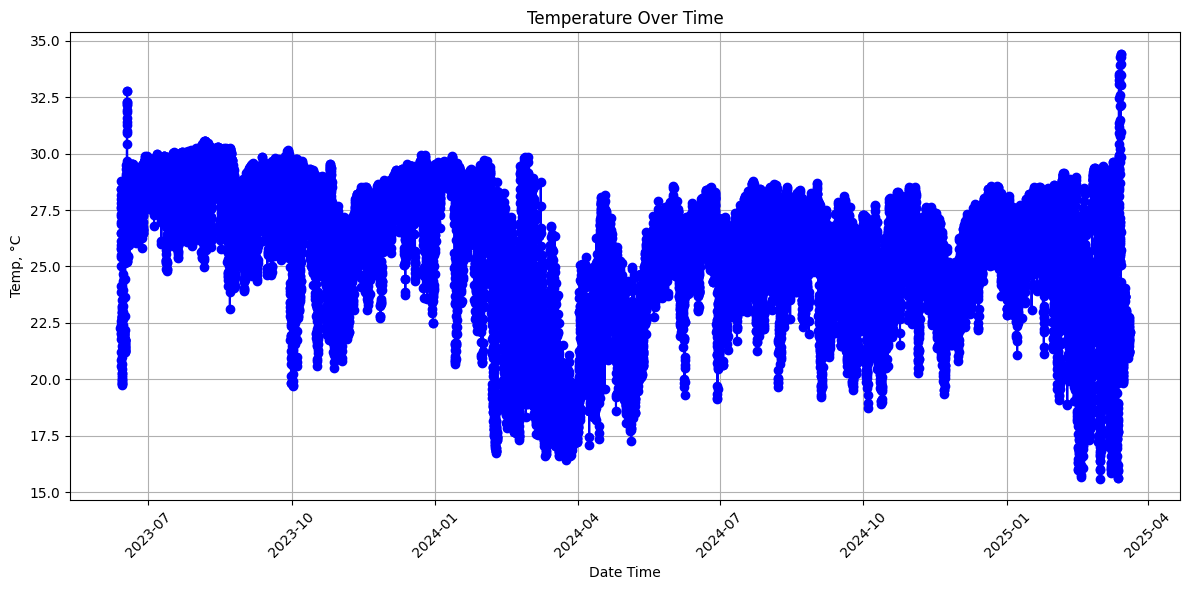

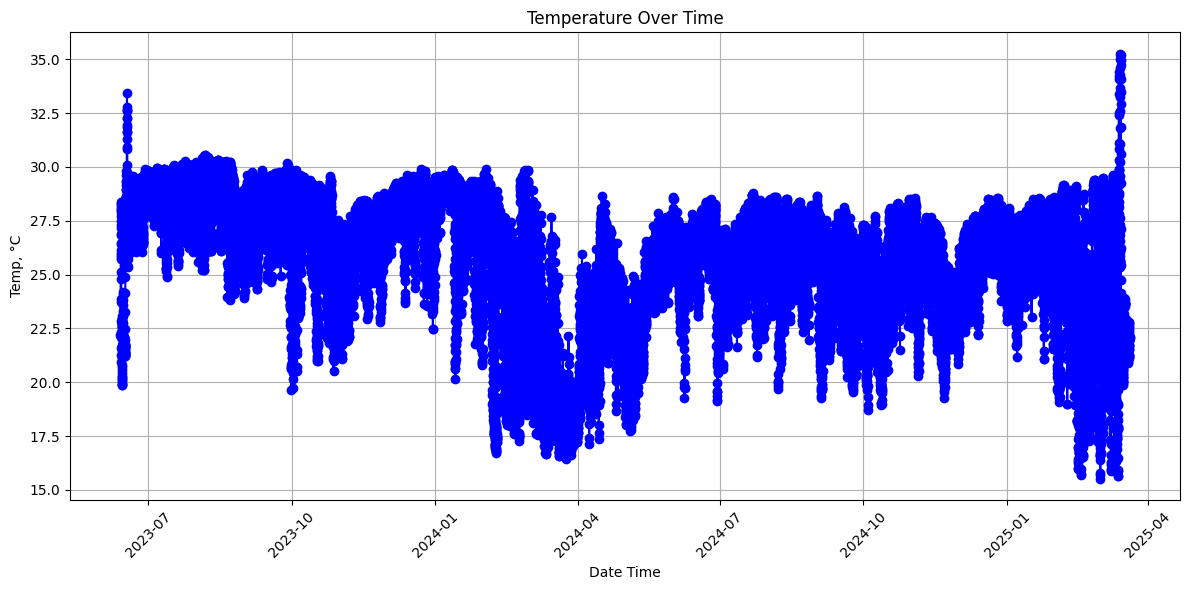

In [61]:
# Loop through df_files and plot graphs for each DataFrame
for site_code, site_data in df_files.items():
    for file_number, file_data in site_data.items():
        for file_identifier, file_info in file_data.items():
            # Get the DataFrame
            df = file_info['DataFrame']
            
            if site_code in panama_codes:
                date_column = "Date Time, GMT-05:00"
            else:
                date_column = "Date Time, GMT-04:00"
            
            # Convert the date column to datetime objects, specifying the format
            df[date_column] = pd.to_datetime(df[date_column], format='%m/%d/%y %H:%M:%S')

            # Plot the temperature over time
            plt.figure(figsize=(12, 6))
            plt.plot(df[date_column], df['Temp, °C'], color='blue', marker='o', linestyle='-')
            plt.title('Temperature Over Time')
            plt.xlabel('Date Time')
            plt.ylabel('Temp, °C')  # Modified label
            plt.grid(True)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()


### <b>Trim the data based on Date Time:
Trimming the data occurs in two steps, first is to trim the data based on the deployment log, then trim the data to account for human error. The cell below checks if the newly combined Date and Time values are a string and then formats it to a datetime object with the structure of m/d/y and h:m:s. 

In [62]:
#%% Trim Data Based on Date Time
# The data is being trimmed to the closest related start and endpoint 

# Convert timestamps to datetime objects in deployment_data_dict
for filename, file_info in deployment_data_dict.items():
    # Check if the values are already strings
    if isinstance(file_info['Date In Time In'], str):
        file_info['Date In Time In'] = datetime.strptime(file_info['Date In Time In'], '%m/%d/%y %H:%M:%S')
    if isinstance(file_info['Date Out Time Out'], str):
        file_info['Date Out Time Out'] = datetime.strptime(file_info['Date Out Time Out'], '%m/%d/%y %H:%M:%S')


### Trim part 1: deployment log
This cell trims the data based on the start and end times specified in the deployment log to the nearest point in the data

In [63]:
# Trim the data in each DataFrame based on the specified time range
for site_code, site_data in df_files.items():
    for file_number, file_data in site_data.items():
        for file_identifier, file_info in file_data.items():
            df = file_info['DataFrame']
            
            if site_code in panama_codes:
                date_column = "Date Time, GMT-05:00"
            else:
                date_column = "Date Time, GMT-04:00"
            
            # Convert the date column to datetime objects, specifying the format
            df[date_column] = pd.to_datetime(df[date_column], format='%m/%d/%y %H:%M:%S')
            
            # Filter the DataFrame based on the specified time range
            df = df[(df[date_column] >= deployment_data_dict[file_info['File Name']]['Date In Time In']) &
                    (df[date_column] <= deployment_data_dict[file_info['File Name']]['Date Out Time Out'])]
            
            # Update the DataFrame in df_files
            df_files[site_code][file_number][file_identifier]['DataFrame'] = df


### Trim part 2: account for human error
To remove the possibility of human error from deployment and retreival of the loggers, the loop iterates through the data frames and trims the first and last hour of the data. This section can be altered in the "trimmed_df = df.iloc[4:-5]" section based on outputs of graphing section of the code.

In [64]:
#%% Trim data down on both ends by an hour THIS SECTION CAN BE COMMENTED OUT IF FURTHER TRIMMING IS NOT REQUIRED.
# This is to eliminate any data errors from the removal and retrevial from the water.
# In terms of data processing it may be better to eliminate human error and just inerpolate these points
# When connecting the data to previous data. 

# Loop through each site code, file number, and file identifier in df_files
for site_code, site_data in df_files.items():
    for file_number, file_data in site_data.items():
        for file_identifier, file_info in file_data.items():
            # Get the DataFrame for the current file
            df = file_info['DataFrame']
            
            # Reduce the number of start points 4 and end points by 5 on each end of the DataFrame
            trimmed_df = df.iloc[4:-5]
            
            # Update the DataFrame in df_files
            df_files[site_code][file_number][file_identifier]['DataFrame'] = trimmed_df

### Checking the lengths:
This loop makes sure that the number of rows for each site code are the same to ensure that they can be merged and then averaged. This would be the point to check for differences in time interval between the data pairs. If time interval is different they should have already been labeled as offset and handled.

In [65]:
#%% Checks to see if the "a" and "b" files and the "c" and "d" files have the same number of data points

# Iterate through each site code
for site_code, file_numbers in df_files.items():
    # Iterate through each file number
    for file_number, identifiers in file_numbers.items():
        # Check if there are multiple file identifiers for the file number
        if len(identifiers) > 1:
            # Get the number of rows for each DataFrame
            num_rows = {identifier: info['DataFrame'].shape[0] for identifier, info in identifiers.items()}
            
            # Check if files associated with the file number have different numbers of data points
            if len(set(num_rows.values())) != 1:
                print(f"Site code: {site_code}, File number: {file_number} have files with different numbers of data points:")
                for identifier, count in num_rows.items():
                    print(f"  - {identifier}: {count} data points")
            else:
                print(f"Site code: {site_code}, File number: {file_number} have files with the same number of data points: {next(iter(num_rows.values()))}.")


Site code: PCAR03, File number: 2306 have files with different numbers of data points:
  - c: 30331 data points
  - d: 30330 data points
Site code: PCAW10, File number: 2306 have files with different numbers of data points:
  - c: 30323 data points
  - d: 30322 data points
Site code: PDG10M, File number: 2306 have files with different numbers of data points:
  - c: 30226 data points
  - d: 30227 data points
Site code: PDG20M, File number: 2306 have files with the same number of data points: 30226.
Site code: PUVCCP, File number: 2306 have files with the same number of data points: 30324.
Site code: PUVFLT, File number: 2306 have files with different numbers of data points:
  - c: 30278 data points
  - d: 30279 data points
Site code: PUVM18, File number: 2306 have files with the same number of data points: 30271.
Site code: PUVR10, File number: 2306 have files with different numbers of data points:
  - c: 30423 data points
  - d: 30422 data points
Site code: PUVR20, File number: 2306 ha

### Calculations check:
To merge the duplicate temperature columns, the difference between each temperature must be checked before they can be averaged. After checking if there is an a and b file for each site code, the code then takes the absoulte value of the difference between them. <u>Offset files won't have any calculations<u>

In [66]:
#%% Check to see if there is a .2 degrees difference then average the two columns and record the site codes where this occured 
# Also take the average between the two temperature columns if the difference is less than or equal to .2 degrees.
# Use the new average temperature column as the temperature column 
# Iterate through each site code
for site_code, file_numbers in df_files.items():
    # Iterate through each file number
    for file_number, identifiers in file_numbers.items():
        # Check if there are both 'a' and 'b' files for the current site code and file number
        if 'a' in identifiers and 'b' in identifiers:
            # Get the 'a' and 'b' dataframes
            df_a = identifiers['a']['DataFrame']
            df_b = identifiers['b']['DataFrame']
            
            # Check if the temperature columns exist in both dataframes
            if 'Temp, °C' in df_a.columns and 'Temp, °C' in df_b.columns:
                # Calculate the temperature difference
                df_a['Temperature_Difference'] = (df_a['Temp, °C'] - df_b['Temp, °C'])
            else:
                print(f"Temperature columns not found for Site: {site_code}, File Number: {file_number}")
        else:
            print(f"Only one file for Site: {site_code}, File Number: {file_number}, so averaging could not occur")

Only one file for Site: PAUVGC, File Number: 2306, so averaging could not occur
Only one file for Site: PCAR03, File Number: 2306, so averaging could not occur
Only one file for Site: PCAW10, File Number: 2306, so averaging could not occur
Only one file for Site: PCO3M, File Number: 2306, so averaging could not occur
Only one file for Site: PCT18M, File Number: 2306, so averaging could not occur
Only one file for Site: PDG10M, File Number: 2306, so averaging could not occur
Only one file for Site: PDG20M, File Number: 2306, so averaging could not occur
Only one file for Site: PIG10M, File Number: 2306, so averaging could not occur
Only one file for Site: PIG20M, File Number: 2306, so averaging could not occur
Only one file for Site: PSA11M, File Number: 2306, so averaging could not occur
Only one file for Site: PSA3M, File Number: 2306, so averaging could not occur
Only one file for Site: PUVCCP, File Number: 2306, so averaging could not occur
Only one file for Site: PUVF10, File Numbe

### Calculations:
The files whose temperatures had a greater difference than 0.2 needs to be labeled as calculations for futher manual investigation. An empty dictionary named calculations is created then after checking that the files with the temperature difference column exists, they are stored in the dictionary. The end of the code then prints the names of these files that were labeled as calculations.

In [67]:
#%%
# Create an empty dictionary to store calculations
calculations = {}

# Iterate through each site code
for site_code, file_numbers in df_files.items():
    # Iterate through each file number
    for file_number, identifiers in file_numbers.items():
        # Check if the 'a' identifier exists for the current site code and file number
        if 'a' in identifiers:
            # Get the 'a' dataframe
            df_a = identifiers['a']['DataFrame']
            
            # Check if the 'Temperature_Difference' column exists in the dataframe
            if 'Temperature_Difference' in df_a.columns:
                # Check for Temperature_Difference > 0.4
                high_difference = df_a[df_a['Temperature_Difference'] > 0.4]
                
                # Check for Temperature_Difference > 0.2 with flag count > 68
                moderate_difference = df_a[df_a['Temperature_Difference'] > 0.2]
                
                # If either condition is met, add to calculations
                if not high_difference.empty or len(moderate_difference) >= 68:
                    # Get the file name associated with the 'a' dataframe
                    file_name = identifiers['a']['File Name']
                    
                    # Store site code, file number, and file name in the calculations dictionary
                    calculations[(site_code, file_number)] = file_name
            #else:
            #    print(f"Temperature_Difference column not found for Site: {site_code}, File Number: {file_number}")

print()
print('These are the files that need to be labeled as calculations:')
for key, value in calculations.items():
    print(key, value)


These are the files that need to be labeled as calculations:


### Copy df_files
Used for calculations comparisons

In [30]:
calc_df = df_files

### Create a new dictionary for calculation comparisons
This cell makes a new nested dictionary to extract the dataframes from df_files marked for calculations so they can be manipulated with out disturbing the original data structure. 

In [31]:
# Initialize an empty dictionary to store DataFrames corresponding to calculations
calc_df_files = {}

# Iterate through each key-value pair in the calculations dictionary
for (site_code, file_number), file_name in calculations.items():
    # Check if the site code exists in calc_df dictionary
    if site_code in calc_df:
        # Check if the file number exists for the site code
        if file_number in calc_df[site_code]:
            for identifier in ['a', 'b']:  # Iterate through both 'a' and 'b' identifiers
                # Extract the DataFrame corresponding to the identifier from df_files dictionary
                df = calc_df[site_code][file_number].get(identifier)
                if df is not None:
                    # Create a nested dictionary entry in calc_df_files
                    if site_code not in calc_df_files:
                        calc_df_files[site_code] = {}
                    if file_number not in calc_df_files[site_code]:
                        calc_df_files[site_code][file_number] = {}
                    calc_df_files[site_code][file_number][identifier] = df
        else:
            print(f"File number {file_number} not found for site code {site_code} in calc_df.")
    else:
        print(f"Site code {site_code} not found in calc_df.")

# Now, calc_df_files will contain the DataFrames corresponding to the files listed in the calculations dictionary, including both 'a' and 'b' identifiers.

### Create comparison columns for calculations
This cell iterates through the dataframes in calc_df_files, and adds the temperature column from the _b dataframe to the _a dataframe. These columns are then renamed as Temp A and Temp B.

In [32]:
# Iterate through each site code
for site_code, file_numbers in calc_df_files.items():
    # Iterate through each file number
    for file_number, identifiers in file_numbers.items():
        if 'a' in identifiers:
            # Get the dataframe calc_a
            calc_a = identifiers['a']['DataFrame']
            calc_b = identifiers['b']['DataFrame']
            
            # Add the temp column from b to a and rename both
            calc_a["Temp A"] = calc_a.loc[:, "Temp, °C"]
            calc_a["Temp B"] = calc_b.loc[:, "Temp, °C"]
            
            #Add the average column
            calc_a["Average_temp"] = (calc_a['Temp A'] + calc_a['Temp B'])/2

            # Add a flag column with "FLAG" if the condition is True, else blank
            calc_a['Flag'] = calc_a["Temperature_Difference"].apply(lambda x: "FLAG" if x > 0.2 else "")
            

            # Print calc_a
            print(f"DataFrame for Site Code: {site_code}, File Number: {file_number} (calc_a)")
            print(calc_a)
            print("\n")

### Report number of "true" flags for each calculations file
Shows the number of cells where the difference in temperature is greater than 0.2

In [33]:
# Iterate through each site code
for site_code, file_numbers in calc_df_files.items():
    # Iterate through each file number
    for file_number, identifiers in file_numbers.items():
        if 'a' in identifiers:
            # Get the dataframe calc_a
            calc_a = identifiers['a']['DataFrame']
            
            # Count the number of 'True' values in the 'Flag' column
            true_count = calc_a['Flag'].astype(str).value_counts().get('True', 0)
            
            # Initialize variables for temperature difference reporting
            temp_diff_count = 0
            temp_diff_values = []
            
            # Check if the 'Temperature_Difference' column exists
            if 'Temperature_Difference' in calc_a.columns:
                # Get the count of Temperature_Difference > 0.4
                temp_diff_count = (calc_a['Temperature_Difference'] > 0.4).sum()
                
                # Extract and round the values of Temperature_Difference > 0.4
                temp_diff_values = calc_a.loc[
                    calc_a['Temperature_Difference'] > 0.4, 'Temperature_Difference'
                ].round(4).tolist()
            
            # Print the results
            print(f"{site_code} {file_number}, Number of 'True' values flagged: {true_count}, Temperature Difference > 0.4 Count: {temp_diff_count}")
            if temp_diff_values:
                print(f"  Values of Temperature Difference > 0.4: {temp_diff_values}")

### Offload calculation comparisons
This cell will offload the files marked as calculations. Each file will have the number, date time, and two temperature columns for comparison and the difference between them. These files will then be uploaded to the calculations folder on the google drive for the year specified.

<l><u>Make sure to update the working directory!

In [ ]:
# Define the output folder where you want to save the extracted files
output_folder = r"C:\UVI\QAQC stuff\Temp_Panama_2025_Output"

# Define the calculations folder within the output folder
calculations_folder = os.path.join(output_folder, "Provisional Duplicates")

# Create the calculations folder if it doesn't exist
if not os.path.exists(calculations_folder):
    os.makedirs(calculations_folder)

# Iterate through each site code
for site_code, file_numbers in calc_df_files.items():
    # Iterate through each file number
    for file_number, identifiers in file_numbers.items():
        # Check if 'a' identifier exists
        if 'a' in identifiers:
            # Get the dataframe calc_a
            calc_a = identifiers['a']['DataFrame']
            
            # Get the year and month of the first and last data points
            first_data_point = calc_a['Date Time, GMT-04:00'].iloc[0]
            last_data_point = calc_a['Date Time, GMT-04:00'].iloc[-1]
            year_month_first = first_data_point.strftime("%y%m")  # Using last two digits of the year
            year_month_last = last_data_point.strftime("%y%m")    # Using last two digits of the year
            
            # Construct the base file name
            base_file_name = f"BT_{site_code}_{year_month_first}_{year_month_last}"
            
            # Construct the output file name for 'a' file
            output_file_name = f"PD_{base_file_name}.csv"
            output_file_path = os.path.join(calculations_folder, output_file_name)
            
            # Drop unnecessary columns from calc_a
            calc_a = calc_a[['#', 'Date Time, GMT-04:00', 'Temp A', 'Temp B', 'Temperature_Difference','Average_temp','Flag']]
            
            # rename GMT to UTC
            calc_a.rename(columns={'Date Time, GMT-04:00': 'Date Time, UTC-04:00'}, inplace=True)

            # Save the 'a' DataFrame to CSV
            calc_a.to_csv(output_file_path, index=False)
            
            print(f"File saved: Site: {site_code}, File Number: {file_number}, Path: {output_file_path}")
        else:
            print(f"No 'a' version found for Site: {site_code}, File Number: {file_number}")

C:\Users\magic\AppData\Local\Temp\ipykernel_15036\3255905430.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  calc_a.rename(columns={'Date Time, GMT-04:00': 'Date Time, UTC-04:00'}, inplace=True)
C:\Users\magic\AppData\Local\Temp\ipykernel_15036\3255905430.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  calc_a.rename(columns={'Date Time, GMT-04:00': 'Date Time, UTC-04:00'}, inplace=True)
C:\Users\magic\AppData\Local\Temp\ipykernel_15036\3255905430.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pa

File saved: Site: TCBKPT, File Number: 2402, Path: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\Provisional Duplicates\PD_BT_TCBKPT_2402_2410.csv
File saved: Site: TCCB08, File Number: 2403, Path: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\Provisional Duplicates\PD_BT_TCCB08_2403_2411.csv
File saved: Site: TCFLTC, File Number: 2402, Path: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\Provisional Duplicates\PD_BT_TCFLTC_2402_2410.csv
File saved: Site: TCSHCS, File Number: 2403, Path: C:\UVI\QAQC stuff\Temp_TCRMP_2025_Output\Provisional Duplicates\PD_BT_TCSHCS_2403_2410.csv


C:\Users\magic\AppData\Local\Temp\ipykernel_15036\3255905430.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  calc_a.rename(columns={'Date Time, GMT-04:00': 'Date Time, UTC-04:00'}, inplace=True)


### Averaging:
If the difference is 0.2 or less, the old temperature columns are dropped and replaced by the averaged one. If the difference is greater than 0.2 the columns are not averaged and are left blank to be identified in a later cell.

In [34]:
#%% Check to see if there is a .2 degrees difference then average the two columns and record the site codes where this occured 
# Also take the average between the two temperature columns if the difference is less than or equal to .2 degrees.
# Use the new average temperature column as the temperature column 
# Iterate through each site code
for site_code, file_numbers in df_files.items():
    # Iterate through each file number
    for file_number, identifiers in file_numbers.items():
        # Check if there are both 'a' and 'b' files for the current site code and file number
        if 'a' in identifiers and 'b' in identifiers:
            # Get the 'a' and 'b' dataframes
            df_a = identifiers['a']['DataFrame']
            df_b = identifiers['b']['DataFrame']
            
            # Check if the temperature columns exist in both dataframes
            if 'Temp, °C' in df_a.columns and 'Temp, °C' in df_b.columns:
                # Calculate the average temperature between the two temperature columns of "a" and "b" if the temperature difference is .2 or below
                df_a['Average_Temperature'] = df_a.apply(
                    lambda row: (row['Temp, °C'] + df_b.loc[row.name,'Temp, °C']) / 2 if row['Temperature_Difference'] <= 0.2 else None,
                    axis=1
                )
                # Drop the old 'Temp, °C' column to replace with new average column
                df_a.drop(columns=['Temp, °C'], inplace=True)
                
                # Rename the Average Temperature column
                df_a.rename(columns={'Average_Temperature': 'Temp, °C'}, inplace=True)
                
            else:
                print(f"Temperature columns not found for Site: {site_code}, File Number: {file_number}")
        else:
            print(f"Only one file for Site: {site_code}, File Number: {file_number}, so averaging could not occur")

Only one file for Site: PAUVGC, File Number: 2306, so averaging could not occur
Only one file for Site: PCAR03, File Number: 2306, so averaging could not occur
Only one file for Site: PCAW10, File Number: 2306, so averaging could not occur
Only one file for Site: PCO3M, File Number: 2306, so averaging could not occur
Only one file for Site: PCT18M, File Number: 2306, so averaging could not occur
Only one file for Site: PDG10M, File Number: 2306, so averaging could not occur
Only one file for Site: PDG20M, File Number: 2306, so averaging could not occur
Only one file for Site: PIG10M, File Number: 2306, so averaging could not occur
Only one file for Site: PIG20M, File Number: 2306, so averaging could not occur
Only one file for Site: PSA11M, File Number: 2306, so averaging could not occur
Only one file for Site: PSA3M, File Number: 2306, so averaging could not occur
Only one file for Site: PUVCCP, File Number: 2306, so averaging could not occur
Only one file for Site: PUVF10, File Numbe

### Show NaNs for calculations:
During the averaging for the temperature difference, points where the temperature difference was above 0.2 were not averaged and left empty as NaN. The code below prints the number of points where the temperature difference was above 0.2 degrees for calculations file.

In [35]:
#%% Print the number of NaNs to show the number of points that are above a .2 temperature difference
# The number of NaNs represents the number of points where the temperature difference was above .2

# Iterate through each file in calculations
for (site_code, file_number), file_name in calculations.items():
    # Get the 'a' dataframe associated with the file
    df_a = df_files[site_code][file_number]['a']['DataFrame']

    # Check if the dataframe and the 'Temp, °C' column exist
    if df_a is not None and 'Temp, °C' in df_a.columns:
        # Count the number of NaNs in the 'Temp, °C column
        nan_count = df_a['Temp, °C'].isna().sum()

        # Print the file details and the NaN count
        print(f"For file {file_name}") 
        print(f"{nan_count} is the number of points where the temperature difference was above .2°C")
        print()


### Drop unesscessary columns:
In the SOP, every .csv file must only contain the '#'. 'Date Time, GMT-04:00', and 'Temp, °C' columns and so the code loops through each file identifier so that each file will drop all other columns.

In [69]:
#%% Drop columns
# Iterate through each site code
for site_code, file_numbers in df_files.items():
    # Determine the correct date column based on whether the site is in Panama codes
    if site_code in panama_codes:
        date_col = 'Date Time, GMT-05:00'
    else:
        date_col = 'Date Time, GMT-04:00'

    # Iterate through each file number
    for file_number, identifiers in file_numbers.items():
        # Check if there are both 'a' and 'b' files for the current site code and file number
        if 'a' in identifiers:
            # Get the 'a' dataframe
            df_a = identifiers['a']['DataFrame']

            # Drop all columns except '#', date_col, and 'Temp, °C'
            columns_to_keep = ['#', date_col, 'Temp, °C']
            df_a = df_a[columns_to_keep]
            # Rename columns if needed (uncomment the next line if desired)
            # df_a = df_a.rename(columns={'#': 'number', date_col: 'Date Time', 'Temp, °C': 'Temp C'})

            # Update the dataframe in df_files
            df_files[site_code][file_number]['a']['DataFrame'] = df_a

            if 'b' in identifiers:
                # Get the 'b' dataframe
                df_b = identifiers['b']['DataFrame']

                # Drop all columns except '#', date_col, and 'Temp, °C'
                df_b = df_b[columns_to_keep]

                # Update the dataframe in df_files
                df_files[site_code][file_number]['b']['DataFrame'] = df_b

                if 'c' in identifiers:
                    # Get the 'c' dataframe
                    df_c = identifiers['c']['DataFrame']

                    # Drop all columns except '#', date_col, and 'Temp, °C'
                    df_c = df_c[columns_to_keep]

                    # Update the dataframe in df_files
                    df_files[site_code][file_number]['c']['DataFrame'] = df_c
                    
                    if 'd' in identifiers:
                        # Get the 'd' dataframe
                        df_d = identifiers['d']['DataFrame']

                        # Drop all columns except '#', date_col, and 'Temp, °C'
                        df_d = df_d[columns_to_keep]

                        # Update the dataframe in df_files
                        df_files[site_code][file_number]['d']['DataFrame'] = df_d

### <b>Plotting graphs:
To visualize the change in temperature variability, the codes below generate graphs for the different sites.

### Individual plotting:
Uncommenting this code will generate a graph for a specific site if desired

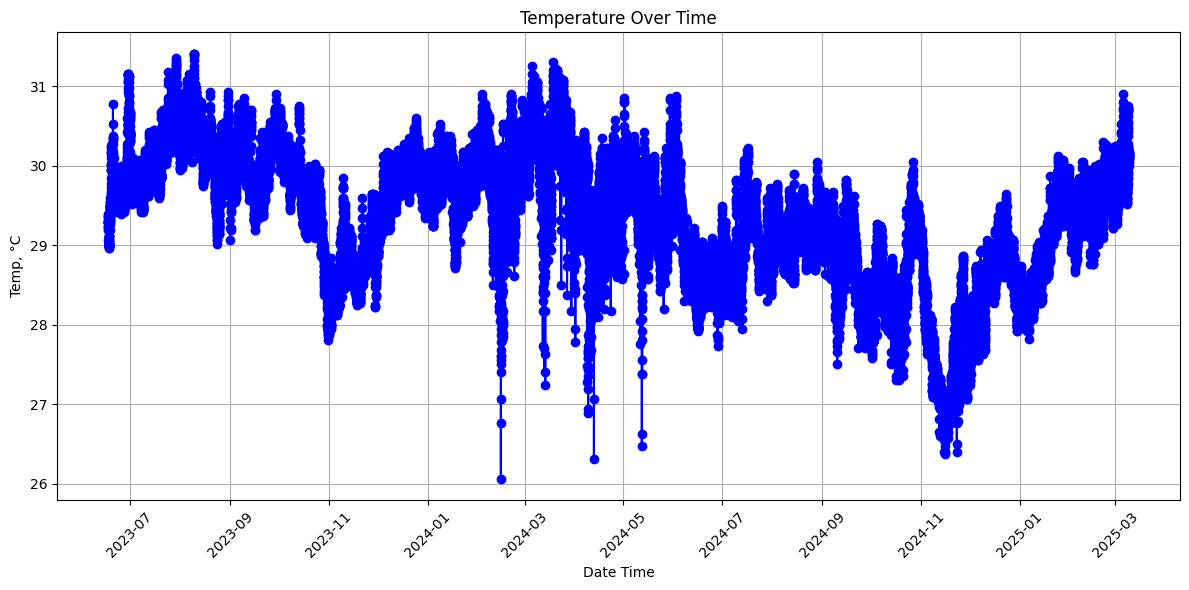

In [40]:
#%% Individual plots

# # Get the DataFrame
df = df_files['PAUVGC']['2306']['a']['DataFrame']

# Determine the correct date column based on whether the site is in Panama codes
if site_code in panama_codes:
        date_col = 'Date Time, GMT-05:00'
else:
        date_col = 'Date Time, GMT-04:00'

# # Convert the 'Date Time, GMT-04:00' column to datetime format or GMT 5 if Panama
df[date_column] = pd.to_datetime(df[date_column])


# # Plot the temperature over time
plt.figure(figsize=(12, 6))
plt.plot(df[date_column], df['Temp, °C'], color='blue', marker='o', linestyle='-')
plt.title('Temperature Over Time')
plt.xlabel('Date Time')
plt.ylabel('Temp, °C')  # Modified label
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Plotting Loop without displaying months:
If faster graph generation is desired, uncomment the cell below to generate the graphs for each site without displaying the months. This code is good for getting an idea of the shape for each file.

In [ ]:
#%% Loop all plots without altering time to display as months -- Runs Faster

# # Loop through df_files and plot graphs for each DataFrame
# for site_code, site_data in df_files.items():
#     for file_number, file_data in site_data.items():
#         for file_identifier, file_info in file_data.items():
#             # Get the DataFrame
#             df = file_info['DataFrame']

#            # Determine the correct date column based on whether the site is in Panama codes
#            if site_code in panama_codes:
#                    date_col = 'Date Time, GMT-05:00'
#            else:
#                    date_col = 'Date Time, GMT-04:00'

            # Convert the 'Date Time, GMT-04:00' column to datetime format or GMT 5 if Panama
#            df[date_column] = pd.to_datetime(df[date_column])

#             # Plot the temperature over time
#             plt.figure(figsize=(12, 6))
#             plt.plot(df.index, df['Temp, °C'], color='blue', marker='o', linestyle='-')
#             plt.title(f'Temperature Over Time - Site: {site_code}, File Number: {file_number}, Identifier: {file_identifier}')
#             plt.xlabel('Date Time')
#             plt.ylabel('Temp, °C')
#             plt.grid(True)
#             plt.xticks(rotation=45)
#             plt.tight_layout()
#             plt.show()

### Loop for plotting the sites:
This cell will generate graphs for the temperature change over the deployments for every site including months along the x axis.

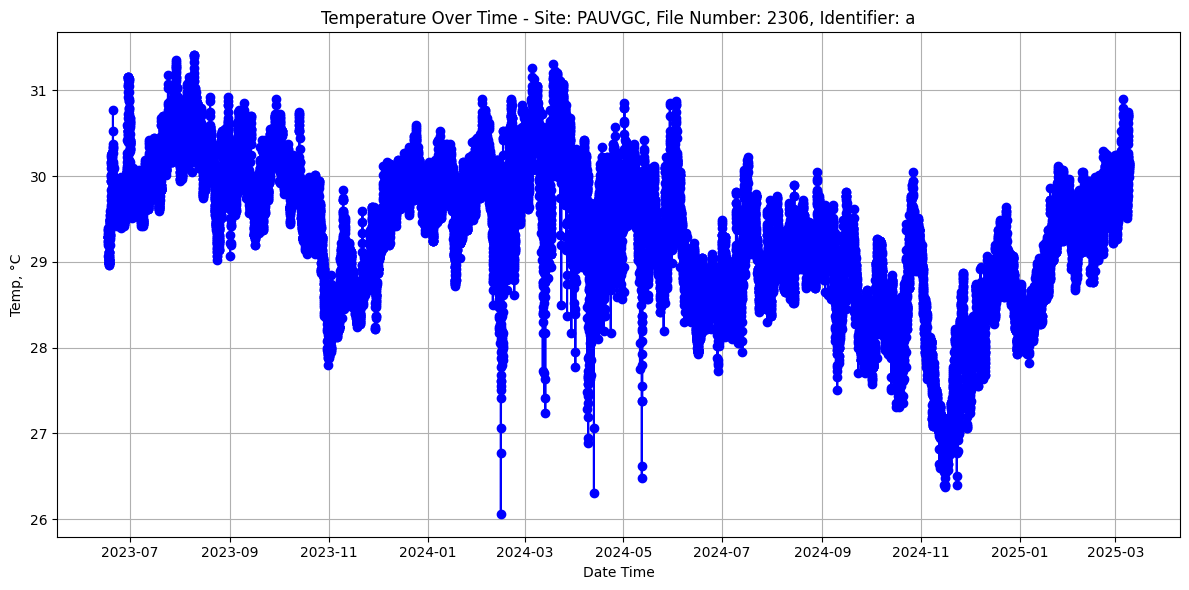

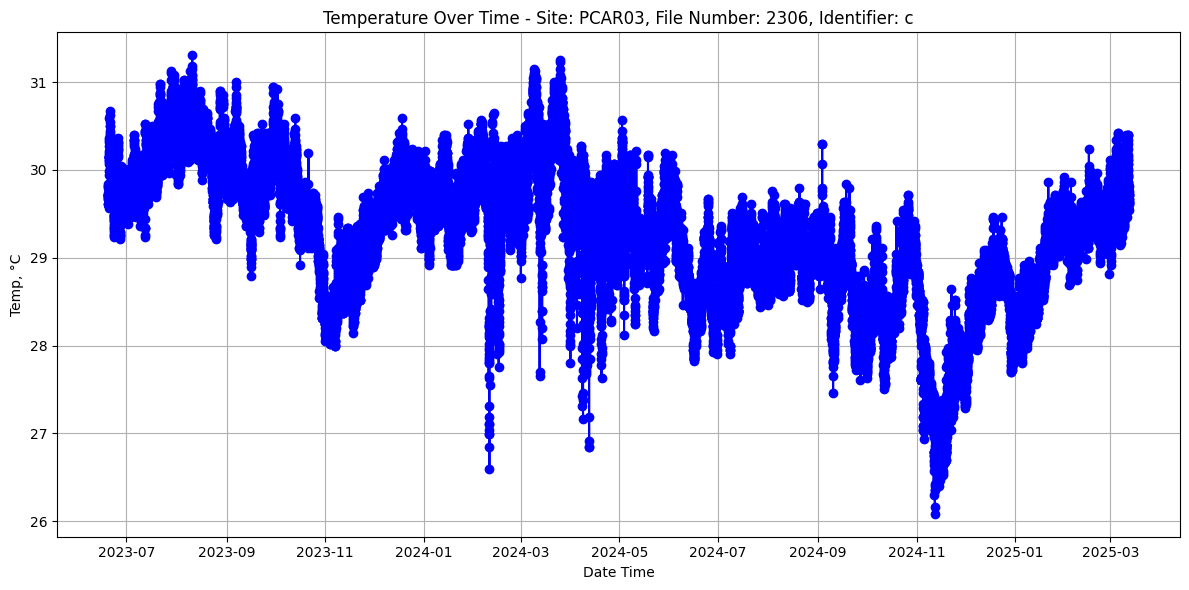

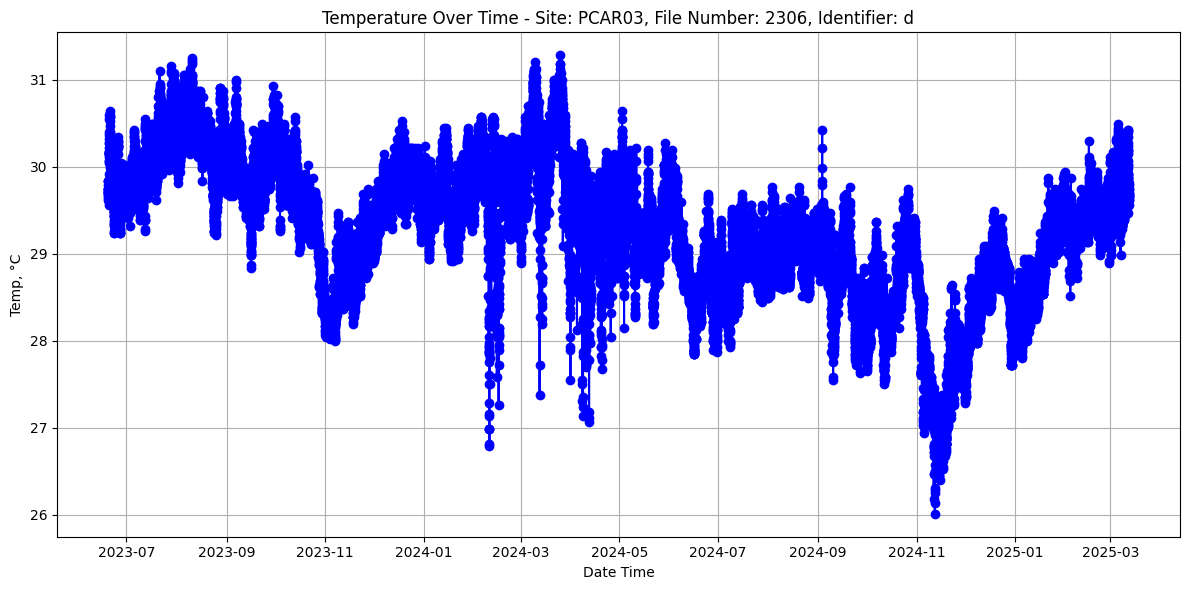

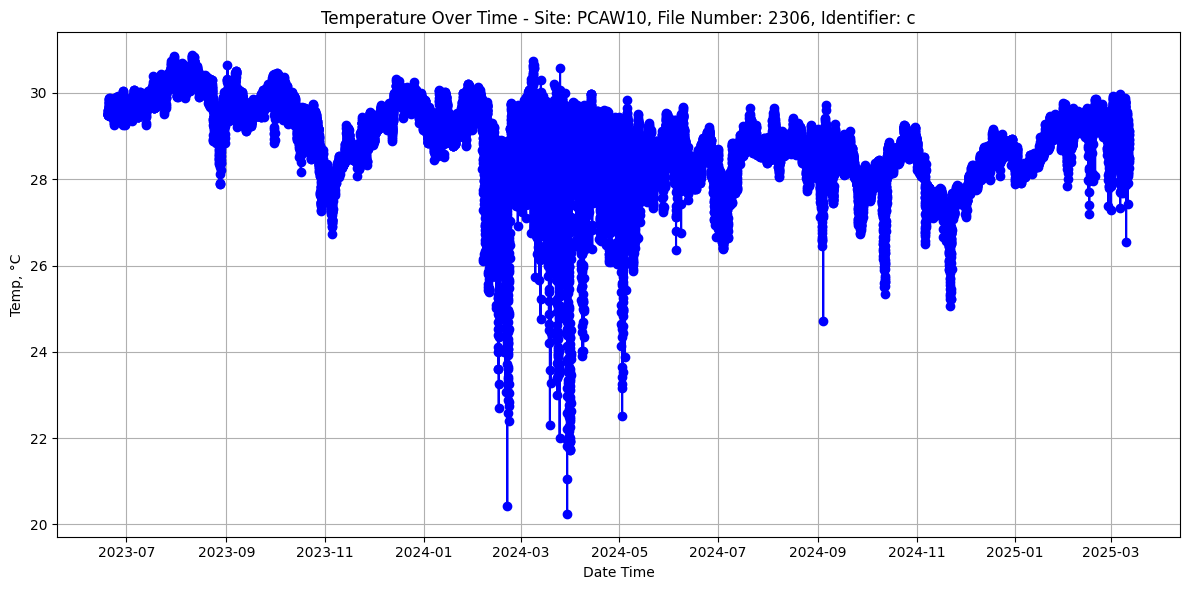

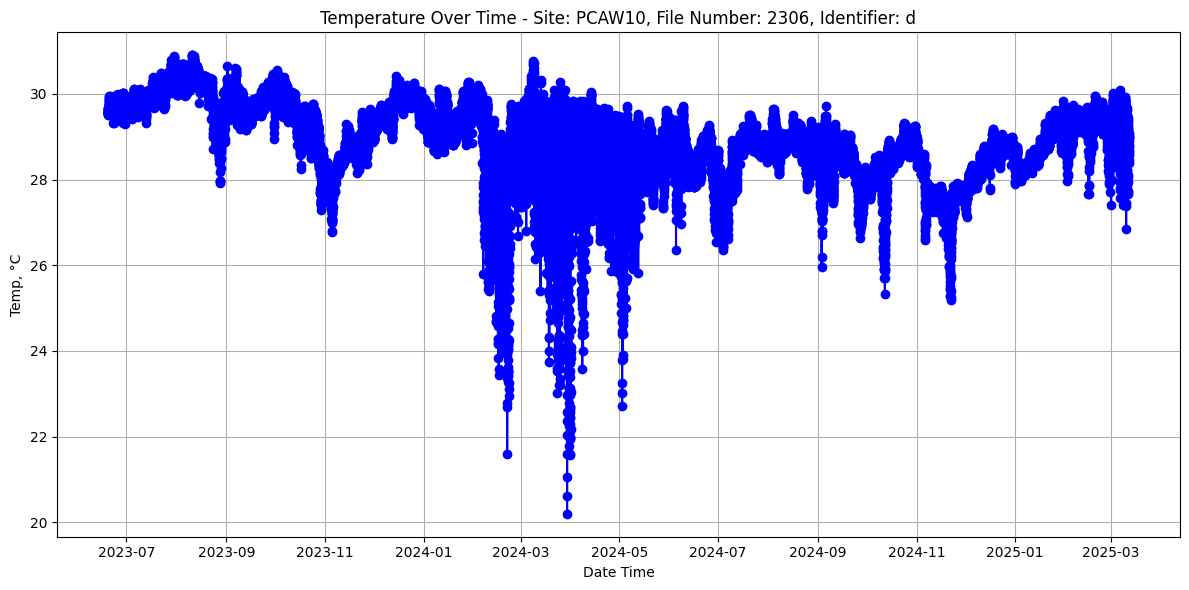

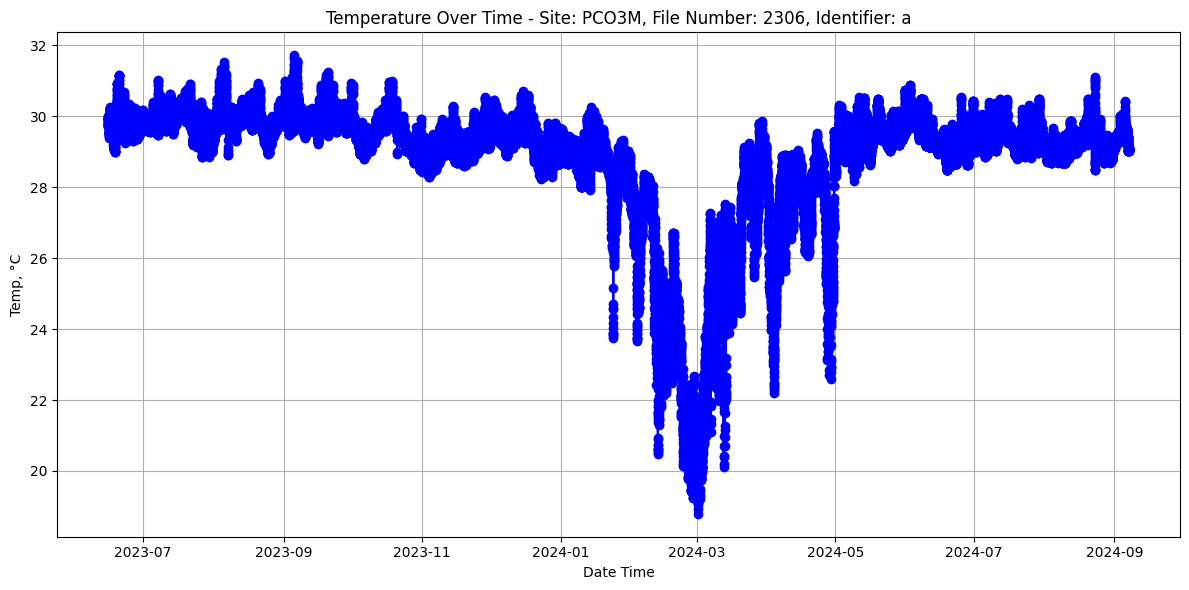

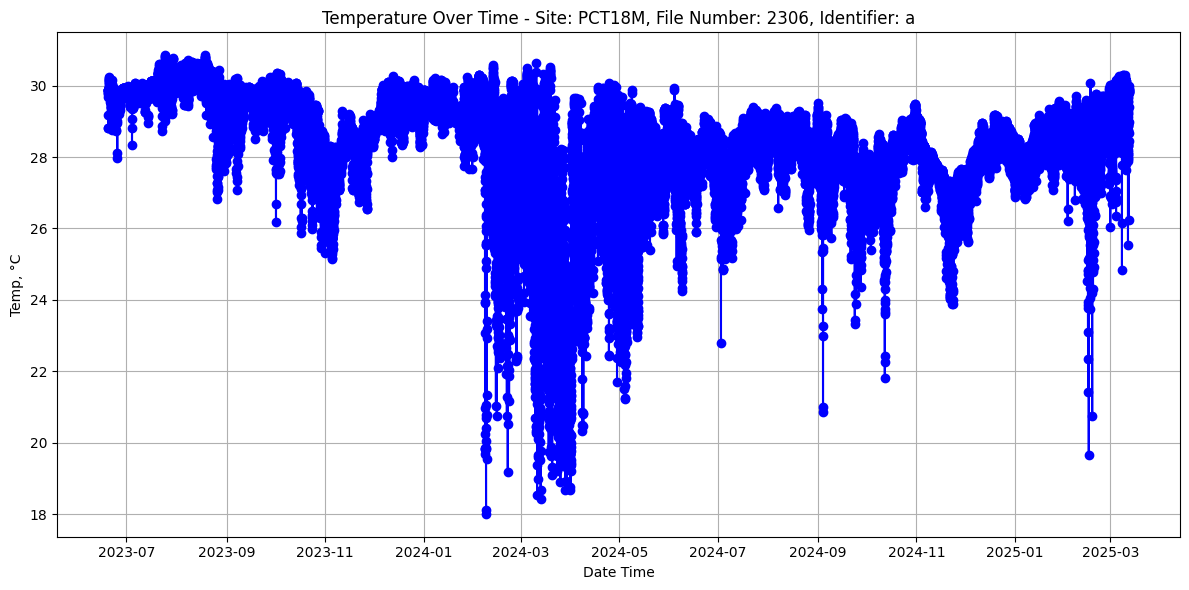

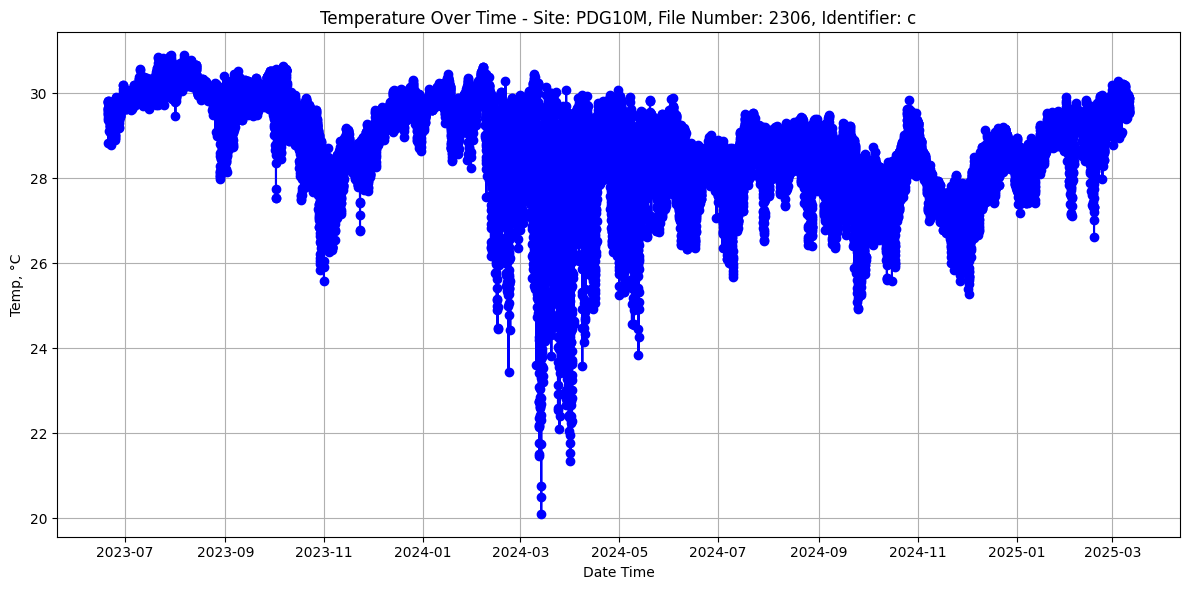

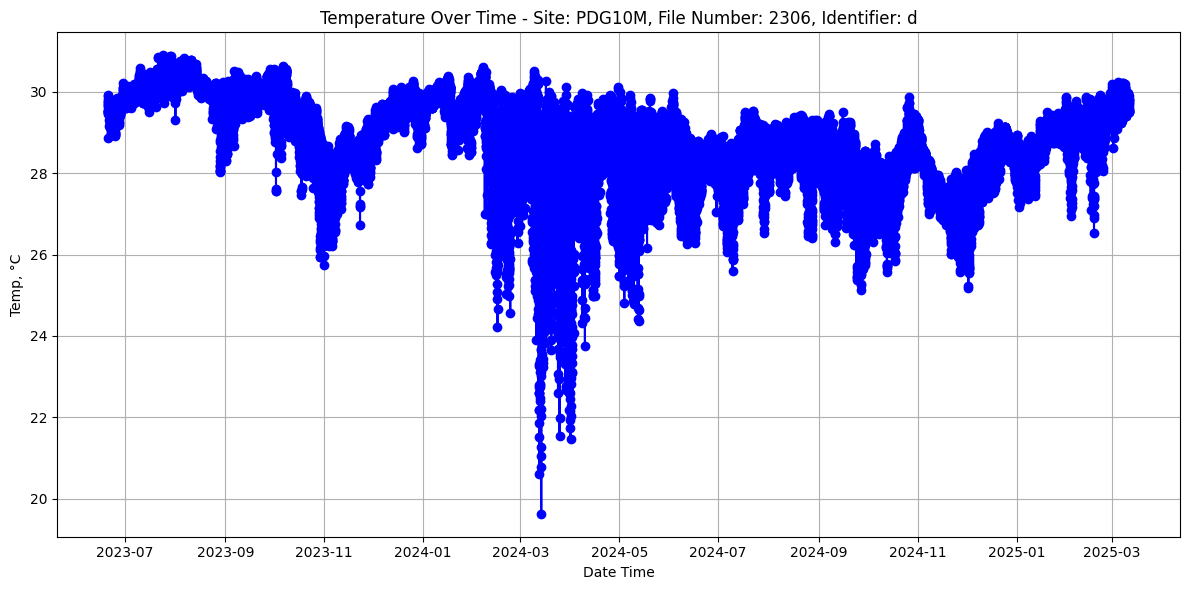

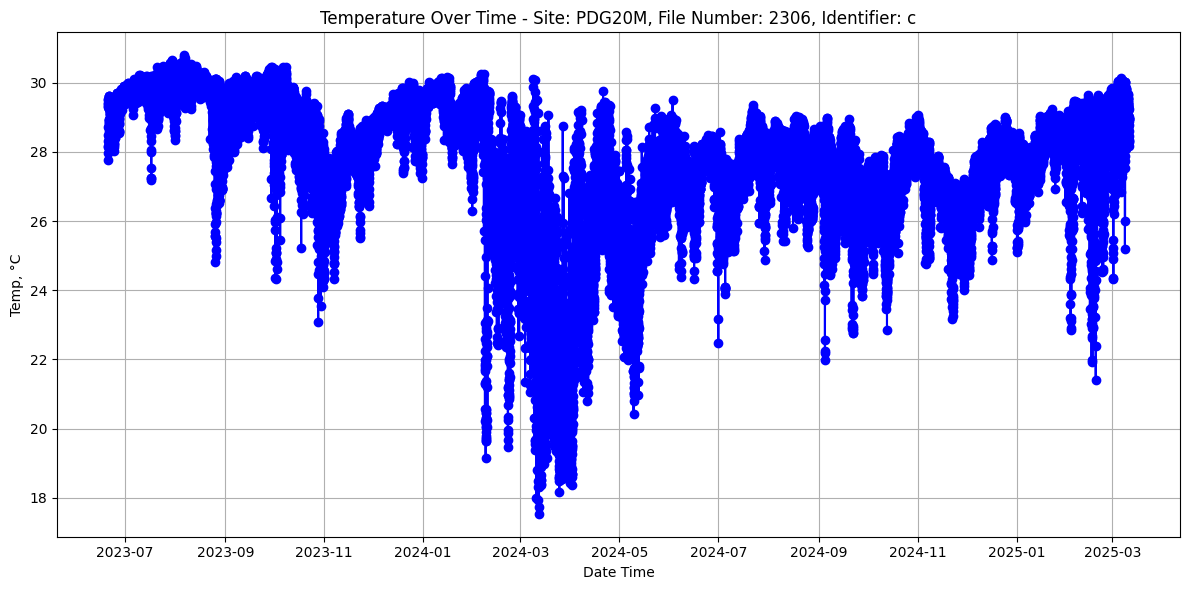

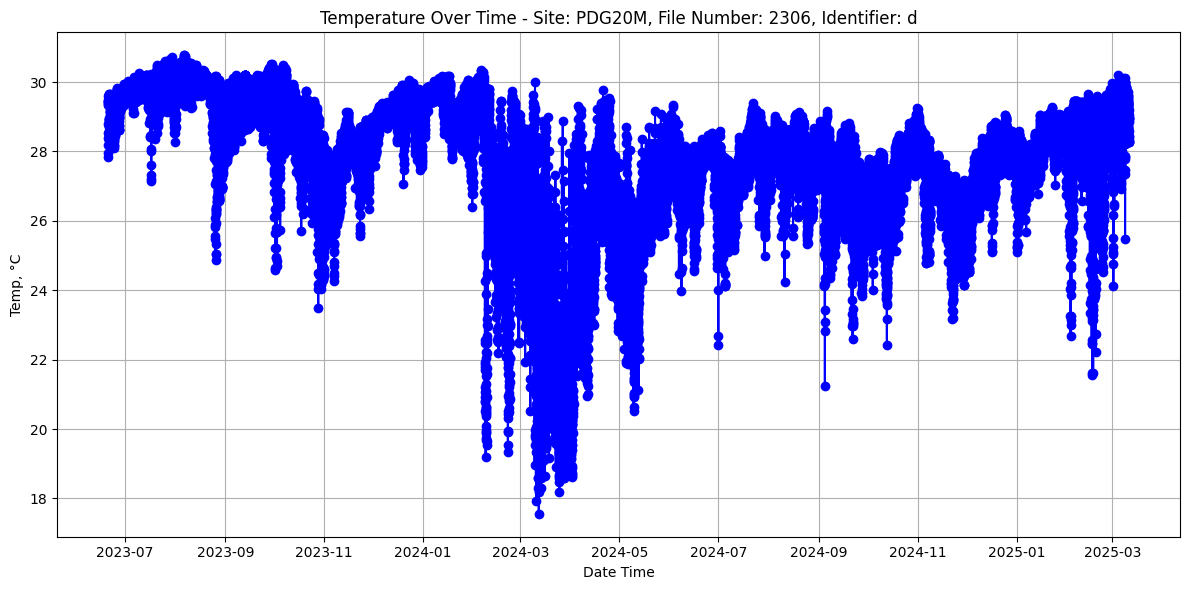

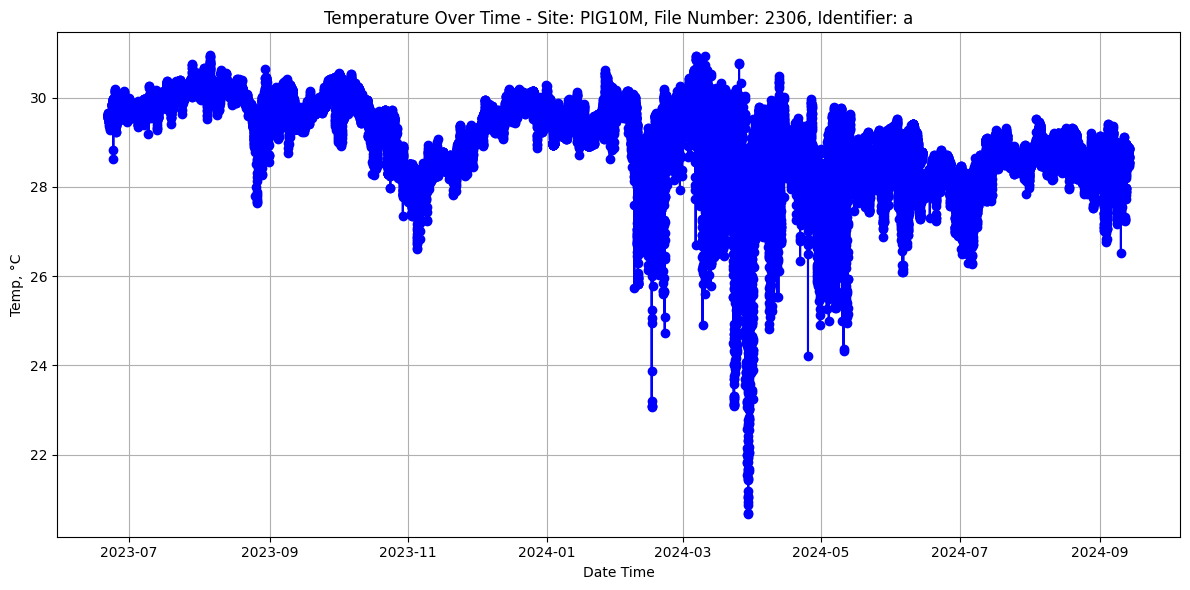

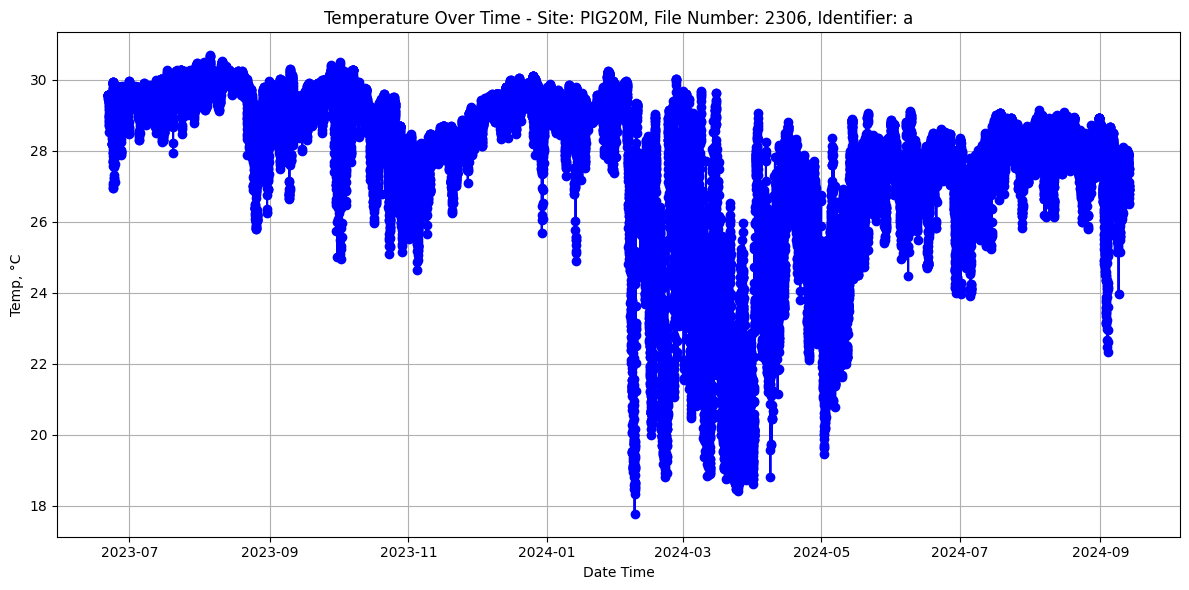

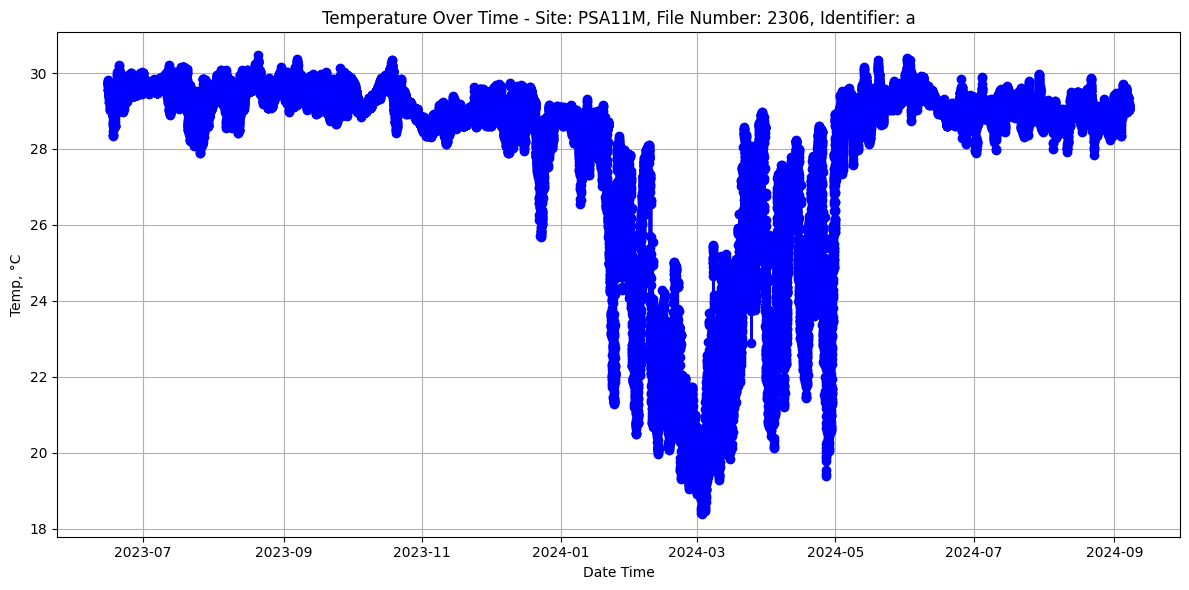

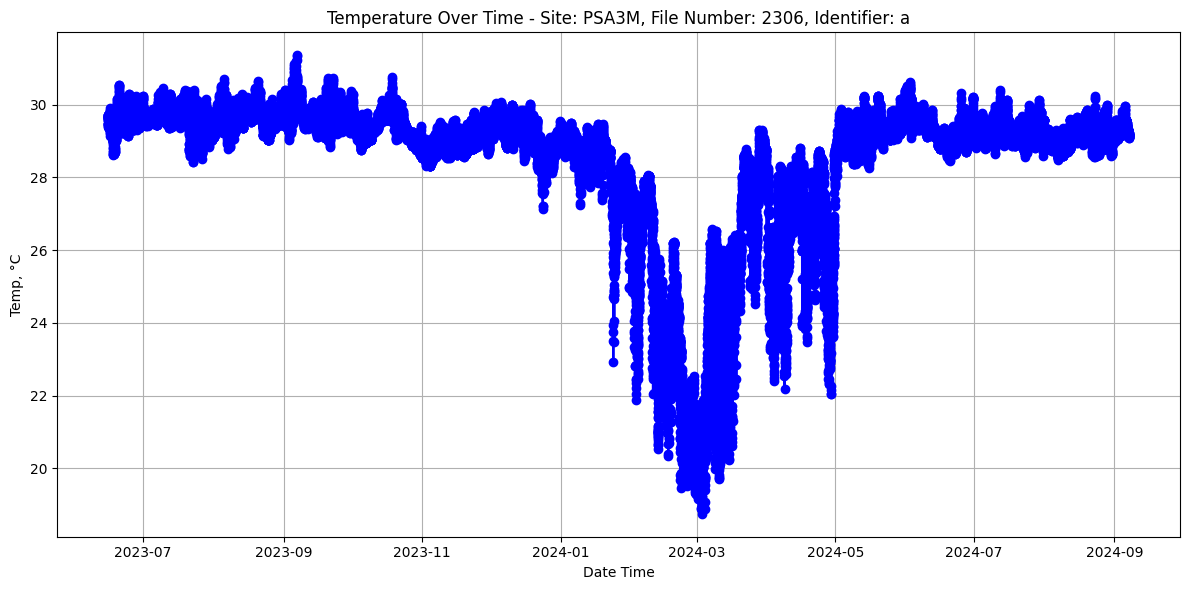

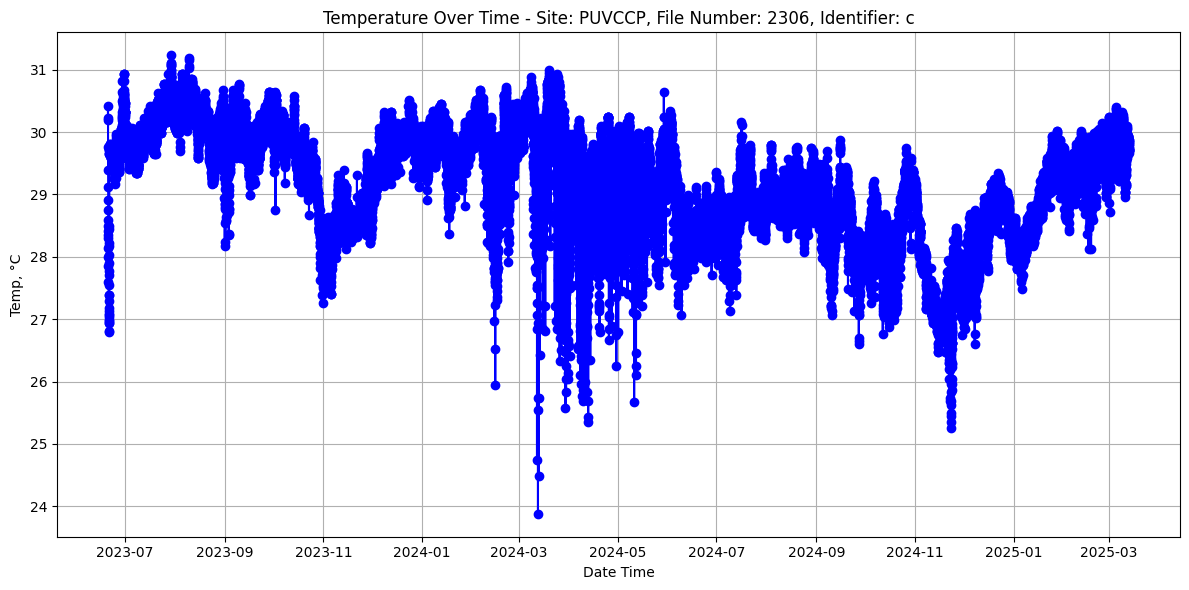

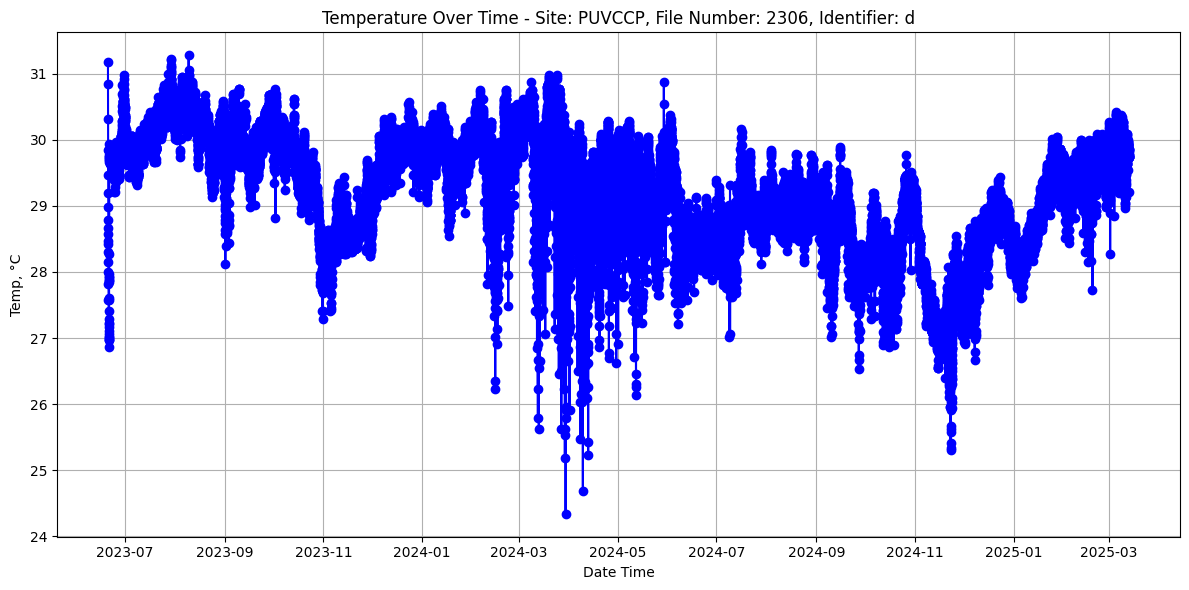

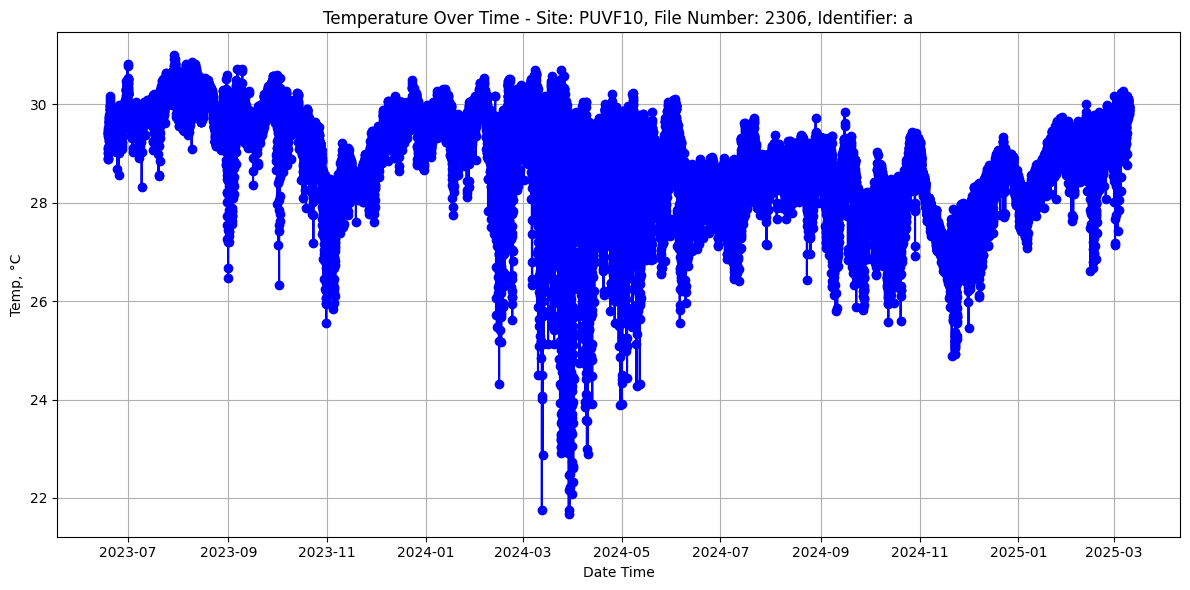

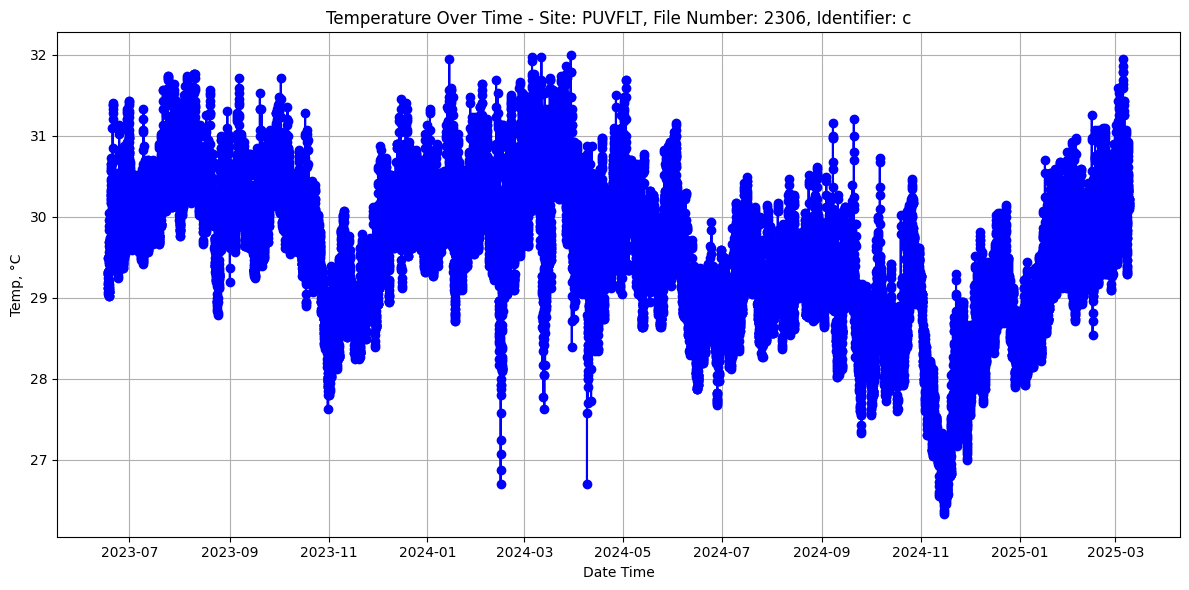

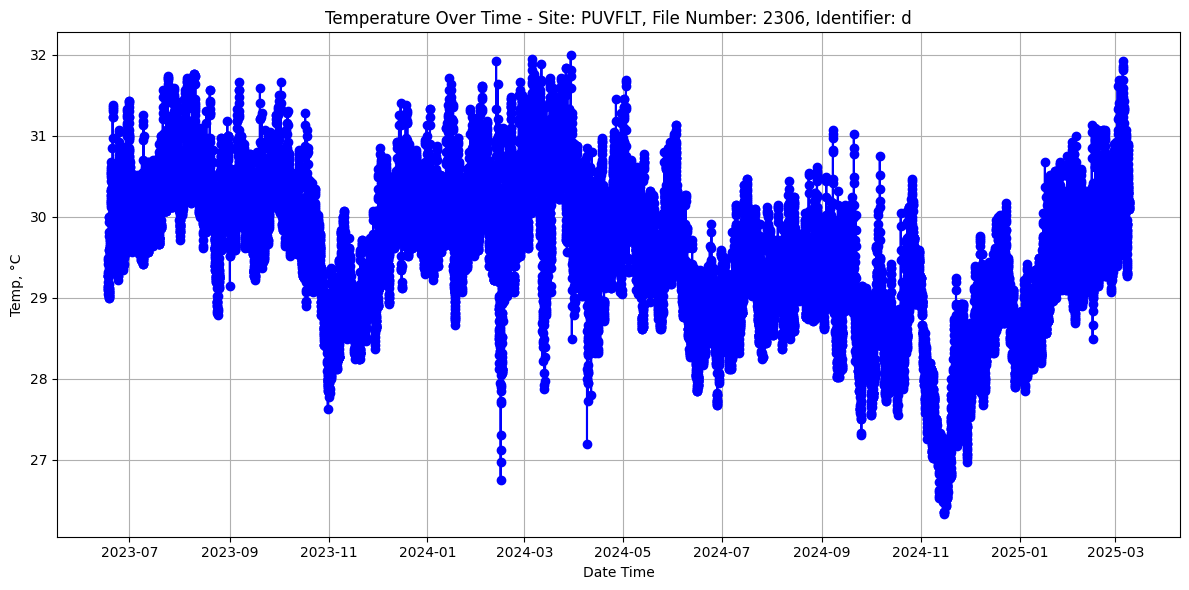

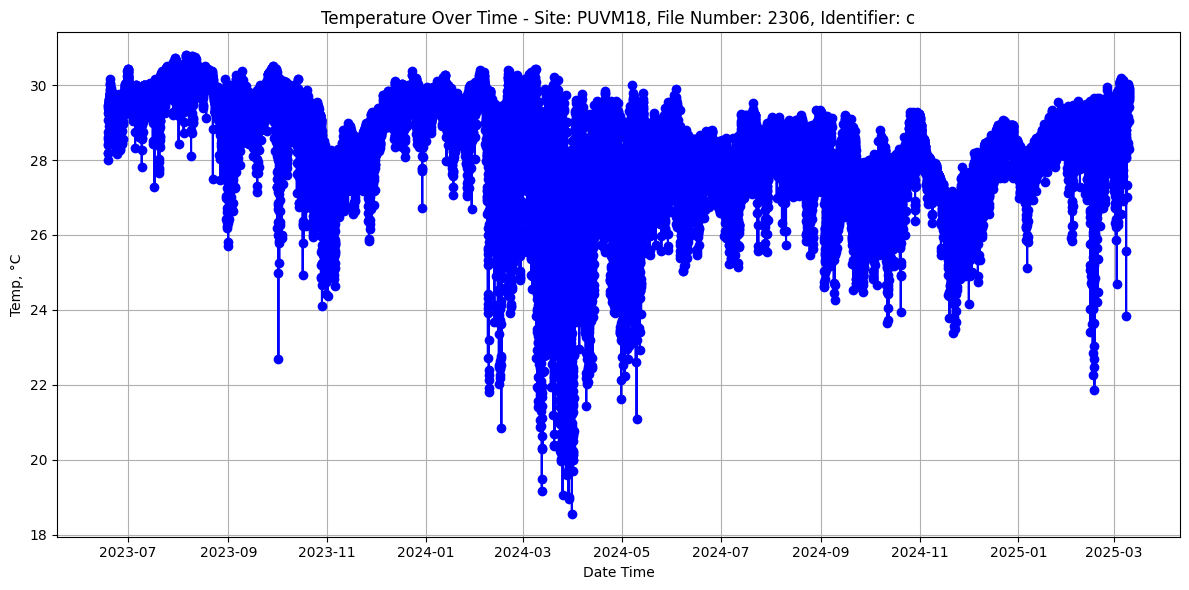

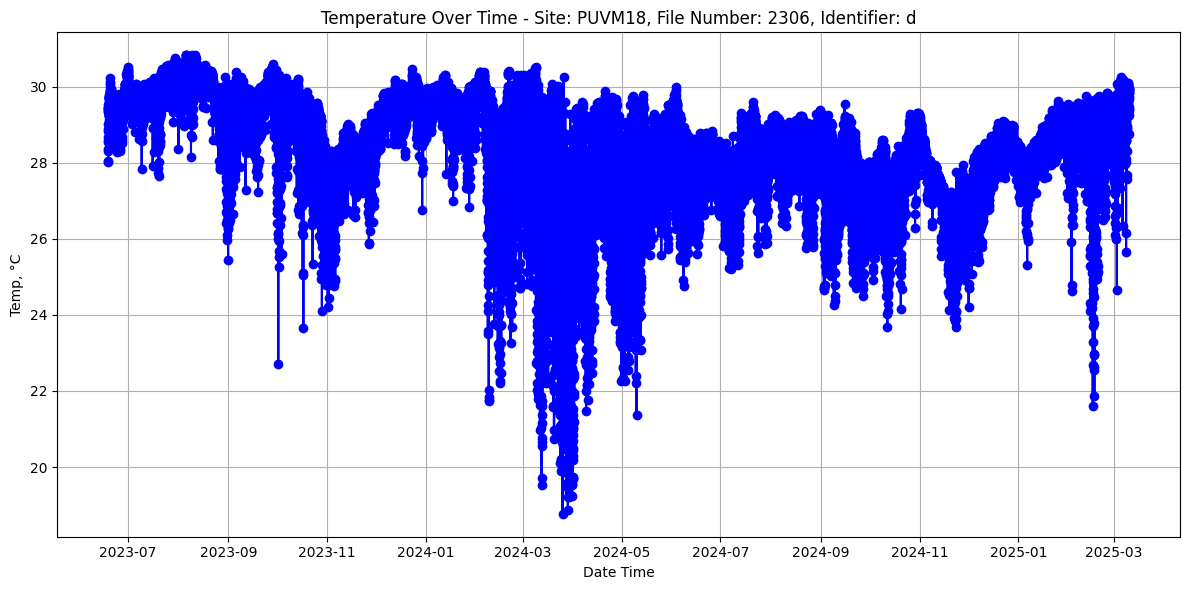

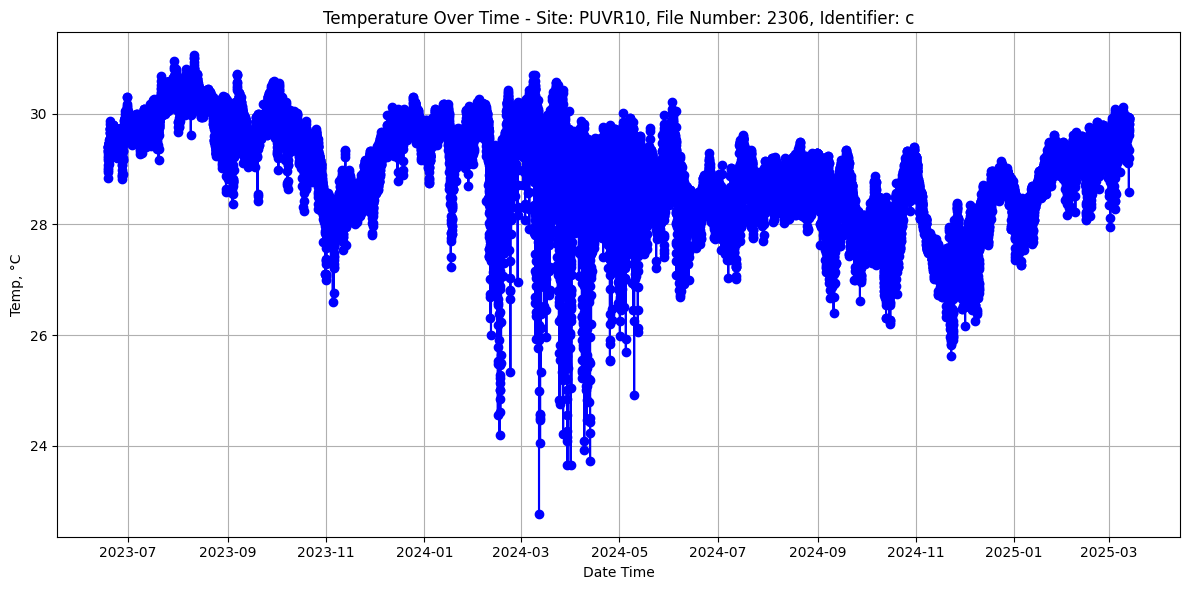

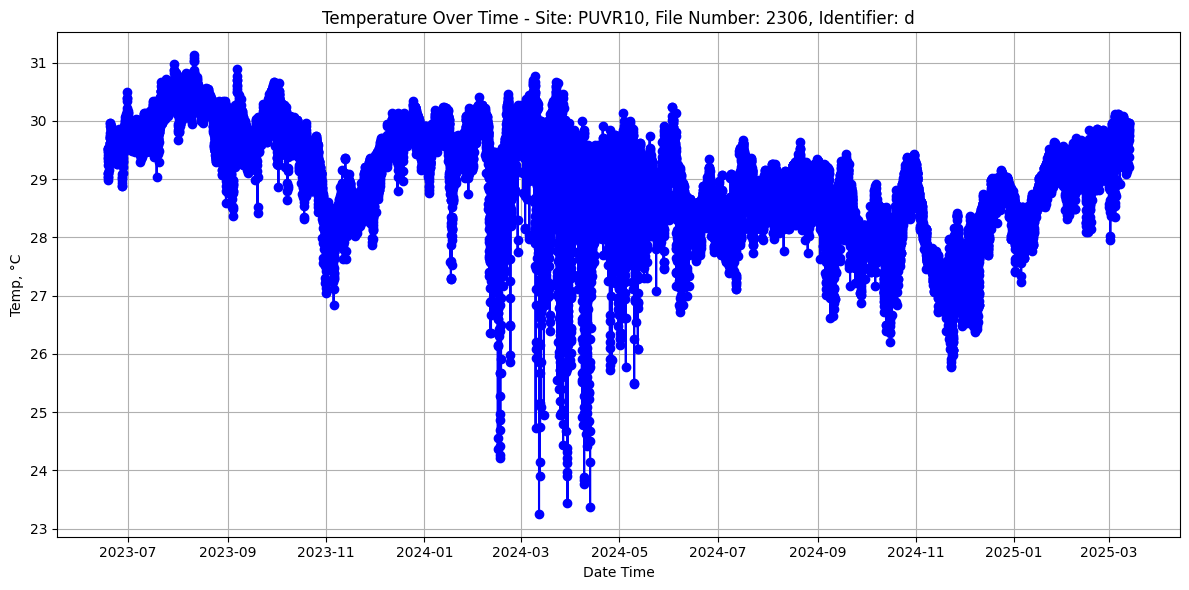

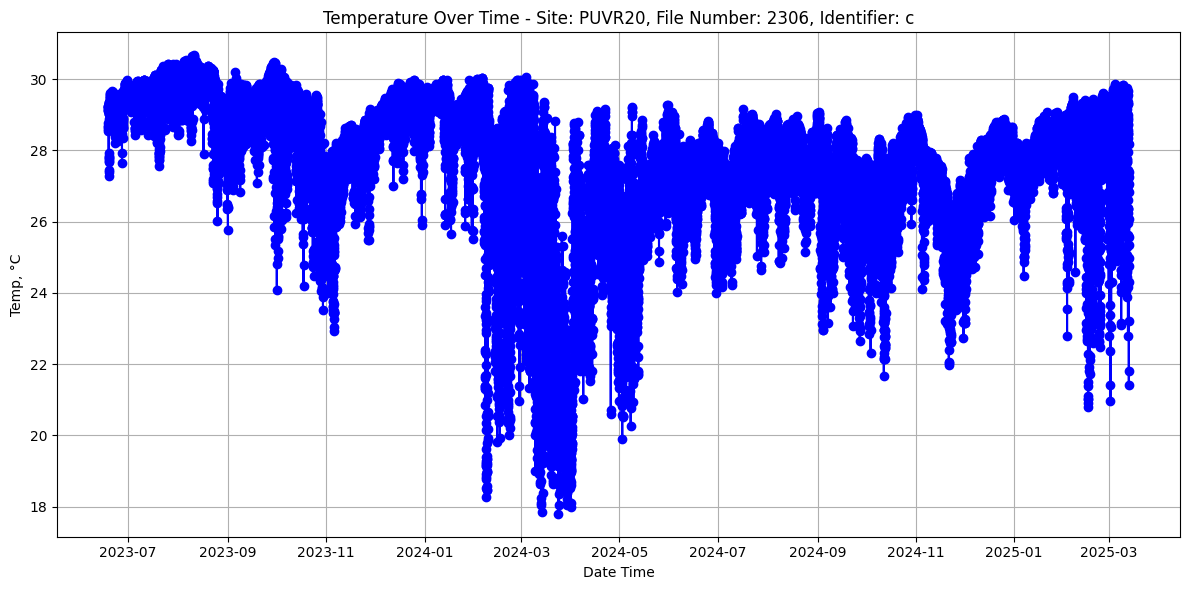

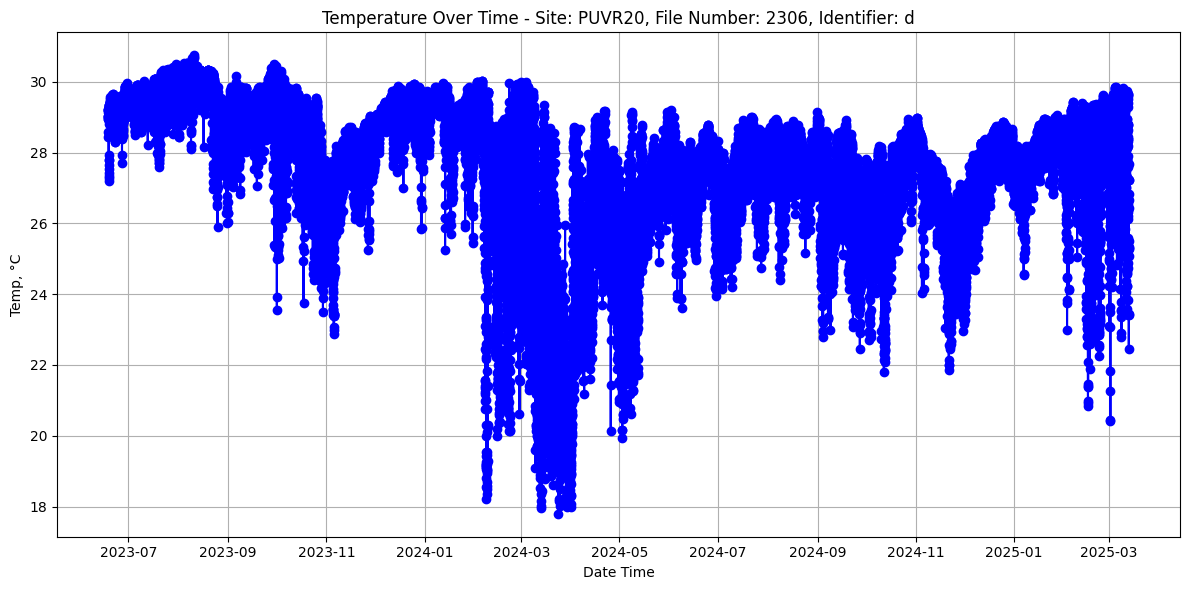

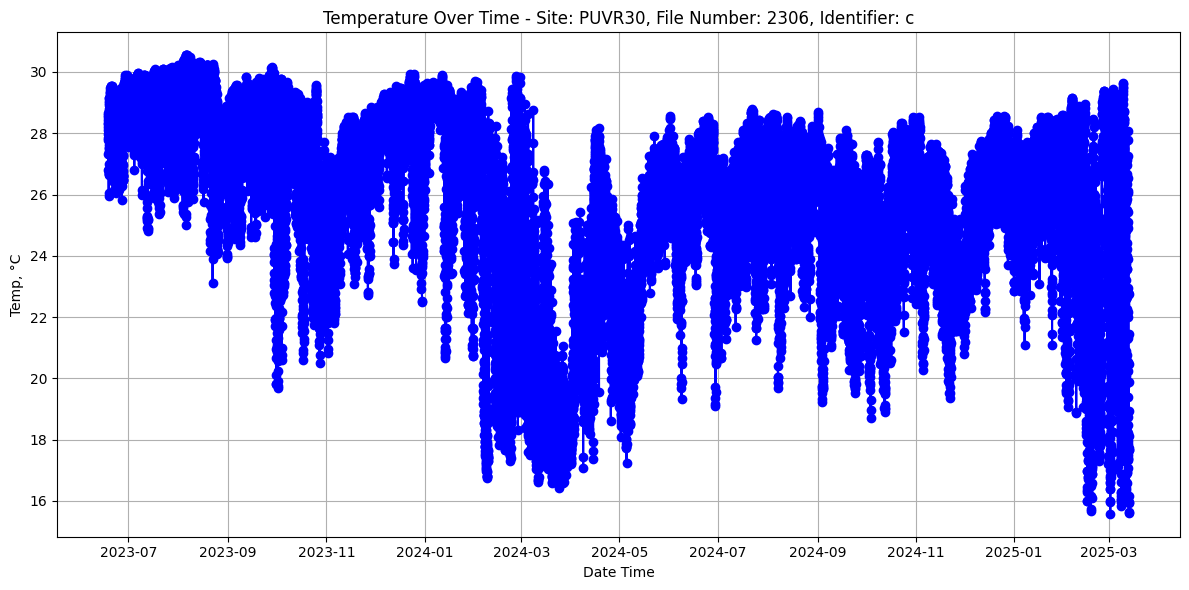

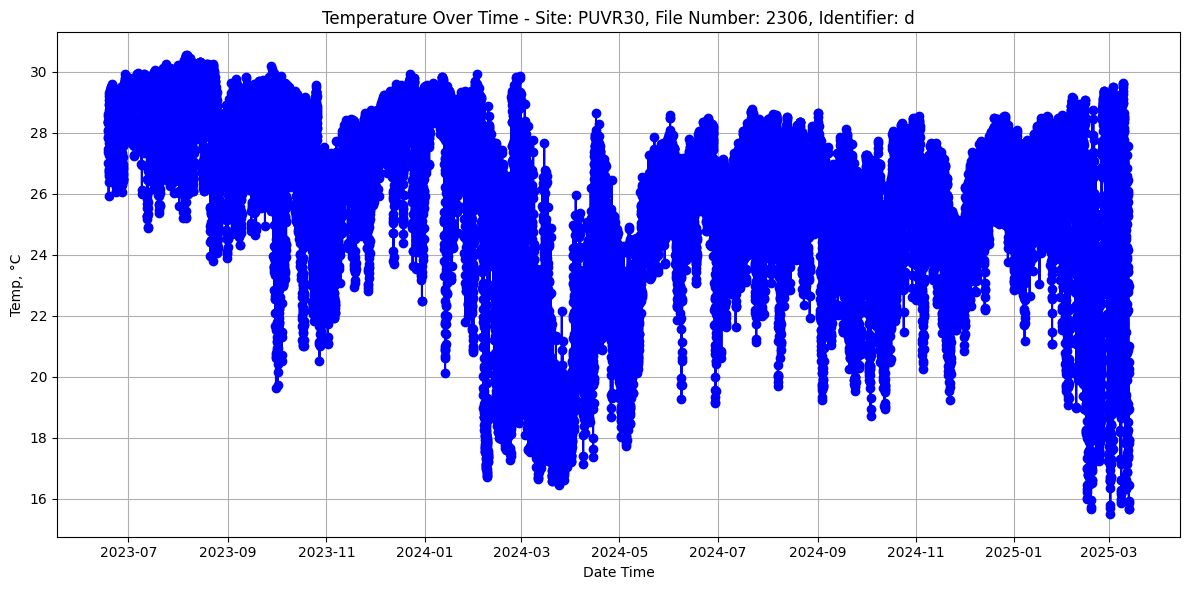

In [77]:
#%% Loop through df_files and plot graphs for each DataFrame where time is displayed as months

# Loop through df_files and plot graphs for each DataFrame
for site_code, site_data in df_files.items():
    # Determine the correct date column based on whether the site is in Panama codes
    if site_code in panama_codes:
        date_col = 'Date Time, GMT-05:00'
    else:
        date_col = 'Date Time, GMT-04:00'

    for file_number, file_data in site_data.items():
        for file_identifier, file_info in file_data.items():
            # Get the DataFrame
            df = file_info['DataFrame']

            # Convert the date column to datetime format
            df.loc[:, date_col] = pd.to_datetime(df[date_col])

            # Plot the temperature over time
            plt.figure(figsize=(12, 6))
            plt.plot(df[date_col], df['Temp, °C'], color='blue', marker='o', linestyle='-')
            plt.title(f'Temperature Over Time - Site: {site_code}, File Number: {file_number}, Identifier: {file_identifier}')
            plt.xlabel('Date Time')
            plt.ylabel('Temp, °C')
            plt.grid(True)
            
            # Set x-axis ticks to display month names at regular intervals
            # first_day_of_month_indices = df.index[df[date_col].dt.day == 1]
            # plt.xticks(first_day_of_month_indices, [dt.strftime('%b') for dt in df.loc[first_day_of_month_indices, date_col]], rotation=45, fontdict={'family': 'sans-serif', 'size': 25, 'style': 'normal'})

            plt.tight_layout()
            plt.show()

## Additional Trimming:
After looking through the trimmed plots, make sure that there doesn't need to be any additional trimming. Then re-run the plotting code to confirm! <b>Just make sure to changeout the variables to fit your data!
<u> You can skip this cell if its not needed!

In [76]:
#%%
def trim_dataframe(df_files, site_code, file_number, file_identifier, panama_codes, cutoff_datetime):
    # Check if the file identifier exists for the specified site code and file number
    if file_identifier not in df_files[site_code][file_number]:
        raise KeyError(f"'{file_identifier}' not found for site code '{site_code}' and file number '{file_number}'")
    
    # Access the DataFrame using the site_code, file_number, and file_identifier
    df = df_files[site_code][file_number][file_identifier]['DataFrame']
    
    # Determine the correct date column based on the site code
    date_col = 'Date Time, GMT-05:00' if site_code in panama_codes else 'Date Time, GMT-04:00'
    
    # Trim the DataFrame based on the cutoff datetime
    trimmed_df = df[df[date_col] >= cutoff_datetime]
    
    # Assign the trimmed DataFrame back to the dictionary
    df_files[site_code][file_number][file_identifier]['DataFrame'] = trimmed_df

cutoff_datetime = pd.Timestamp('2023-06-20 16:30:00')

# Pass the file number (e.g., '001') and file identifier (e.g., 'c') to access the DataFrame
trim_dataframe(df_files, 'PUVCCP', '2306', 'c', panama_codes, cutoff_datetime)

### Merge the offset files:
This loop checks if the c and d identifiers exist within the files. If they exist, then the code gets the data frame for each and merges them based on the Date Time column. For the instances where the merge occured, a new identifier is added to the df_files dictionary called 'merged'.

In [78]:
#%%
# Initialize the dictionary for storing merged DataFrames
merged_dict = {}

# Iterate through each site code
for site_code, file_numbers in df_files.items():
    # Iterate through each file number
    for file_number, identifiers in file_numbers.items():
        # Check if 'c' and 'd' identifiers exist
        if 'c' in identifiers and 'd' in identifiers:
            df_c = identifiers['c']['DataFrame']
            df_d = identifiers['d']['DataFrame']

            # Determine correct datetime column
            if site_code in panama_codes:
                date_col = "Date Time, GMT-05:00"
            else:
                date_col = "Date Time, GMT-04:00"

            # Skip if expected datetime column is missing
            if date_col not in df_c.columns or date_col not in df_d.columns:
                print(f"Skipping merge for {site_code}, file {file_number}: Missing expected datetime column.")
                continue

            # Convert datetime columns to datetime type
            df_c[date_col] = pd.to_datetime(df_c[date_col], errors='coerce')
            df_d[date_col] = pd.to_datetime(df_d[date_col], errors='coerce')

            # Rename Temp columns
            df_c = df_c[['#', date_col, 'Temp, °C']].rename(columns={'Temp, °C': 'Temp_c'})
            df_d = df_d[['#', date_col, 'Temp, °C']].rename(columns={'Temp, °C': 'Temp_d'})

            # Merge on datetime column
            merged_df = pd.merge(df_c, df_d, on=date_col, how='outer', suffixes=('_c', '_d'))

            # Combine temp columns
            merged_df['Temp, °C'] = merged_df['Temp_c'].combine_first(merged_df['Temp_d'])

            # Merge hash column variations
            if '#_c' in merged_df.columns and '#_d' in merged_df.columns:
                merged_df['#'] = merged_df['#_c'].combine_first(merged_df['#_d'])
                merged_df = merged_df.drop(columns=['#_c', '#_d'])
            elif '#_c' in merged_df.columns:
                merged_df['#'] = merged_df['#_c']
                merged_df = merged_df.drop(columns=['#_c'])
            elif '#_d' in merged_df.columns:
                merged_df['#'] = merged_df['#_d']
                merged_df = merged_df.drop(columns=['#_d'])
            elif '#_x' in merged_df.columns and '#_y' in merged_df.columns:
                merged_df['#'] = merged_df['#_x'].combine_first(merged_df['#_y'])
                merged_df = merged_df.drop(columns=['#_x', '#_y'])
            elif '#_x' in merged_df.columns:
                merged_df['#'] = merged_df['#_x']
                merged_df = merged_df.drop(columns=['#_x'])
            elif '#_y' in merged_df.columns:
                merged_df['#'] = merged_df['#_y']
                merged_df = merged_df.drop(columns=['#_y'])

            # Final cleanup
            merged_df = merged_df[['#', date_col, 'Temp, °C']]

            # Store the result
            merged_dict[site_code] = merged_df
            print(f"Merged Data for Site: {site_code}, File Number: {file_number}")
            
# Loop through the merged_dict and reassign the '#' column to be sequential
for site_code, merged_df in merged_dict.items():
    # Convert to numeric in case of any string values or NaNs
    merged_df['#'] = pd.to_numeric(merged_df['#'], errors='coerce')

    # Drop any NaN values that might have been introduced
    merged_df = merged_df.dropna(subset=['#']).reset_index(drop=True)

    # Ensure we start numbering from the first valid value
    start_value = int(merged_df['#'].iloc[0]) if not merged_df.empty else 1
    
    # Assign sequential numbering starting from start_value
    merged_df['#'] = range(start_value, start_value + len(merged_df))
    
    # Update the dictionary
    merged_dict[site_code] = merged_df

    print(f"Updated '#' column for Site: {site_code}")

Merged Data for Site: PCAR03, File Number: 2306
Merged Data for Site: PCAW10, File Number: 2306
Merged Data for Site: PDG10M, File Number: 2306
Merged Data for Site: PDG20M, File Number: 2306
Merged Data for Site: PUVCCP, File Number: 2306
Merged Data for Site: PUVFLT, File Number: 2306
Merged Data for Site: PUVM18, File Number: 2306
Merged Data for Site: PUVR10, File Number: 2306
Merged Data for Site: PUVR20, File Number: 2306
Merged Data for Site: PUVR30, File Number: 2306
Updated '#' column for Site: PCAR03
Updated '#' column for Site: PCAW10
Updated '#' column for Site: PDG10M
Updated '#' column for Site: PDG20M
Updated '#' column for Site: PUVCCP
Updated '#' column for Site: PUVFLT
Updated '#' column for Site: PUVM18
Updated '#' column for Site: PUVR10
Updated '#' column for Site: PUVR20
Updated '#' column for Site: PUVR30


## Offset Agreement Plots:
To make sure both offset loggers haven't deviated from one another this cell creates "agreement plots" showing the number of points above and below a 1:1 line where both loggers should share the same temperature. If the points above and below the line for one logger match the points below and above the line for the other logger then they don't deviate. If not that signals that the logger is drifting and needs to be taken note of for later processing.

Site: PCAR03, File Number: 2306
  Blue points above 1:1 line: 5928
  Blue points below 1:1 line: 15175
  Red points above 1:1 line: 15175
  Red points below 1:1 line: 5928


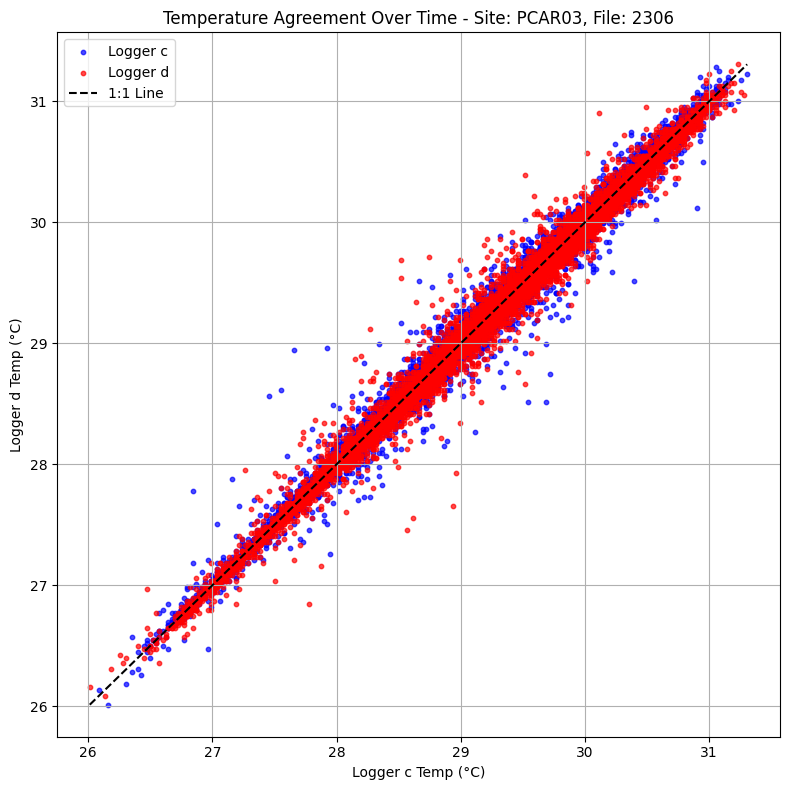

Site: PCAW10, File Number: 2306
  Blue points above 1:1 line: 4398
  Blue points below 1:1 line: 23951
  Red points above 1:1 line: 23951
  Red points below 1:1 line: 4398


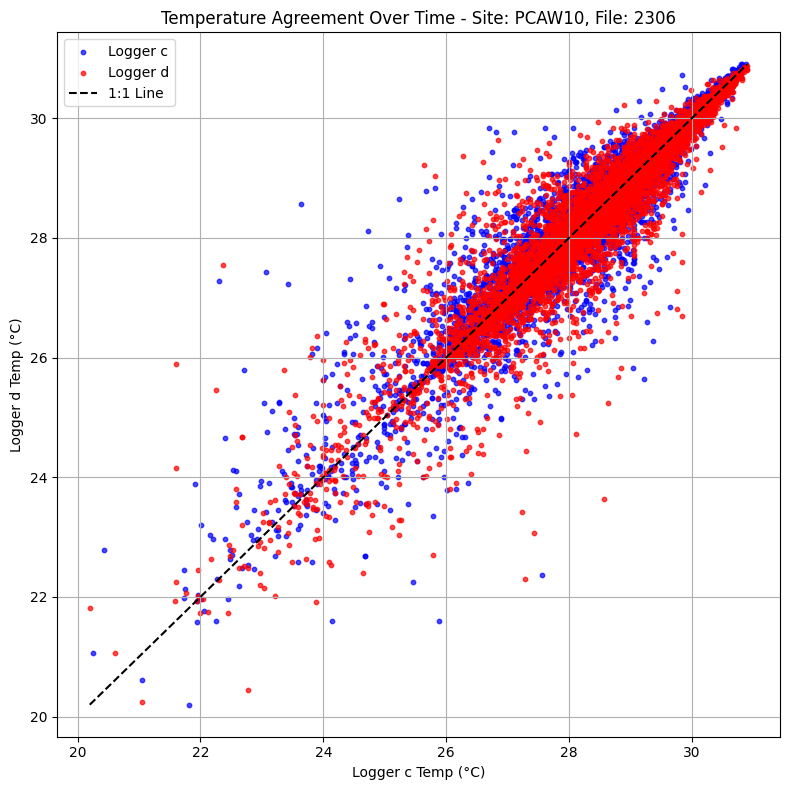

Site: PDG10M, File Number: 2306
  Blue points above 1:1 line: 14353
  Blue points below 1:1 line: 10599
  Red points above 1:1 line: 10599
  Red points below 1:1 line: 14353


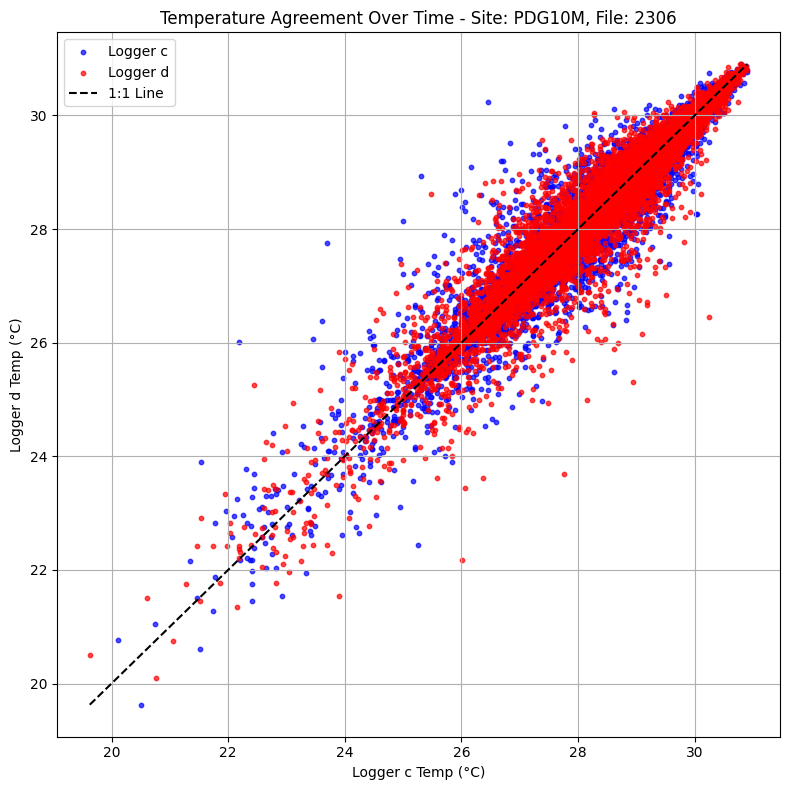

Site: PDG20M, File Number: 2306
  Blue points above 1:1 line: 10164
  Blue points below 1:1 line: 17011
  Red points above 1:1 line: 17011
  Red points below 1:1 line: 10164


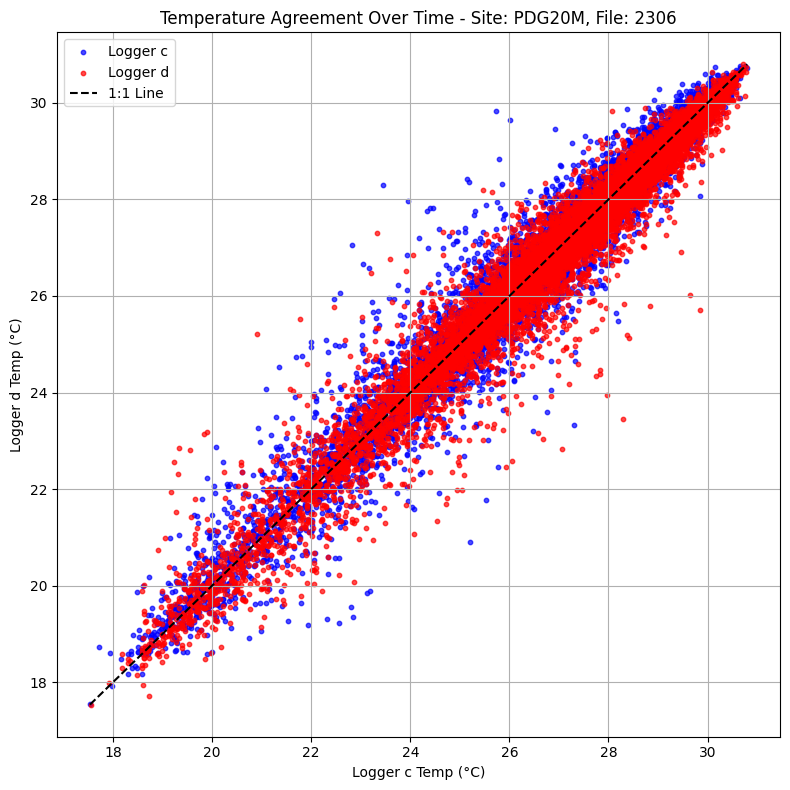

Site: PUVCCP, File Number: 2306
  Blue points above 1:1 line: 4873
  Blue points below 1:1 line: 21414
  Red points above 1:1 line: 21414
  Red points below 1:1 line: 4873


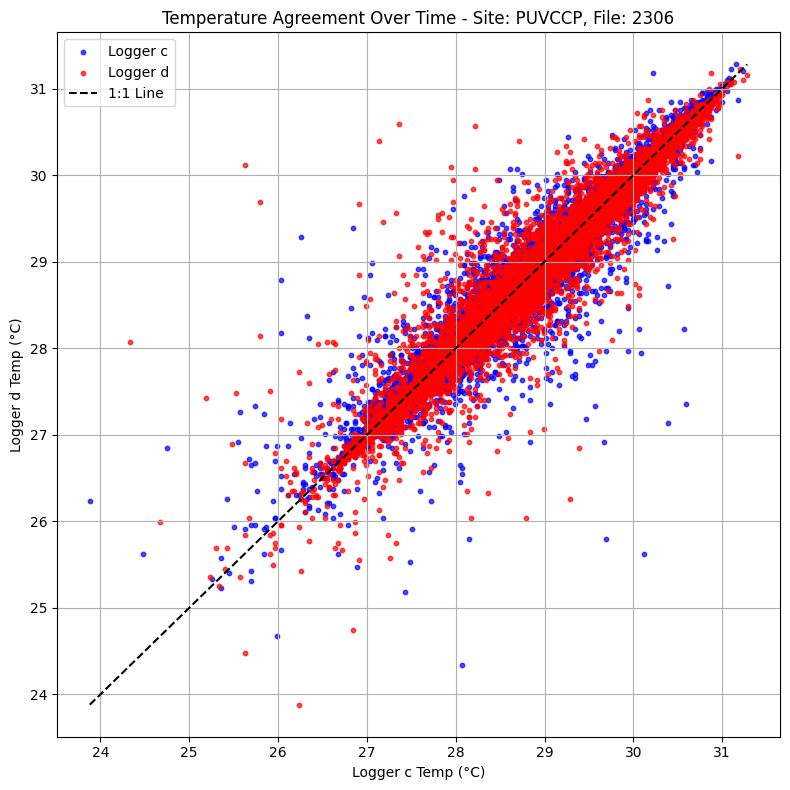

Site: PUVFLT, File Number: 2306
  Blue points above 1:1 line: 16689
  Blue points below 1:1 line: 4636
  Red points above 1:1 line: 4636
  Red points below 1:1 line: 16689


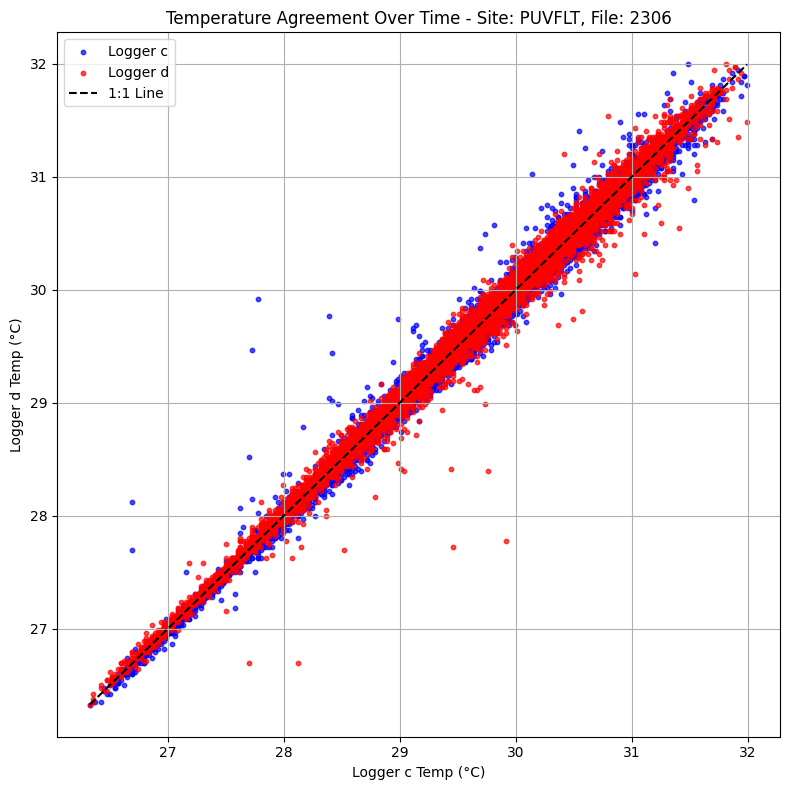

Site: PUVM18, File Number: 2306
  Blue points above 1:1 line: 11089
  Blue points below 1:1 line: 16745
  Red points above 1:1 line: 16745
  Red points below 1:1 line: 11089


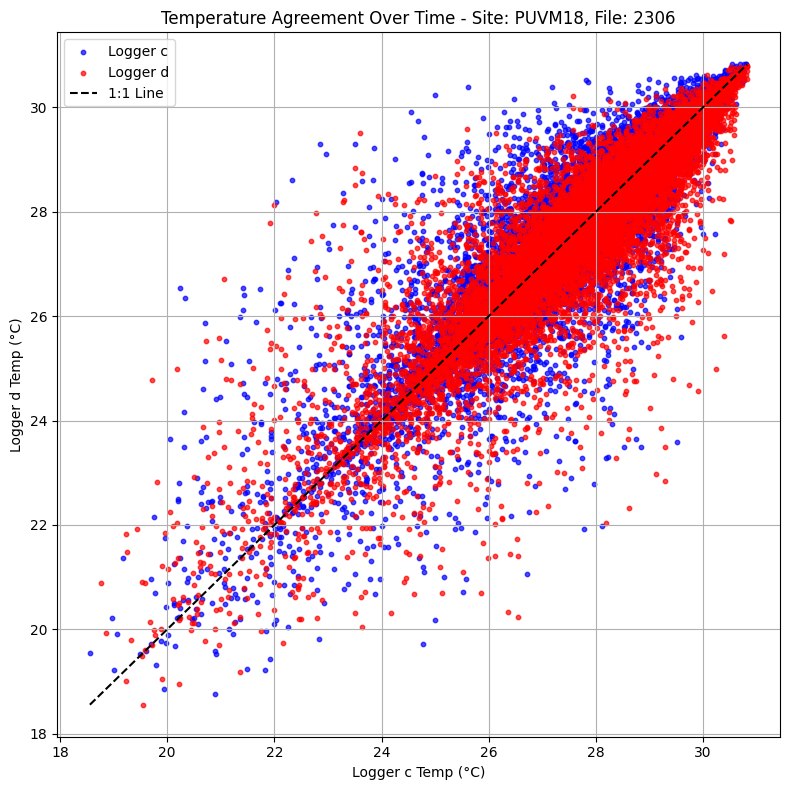

Site: PUVR10, File Number: 2306
  Blue points above 1:1 line: 5748
  Blue points below 1:1 line: 22202
  Red points above 1:1 line: 22202
  Red points below 1:1 line: 5748


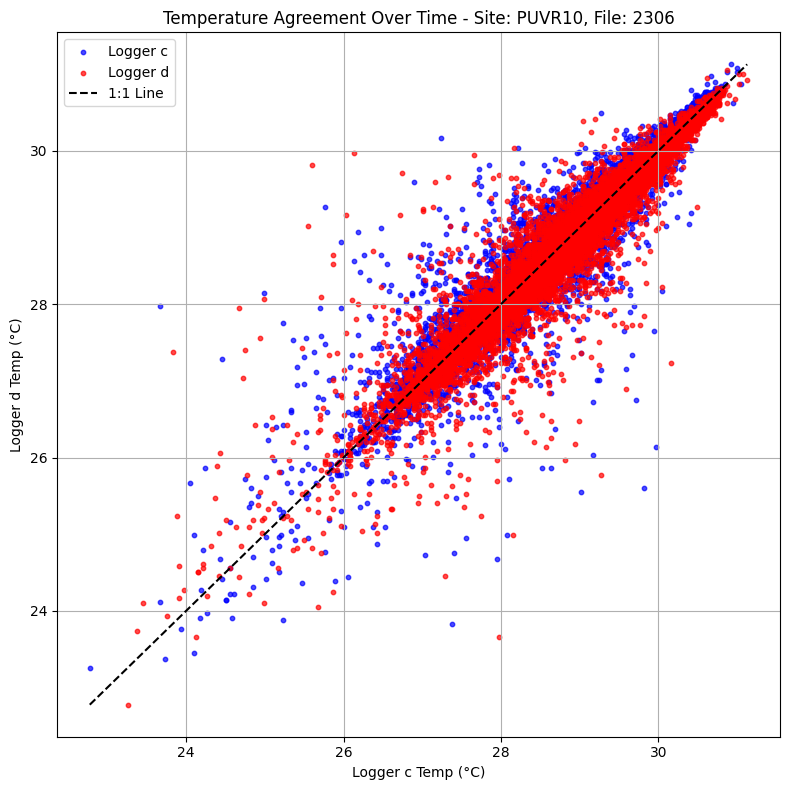

Site: PUVR20, File Number: 2306
  Blue points above 1:1 line: 16705
  Blue points below 1:1 line: 11225
  Red points above 1:1 line: 11225
  Red points below 1:1 line: 16705


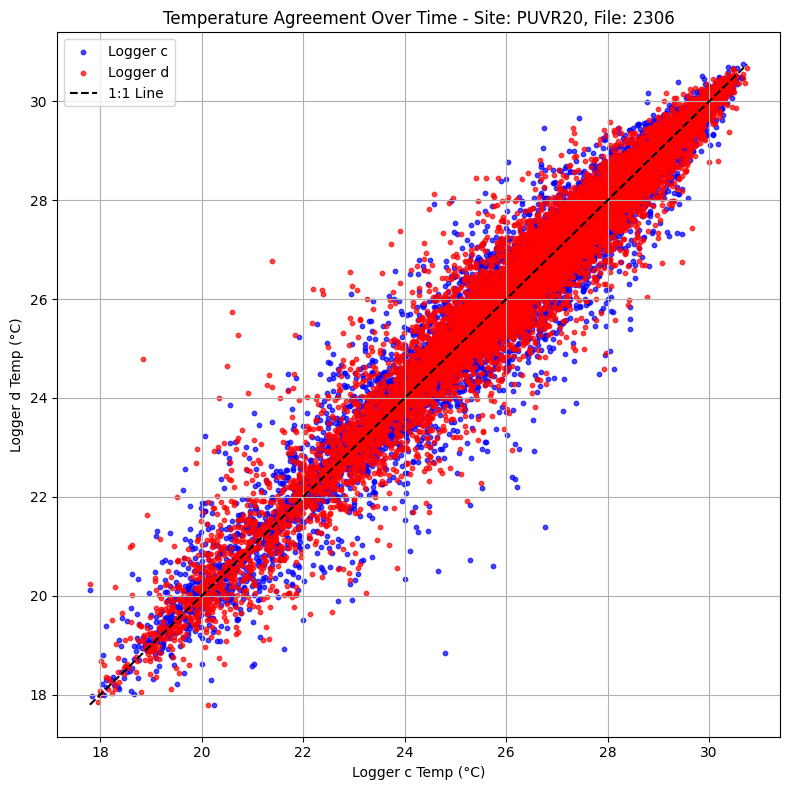

Site: PUVR30, File Number: 2306
  Blue points above 1:1 line: 14184
  Blue points below 1:1 line: 15001
  Red points above 1:1 line: 15001
  Red points below 1:1 line: 14184


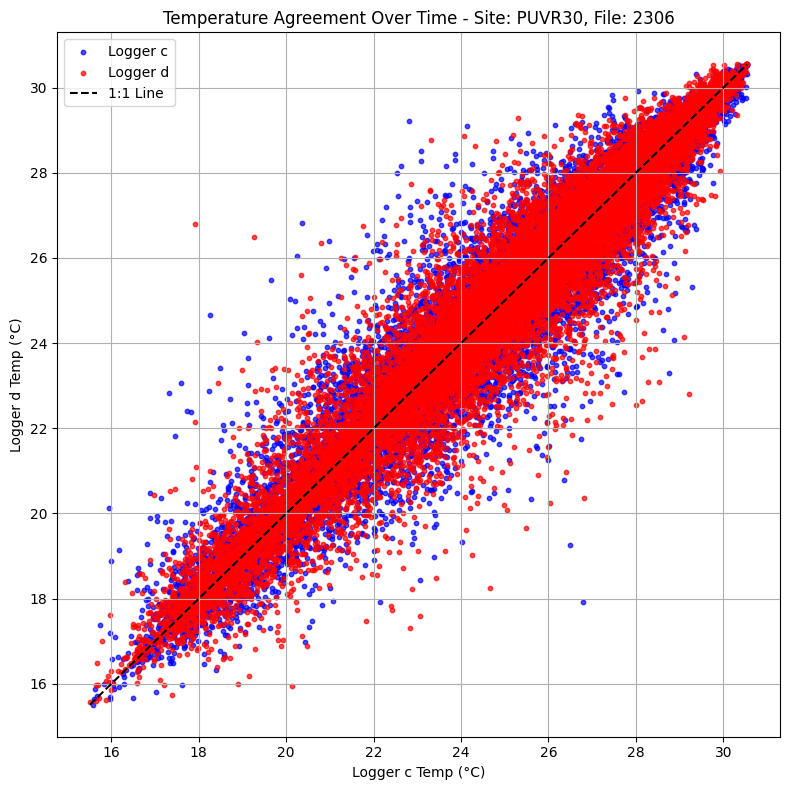

In [79]:
# Create a deep copy of df_files to avoid modifying the original data
offset_compare = copy.deepcopy(df_files)

# Loop through offset_compare dictionary
for site_code, site_data in offset_compare.items():
    # Determine the correct date column based on whether the site is in Panama codes
    if site_code in panama_codes:
        date_col = 'Date Time, GMT-05:00'
    else:
        date_col = 'Date Time, GMT-04:00'

    for file_number, file_data in site_data.items():
        df_c = None
        df_d = None

        # Extract c and d dataframes
        for file_identifier, file_info in file_data.items():
            df = file_info['DataFrame']
            df[date_col] = pd.to_datetime(df[date_col])  # Use dynamic date column

            if file_identifier == 'c':
                df_c = df
            elif file_identifier == 'd':
                df_d = df

        if df_c is not None and df_d is not None:
            # Trim to shortest length
            min_len = min(len(df_c), len(df_d))
            temp_c = df_c['Temp, °C'].iloc[:min_len].reset_index(drop=True)
            temp_d = df_d['Temp, °C'].iloc[:min_len].reset_index(drop=True)
            time = df_c[date_col].iloc[:min_len].reset_index(drop=True)

            # Initialize counters for points above and below the 1:1 line
            blue_above = 0
            blue_below = 0
            red_above = 0
            red_below = 0

            # Loop through the points and compare with the 1:1 line
            for c_temp, d_temp in zip(temp_c, temp_d):
                if c_temp > d_temp:  # Blue point above 1:1 line
                    blue_above += 1
                elif c_temp < d_temp:  # Blue point below 1:1 line
                    blue_below += 1
                
                if d_temp > c_temp:  # Red point above 1:1 line
                    red_above += 1
                elif d_temp < c_temp:  # Red point below 1:1 line
                    red_below += 1

            # Print the counts
            print(f"Site: {site_code}, File Number: {file_number}")
            print(f"  Blue points above 1:1 line: {blue_above}")
            print(f"  Blue points below 1:1 line: {blue_below}")
            print(f"  Red points above 1:1 line: {red_above}")
            print(f"  Red points below 1:1 line: {red_below}")

            # Create scatter plot
            plt.figure(figsize=(8, 8))

            # Scatter plot for logger 'c' in blue
            plt.scatter(temp_c, temp_d, c='blue', s=10, alpha=0.7, label='Logger c')

            # Scatter plot for logger 'd' in red
            plt.scatter(temp_d, temp_c, c='red', s=10, alpha=0.7, label='Logger d')

            # Add 1:1 reference line
            min_temp = min(temp_c.min(), temp_d.min())
            max_temp = max(temp_c.max(), temp_d.max())
            plt.plot([min_temp, max_temp], [min_temp, max_temp], color='black', linestyle='--', label='1:1 Line')

            # Labels and title
            plt.xlabel('Logger c Temp (°C)')
            plt.ylabel('Logger d Temp (°C)')
            plt.title(f'Temperature Agreement Over Time - Site: {site_code}, File: {file_number}')
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

## Merged File Plotting:
This cell loops through the merged offset files dictionary and plots them.

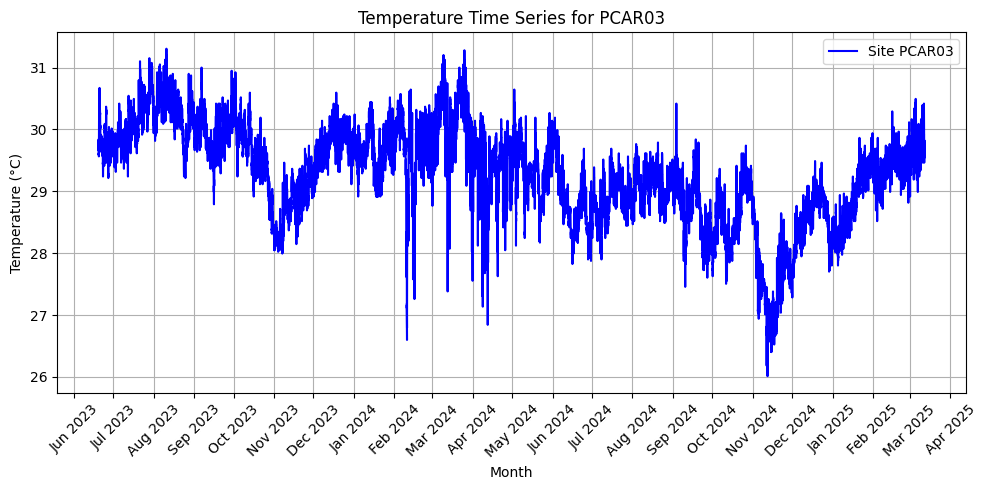

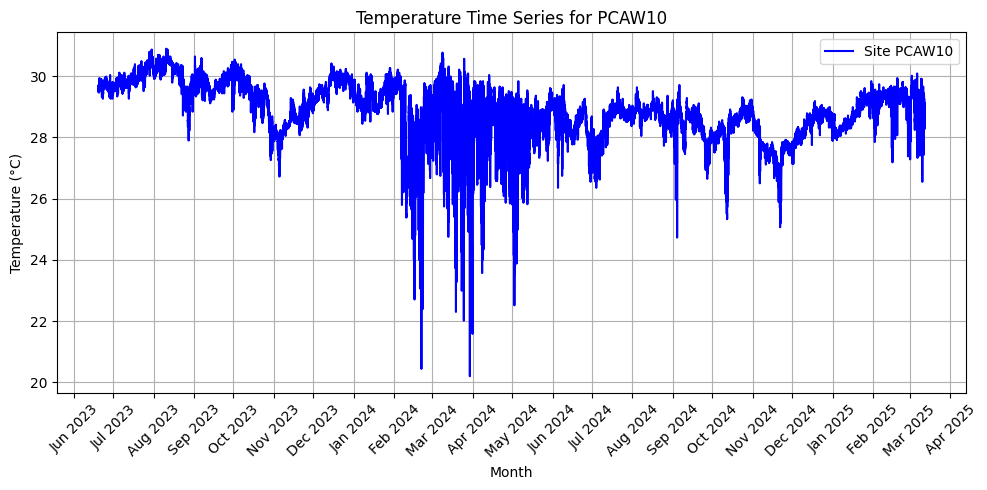

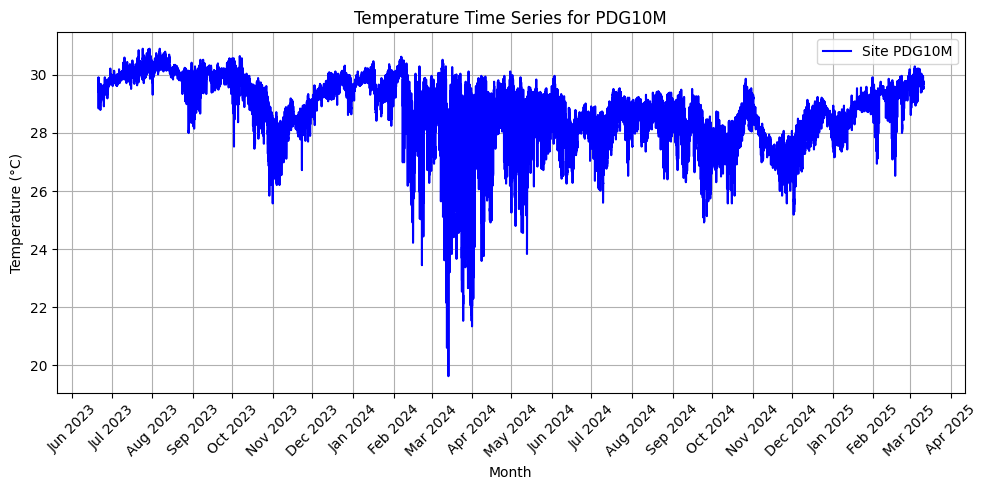

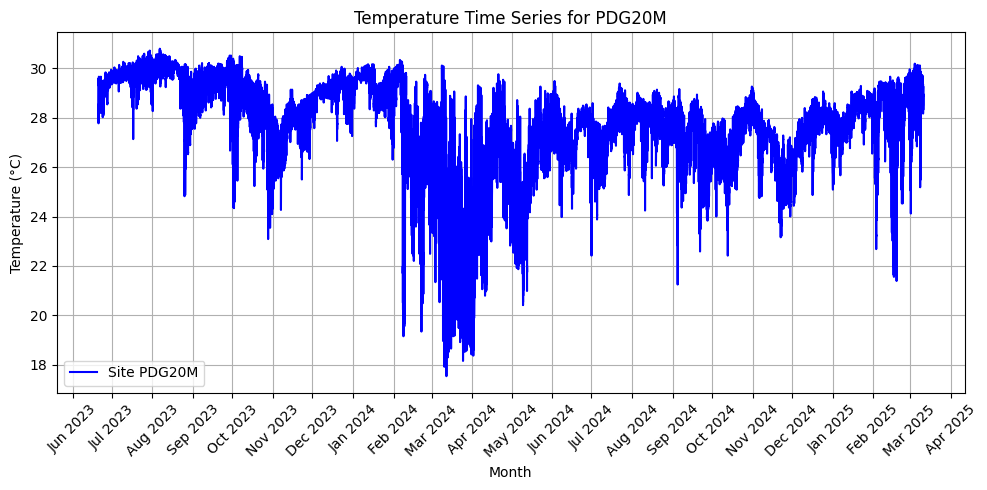

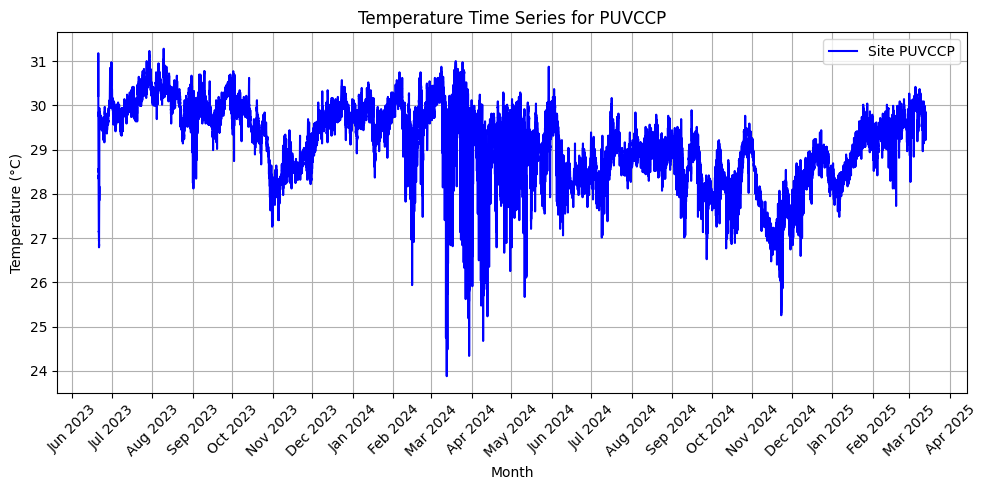

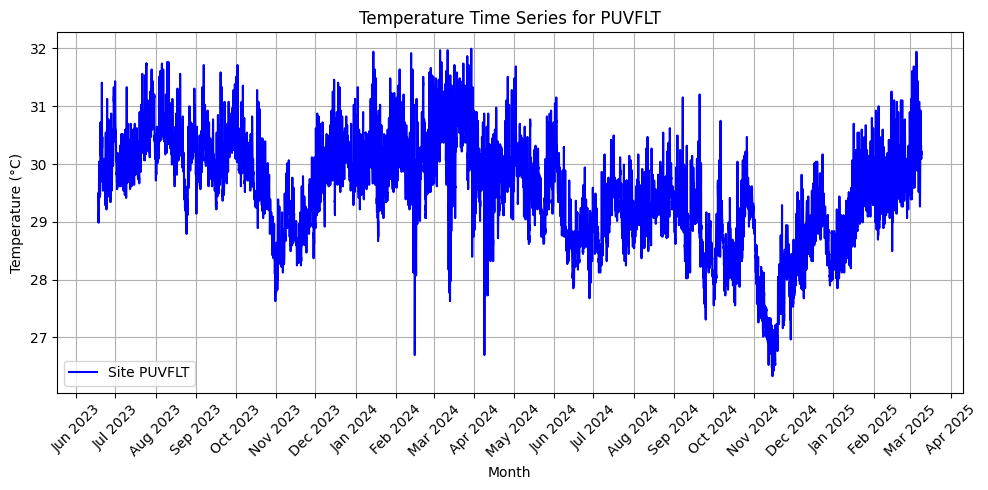

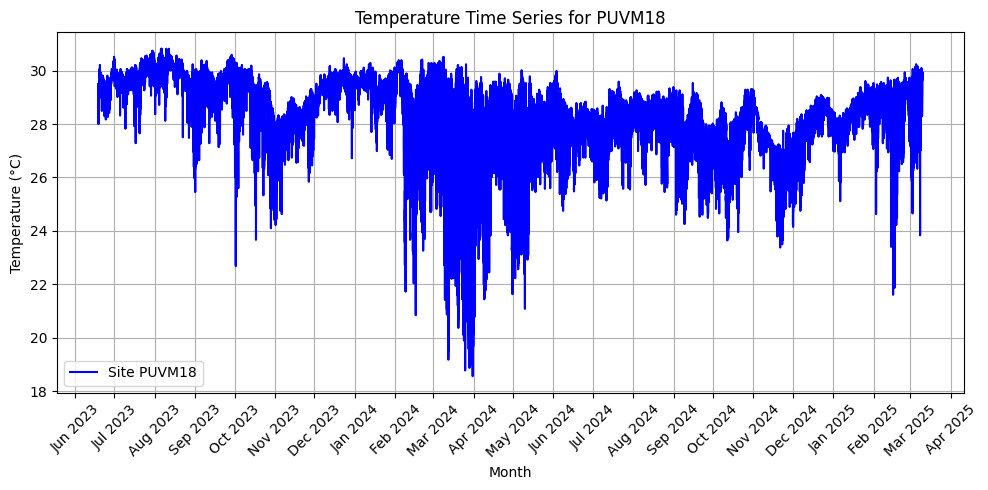

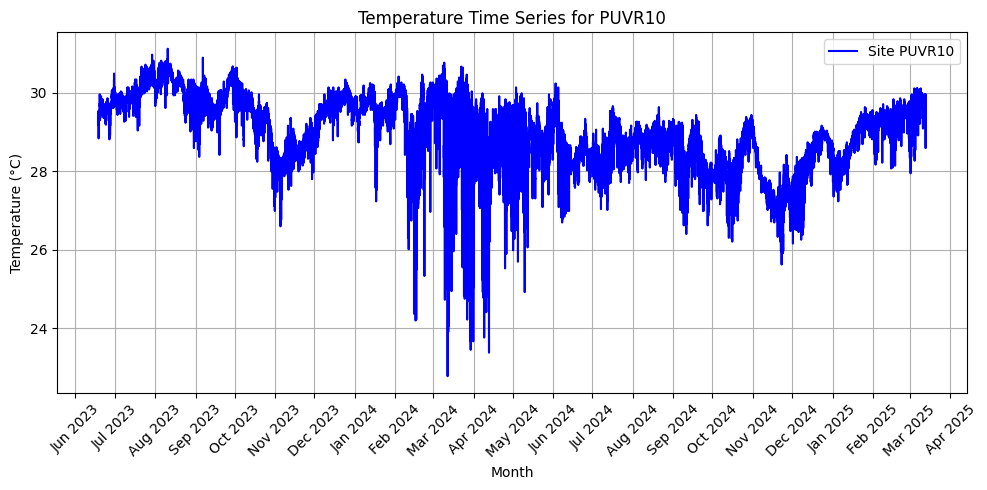

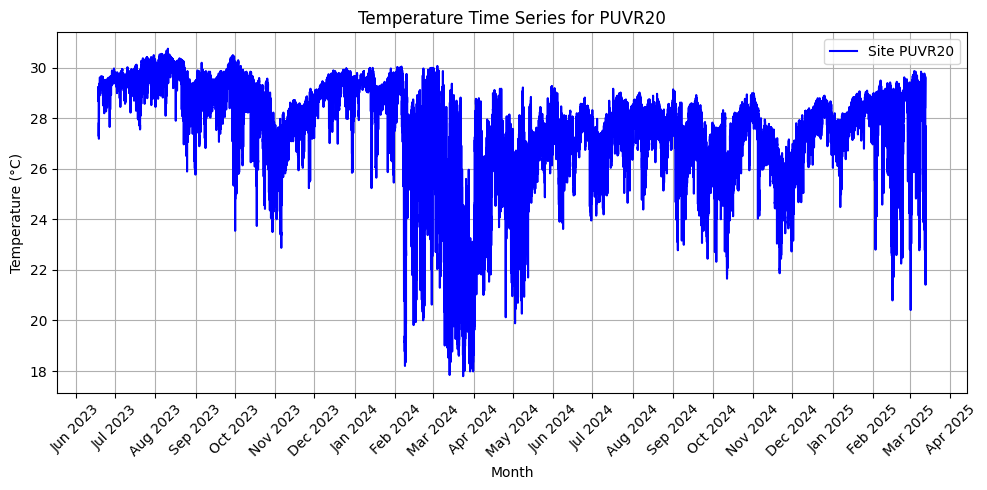

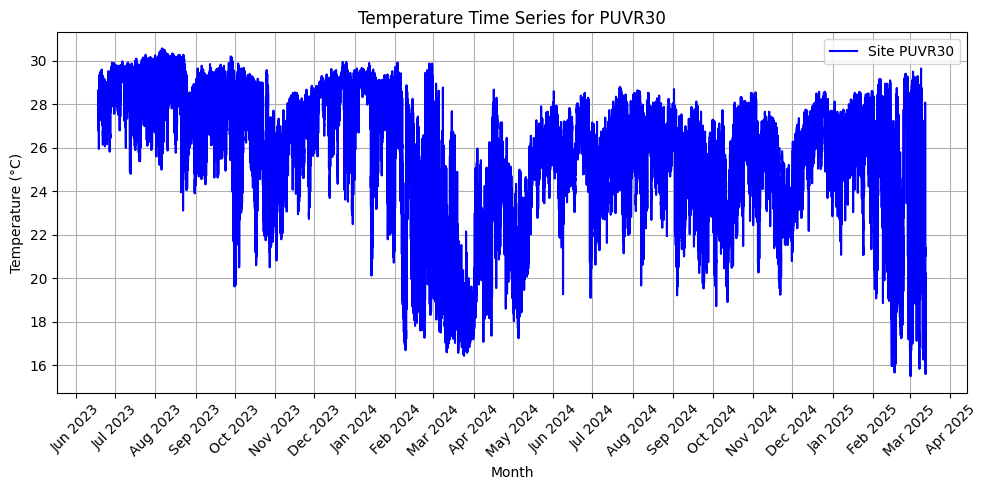

In [80]:
# Loop through each site in merged_dict
for site_code, merged_df in merged_dict.items():
    # Determine the correct date column based on whether the site is in Panama codes
    if site_code in panama_codes:
        date_col = 'Date Time, GMT-05:00'
    else:
        date_col = 'Date Time, GMT-04:00'
    
    # Convert the Date column to datetime format
    merged_df[date_col] = pd.to_datetime(merged_df[date_col])
    
    # Create the plot
    plt.figure(figsize=(10, 5))
    plt.plot(merged_df[date_col], merged_df['Temp, °C'], label=f'Site {site_code}', color='b')
    
    # Formatting
    plt.xlabel('Month')
    plt.ylabel('Temperature (°C)')
    plt.title(f'Temperature Time Series for {site_code}')
    plt.xticks(rotation=45)
    
    # Set x-axis to show month ticks
    plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())  # Show month ticks
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))  # Format as "Jan 2024"
    
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Show or save the plot
    plt.show()  # Change to plt.savefig(f"{site_code}_temp_plot.png") to save

### Individual start and end time checks:
This cell reports the start and end times from the dataframe and deployment metadata for a single file. <b>This is just to check individual files.

In [55]:
# %% Individual start time end time checks 
print("DataFrame Start Time:", df_files['TCBKIT']['2310']['a']['DataFrame']['Date Time, GMT-04:00'].iloc[0])
print("Deployment Data Start Time:", deployment_data_dict['BT_TCBKIT_2310_']['Date In Time In'])

# Print end time
print("DataFrame End Time:", df_files['TCBKIT']['2310']['a']['DataFrame']['Date Time, GMT-04:00'].iloc[-1])
print("Deployment Data End Time:", deployment_data_dict['BT_TCBKIT_2310_']['Date Out Time Out'])

# Then, check if the extracted timestamps match the expected start and end times.

KeyError: '2310'

### Start end time check loop:
To see every start and end time from the dataframe and deployment metadata, run this cell. This allows you to see the listed start and end times as displaced in the deployment log vs the now editied start and edn times in the file.

In [81]:
# %% Loop for start time end time checks
# List to store the names of empty DataFrames
empty_dataframes = []

# Loop through each site code, file number, and file identifier in df_files
for site_code, site_data in df_files.items():
    for file_number, file_data in site_data.items():
        for file_identifier, file_info in file_data.items():
            # Get the DataFrame for the current file
            df = file_info['DataFrame']
            
            # Determine the correct date column based on the time zone for the site
            if site_code in panama_codes:
                date_col = 'Date Time, GMT-05:00'
            else:
                date_col = 'Date Time, GMT-04:00'
            
            if not df.empty:  # Check if the DataFrame is not empty
                # Print the start and end times for the current DataFrame
                print(f"DataFrame Start Time ({site_code}_{file_number}_{file_identifier}):", df[date_col].iloc[0])
                print(f"DataFrame End Time ({site_code}_{file_number}_{file_identifier}):", df[date_col].iloc[-1])

                # Get the corresponding offloaded file name
                offloaded_file_name = file_info['File Name']
                
                # Retrieve deployment data using the offloaded file name
                deployment_data = deployment_data_dict.get(offloaded_file_name)
                
                if deployment_data:
                    # Print the start and end times from deployment data
                    print(f"Deployment Data Start Time ({offloaded_file_name}):", deployment_data['Date In Time In'])
                    print(f"Deployment Data End Time ({offloaded_file_name}):", deployment_data['Date Out Time Out'])
                else:
                    print(f"No deployment data found for {offloaded_file_name}")

                print()  # Add an empty line for better readability
            else:
                # If DataFrame is empty, append its name to the list
                empty_dataframes.append(f"{site_code}_{file_number}_{file_identifier}")

# Print names of empty DataFrames
if empty_dataframes:
    print("Names of empty DataFrames:")
    for name in empty_dataframes:
        print(name)
else:
    print("No empty DataFrames found.")

DataFrame Start Time (PAUVGC_2306_a): 2023-06-17 13:00:00
DataFrame End Time (PAUVGC_2306_a): 2025-03-09 08:30:00
Deployment Data Start Time (BT_PAUVGC_2306_a): 2023-06-17 11:00:00
Deployment Data End Time (BT_PAUVGC_2306_a): 2025-03-09 11:20:00

DataFrame Start Time (PCAR03_2306_c): 2023-06-19 13:30:00
DataFrame End Time (PCAR03_2306_c): 2025-03-12 10:30:00
Deployment Data Start Time (BT_PCAR03_2306_a): 2023-06-19 11:30:00
Deployment Data End Time (BT_PCAR03_2306_a): 2025-03-12 13:00:00

DataFrame Start Time (PCAR03_2306_d): 2023-06-19 13:45:00
DataFrame End Time (PCAR03_2306_d): 2025-03-12 10:15:00
Deployment Data Start Time (BT_PCAR03_2306_b): 2023-06-19 11:30:00
Deployment Data End Time (BT_PCAR03_2306_b): 2025-03-12 13:00:00

DataFrame Start Time (PCAW10_2306_c): 2023-06-19 16:00:00
DataFrame End Time (PCAW10_2306_c): 2025-03-12 09:00:00
Deployment Data Start Time (BT_PCAW10_2306_a): 2023-06-19 14:00:00
Deployment Data End Time (BT_PCAW10_2306_a): 2025-03-12 11:35:00

DataFrame St

## <u>Trimmed file dates </u>
This loop iterates through the .csv files for each site and reports the first and last sample dates. This will make it easier to report the trimmed file dates in the metadata and deployment log as the code names for the files are based on their trimmed dates, making the metadata inconsistent for several files. <b>The days are also included as the day is needed for the DATASET files for the metadata part of the SOP.

In [82]:
# Iterate through df_files to extract and save the "a" version of the files
for site_code, site_data in df_files.items():
    for file_number, file_data in site_data.items():
        if 'a' in file_data:  # Check if "a" version exists for the file
            # Extract the DataFrame for the "a" version
            df_a = file_data['a']['DataFrame']
            
            # Determine the correct date column based on the time zone for the site
            if site_code in panama_codes:
                date_col = 'Date Time, GMT-05:00'
            else:
                date_col = 'Date Time, GMT-04:00'
            
            # Convert the 'Date Time' column to datetime, based on the correct timezone
            df_a[date_col] = pd.to_datetime(df_a[date_col])
            
            # Get the year and month of the first and last data points
            first_data_point = df_a[date_col].iloc[0]
            last_data_point = df_a[date_col].iloc[-1]
            year_month_first = first_data_point.strftime("%y %m %d")  # Using last two digits of the year
            year_month_last = last_data_point.strftime("%y %m %d")    # Using last two digits of the year
            
            # Construct the base file name
            base_file_name = f"BT_{site_code}_{year_month_first}_{year_month_last}"
            
            # Check if the file is identified as a calculation file
            if (site_code, file_number) in calculations:
                output_file_name = f"{base_file_name}_calculations.csv"
            else:
                output_file_name = f"{base_file_name}.csv"
            
            print(f"Saving file: {output_file_name}")
            # Code to save the DataFrame, e.g. df_a.to_csv(output_file_name)

# Iterate through merged_dict to extract and save the DataFrames
for site_code, df in merged_dict.items():  # 'df' is directly the merged DataFrame
    # Determine the correct date column based on the time zone for the site
    if site_code in panama_codes:
        date_col = 'Date Time, GMT-05:00'
    else:
        date_col = 'Date Time, GMT-04:00'
    
    # Convert the 'Date Time' column to datetime, based on the correct timezone
    df[date_col] = pd.to_datetime(df[date_col])
    
    # Get the year and month of the first and last data points
    first_data_point = df[date_col].iloc[0]
    last_data_point = df[date_col].iloc[-1]
    year_month_first = first_data_point.strftime("%y %m %d")  # Using last two digits of the year
    year_month_last = last_data_point.strftime("%y %m %d")    # Using last two digits of the year
    
    # Construct the base file name
    base_file_name = f"BT_{site_code}_{year_month_first}_{year_month_last}"
    
    # Print the output file name (or save it accordingly)
    print(f"Saving file: {base_file_name}.csv")

Saving file: BT_PAUVGC_23 06 17_25 03 09.csv
Saving file: BT_PCO3M_23 06 15_24 09 07.csv
Saving file: BT_PCT18M_23 06 19_25 03 12.csv
Saving file: BT_PIG10M_23 06 21_24 09 13.csv
Saving file: BT_PIG20M_23 06 21_24 09 13.csv
Saving file: BT_PSA11M_23 06 15_24 09 07.csv
Saving file: BT_PSA3M_23 06 15_24 09 07.csv
Saving file: BT_PUVF10_23 06 18_25 03 10.csv
Saving file: BT_PCAR03_23 06 19_25 03 12.csv
Saving file: BT_PCAW10_23 06 19_25 03 12.csv
Saving file: BT_PDG10M_23 06 20_25 03 11.csv
Saving file: BT_PDG20M_23 06 20_25 03 11.csv
Saving file: BT_PUVCCP_23 06 20_25 03 13.csv
Saving file: BT_PUVFLT_23 06 17_25 03 09.csv
Saving file: BT_PUVM18_23 06 18_25 03 10.csv
Saving file: BT_PUVR10_23 06 18_25 03 13.csv
Saving file: BT_PUVR20_23 06 18_25 03 13.csv
Saving file: BT_PUVR30_23 06 18_25 03 13.csv


## <b>Step 2 and 3. Offload data and file naming conventions

### Setting output folder and exporting the .csv files:
This cell defines the output folder, creating the folder if not existing previously, then runs a loop, first checking for the a version of the file and then extracting that data frame to export the .csv files by the naming convention set in the SOP as BT_site_code_year_month_first_year_month_last. Inside the loop also checks if the file was identified as "calculations", if so then adds "_calculations.csv" as is the naming convention set for them in the SOP. Internal calculations offloads the files that have the temperature columns averaged and empty cells to show the number of instances where there was a difference >0.2 and will not be uploaded to the drive.
<li><u>Make sure to update the folder path in the cell!</u>

In [83]:
print(file_data['a']['DataFrame'])

KeyError: 'a'

In [84]:
# Define the output folder where you want to save the extracted files
output_folder = r"C:\UVI\QAQC stuff\Temp_Panama_2025_output"

# Define the internal calculations folder within the output folder
internal_calculations_folder = os.path.join(output_folder, "internal_calculations")

# Create the calculations folder if it doesn't exist
if not os.path.exists(internal_calculations_folder):
    os.makedirs(internal_calculations_folder)

# Iterate through df_files to extract and save the "a" version of the files
for site_code, site_data in df_files.items():
    for file_number, file_data in site_data.items():
        if 'a' in file_data:  # Check if "a" version exists for the file
            # Extract the DataFrame for the "a" version
            df_a = file_data['a']['DataFrame']
            
            # Determine the correct date column based on the time zone for the site
            if site_code in panama_codes:
                # If it's a Panama site, use GMT-05:00
                date_col = 'Date Time, GMT-05:00'
                new_date_col = 'Date Time, UTC-05:00'
            else:
                # Otherwise, use GMT-04:00
                date_col = 'Date Time, GMT-04:00'
                new_date_col = 'Date Time, UTC-04:00'
            
            # Rename the Average Temperature column
            df_a.rename(columns={'Temp, °C': 'Temperature'}, inplace=True)

            # Check if the date column exists before renaming
            if date_col in df_a.columns:
                df_a.rename(columns={date_col: new_date_col}, inplace=True)
            else:
                print(f"Warning: {date_col} not found in DataFrame for {site_code}. Skipping rename.")

            # Ensure the column is renamed properly
            if new_date_col not in df_a.columns:
                print(f"Error: {new_date_col} column does not exist after renaming for {site_code}.")
                continue  # Skip this file if the rename failed
            
            # Get the year and month of the first and last data points
            first_data_point = df_a[new_date_col].iloc[0]
            last_data_point = df_a[new_date_col].iloc[-1]
            year_month_first = first_data_point.strftime("%y%m")  # Using last two digits of the year
            year_month_last = last_data_point.strftime("%y%m")    # Using last two digits of the year
            
            # Construct the base file name
            base_file_name = f"BT_{site_code}_{year_month_first}_{year_month_last}"
            
            # Check if the file is identified as a calculation file
            if (site_code, file_number) in calculations:
                output_file_name = f"{base_file_name}_internal_calculations.csv"
                output_file_path = os.path.join(internal_calculations_folder, output_file_name)
            else:
                output_file_name = f"{base_file_name}.csv"
                output_file_path = os.path.join(output_folder, output_file_name)
            
            # Save the DataFrame to CSV
            df_a.to_csv(output_file_path, index=False)
            
            print(f"File saved: {output_file_path}")

# Iterate through merged_dict to save merged DataFrames with "_merged" suffix
for site_code, merged_df in merged_dict.items():
    
    # Determine the correct date column based on the time zone for the site
    if site_code in panama_codes:
        # If it's a Panama site, use GMT-05:00
        date_col = 'Date Time, GMT-05:00'
        new_date_col = 'Date Time, UTC-05:00'
    else:
        # Otherwise, use GMT-04:00
        date_col = 'Date Time, GMT-04:00'
        new_date_col = 'Date Time, UTC-04:00'
    
    # Rename the columns for the merged DataFrame
    merged_df.rename(columns={'Temp, °C': 'Temperature'}, inplace=True)

    # Check if the date column exists before renaming
    if date_col in merged_df.columns:
        merged_df.rename(columns={date_col: new_date_col}, inplace=True)
    else:
        print(f"Warning: {date_col} not found in DataFrame for {site_code}. Skipping rename.")
    
    # Ensure the column is renamed properly
    if new_date_col not in merged_df.columns:
        print(f"Error: {new_date_col} column does not exist after renaming for {site_code}.")
        continue  # Skip this file if the rename failed

    # Get the year and month of the first and last data points for merged data
    first_data_point = merged_df[new_date_col].iloc[0]
    last_data_point = merged_df[new_date_col].iloc[-1]
    year_month_first = first_data_point.strftime("%y%m")  # Using last two digits of the year
    year_month_last = last_data_point.strftime("%y%m")    # Using last two digits of the year
    
    # Construct the base file name
    base_file_name = f"BT_{site_code}_{year_month_first}_{year_month_last}_merged"
    
    # Define the output file path
    output_file_name = f"{base_file_name}.csv"
    output_file_path = os.path.join(output_folder, output_file_name)
    
    # Save the merged DataFrame to CSV
    merged_df.to_csv(output_file_path, index=False)
    
    print(f"Merged File saved: {output_file_path}")

File saved: C:\UVI\QAQC stuff\Temp_Panama_2025_output\BT_PAUVGC_2306_2503.csv
File saved: C:\UVI\QAQC stuff\Temp_Panama_2025_output\BT_PCO3M_2306_2409.csv
File saved: C:\UVI\QAQC stuff\Temp_Panama_2025_output\BT_PCT18M_2306_2503.csv
File saved: C:\UVI\QAQC stuff\Temp_Panama_2025_output\BT_PIG10M_2306_2409.csv
File saved: C:\UVI\QAQC stuff\Temp_Panama_2025_output\BT_PIG20M_2306_2409.csv
File saved: C:\UVI\QAQC stuff\Temp_Panama_2025_output\BT_PSA11M_2306_2409.csv
File saved: C:\UVI\QAQC stuff\Temp_Panama_2025_output\BT_PSA3M_2306_2409.csv
File saved: C:\UVI\QAQC stuff\Temp_Panama_2025_output\BT_PUVF10_2306_2503.csv
Merged File saved: C:\UVI\QAQC stuff\Temp_Panama_2025_output\BT_PCAR03_2306_2503_merged.csv
Merged File saved: C:\UVI\QAQC stuff\Temp_Panama_2025_output\BT_PCAW10_2306_2503_merged.csv
Merged File saved: C:\UVI\QAQC stuff\Temp_Panama_2025_output\BT_PDG10M_2306_2503_merged.csv
Merged File saved: C:\UVI\QAQC stuff\Temp_Panama_2025_output\BT_PDG20M_2306_2503_merged.csv
Merged Fil

### Offloading plots:
Code below reads in the newly offloaded csv files, converts the date time, and plots the temperature over time for each .csv file then exports them to a folder.
<li><u>To save the plots, you will need to create a directory (a folder). Make sure to update that folder path in the save_dir = part of the cell!</u>

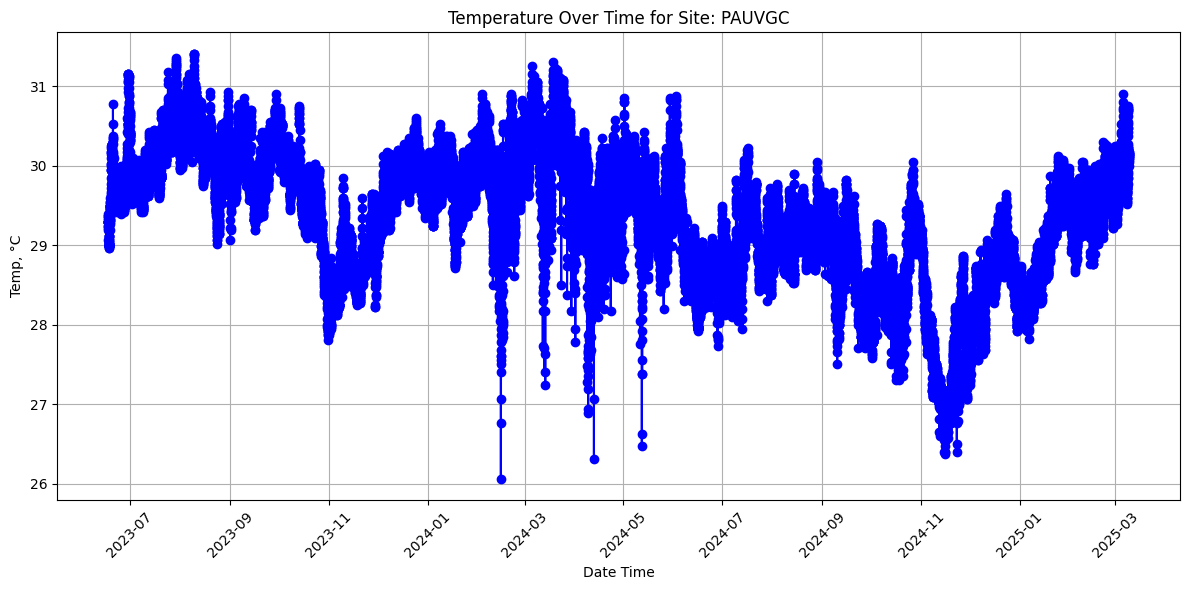

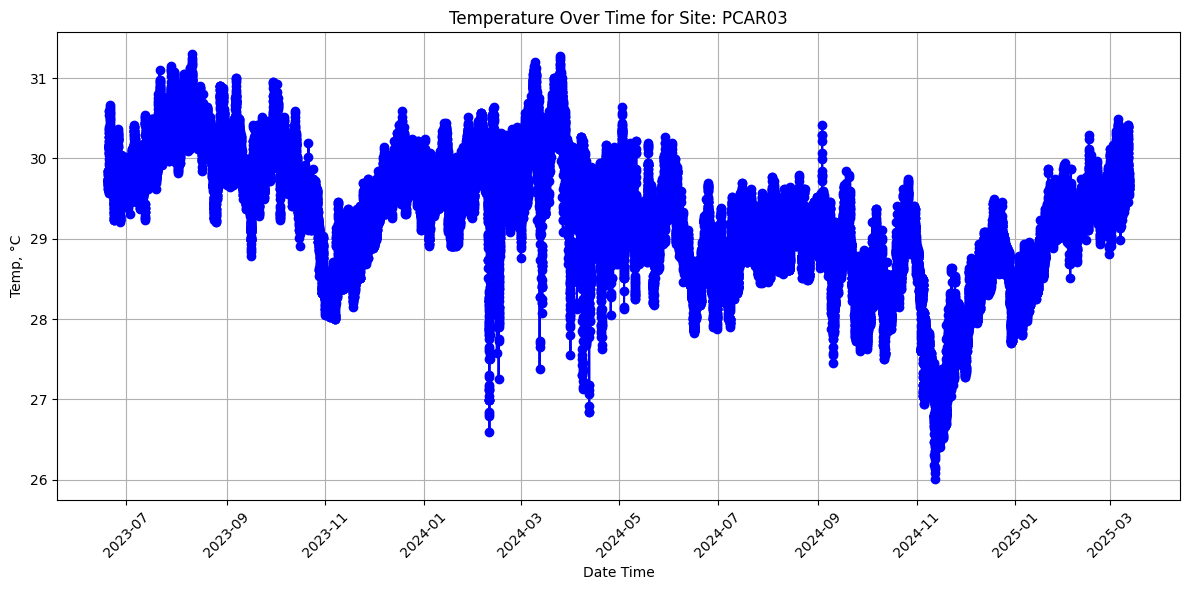

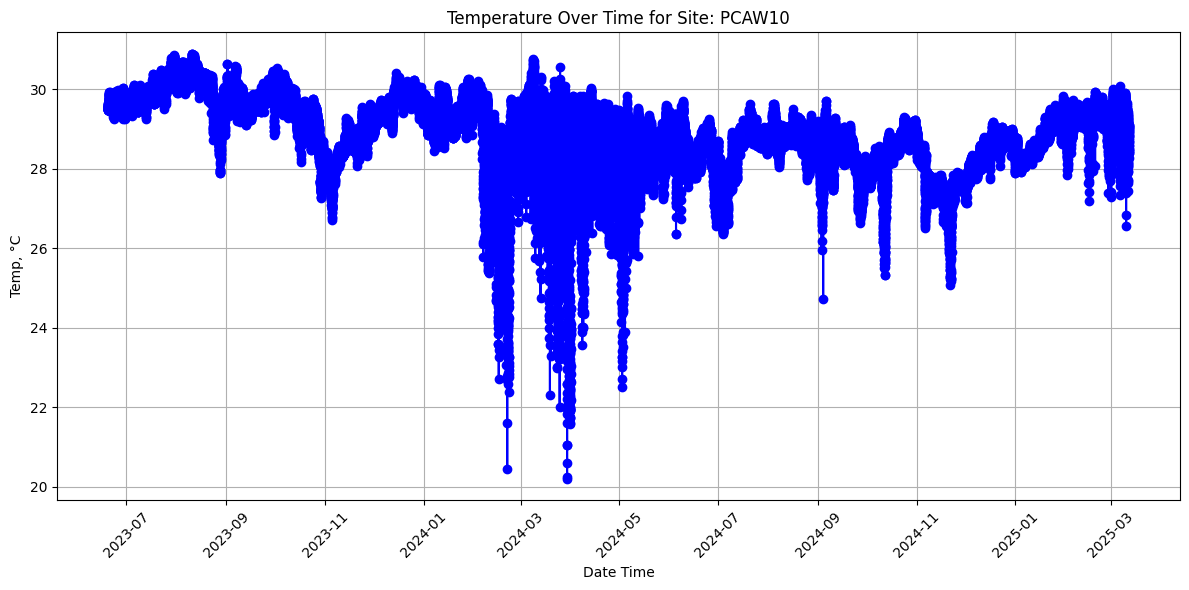

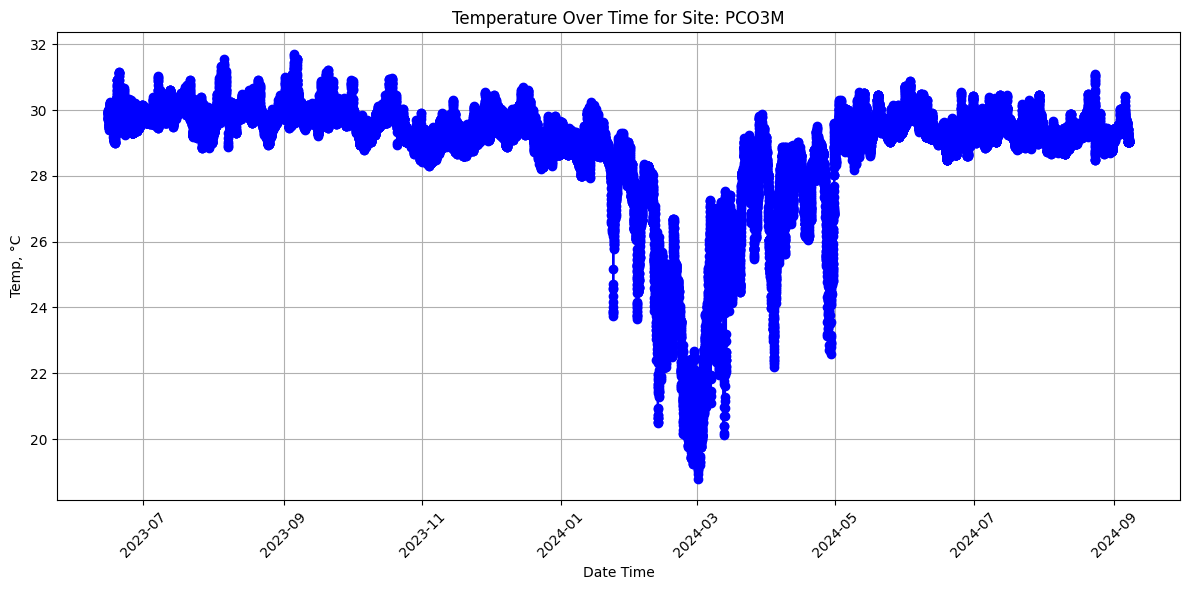

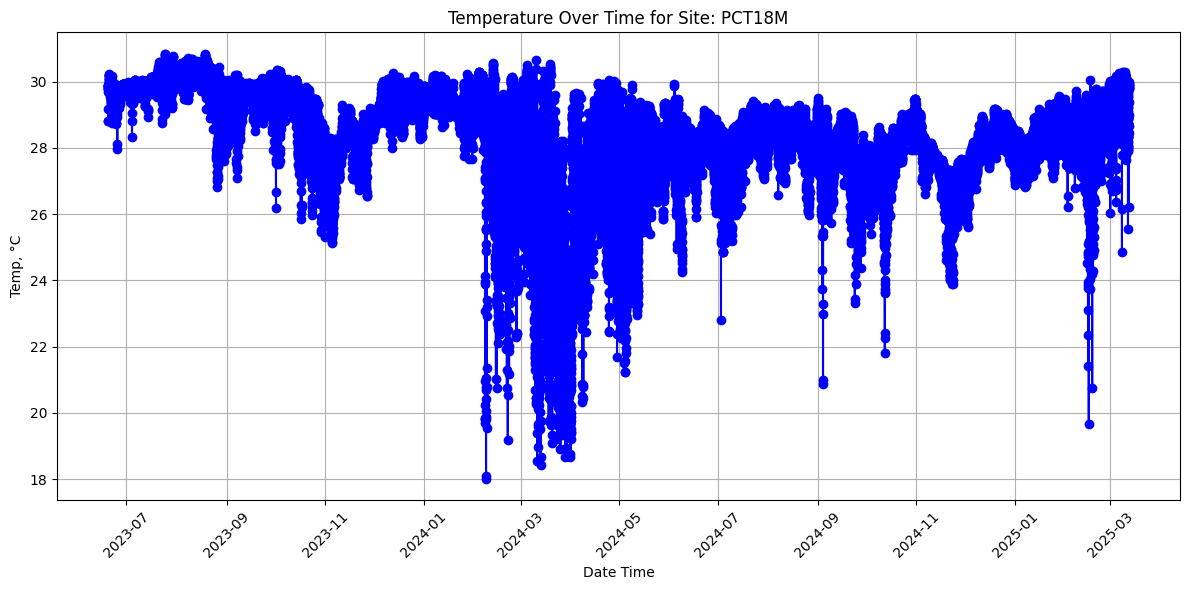

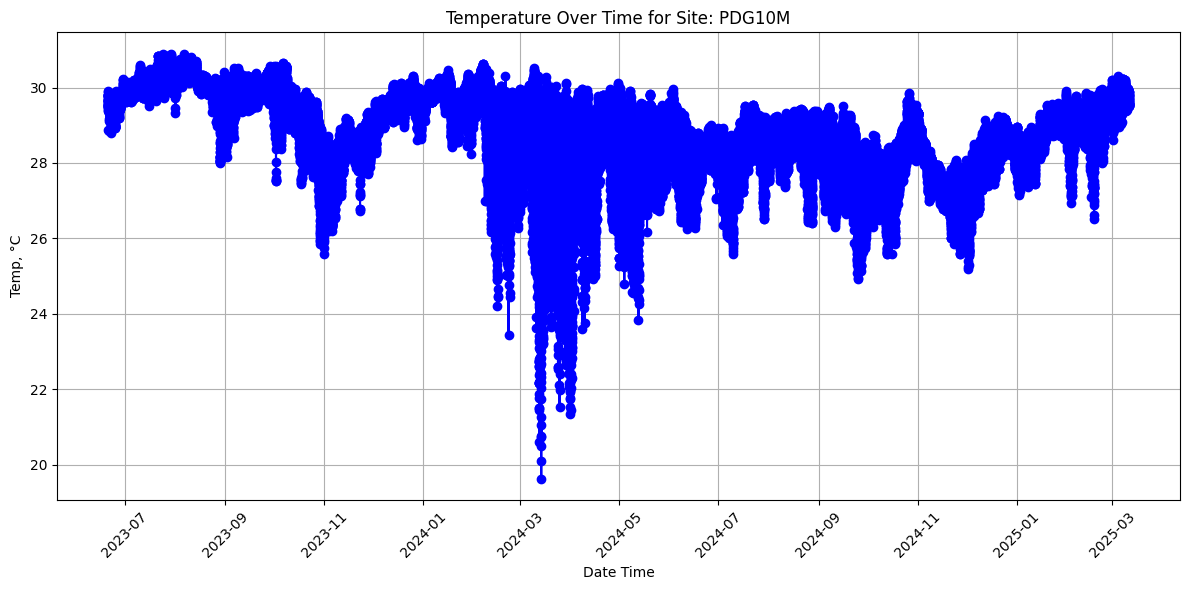

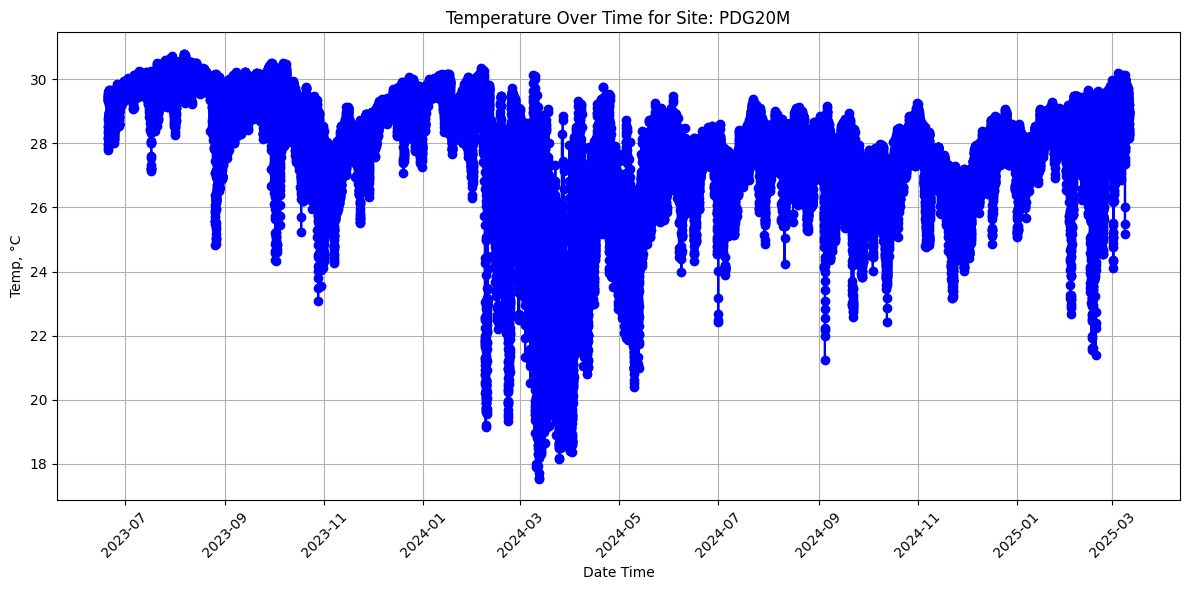

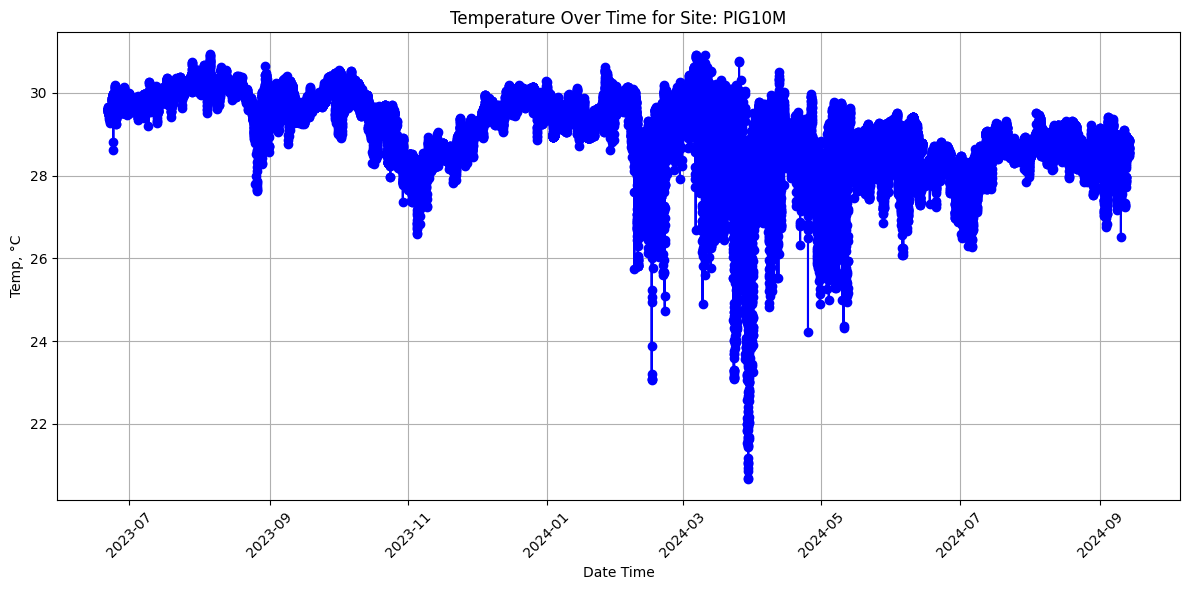

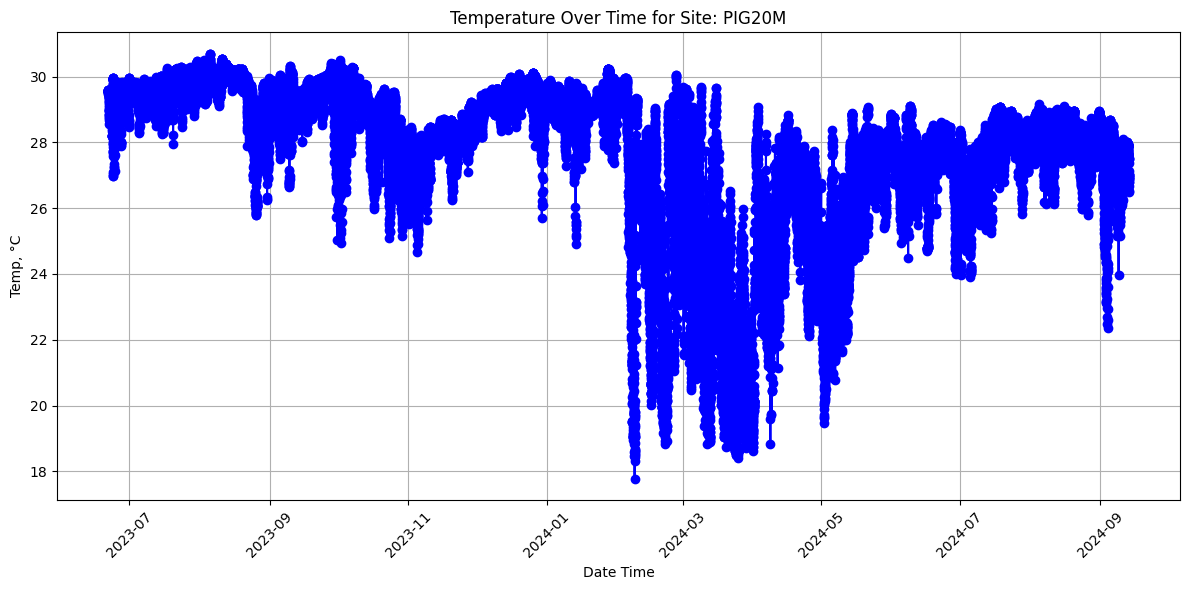

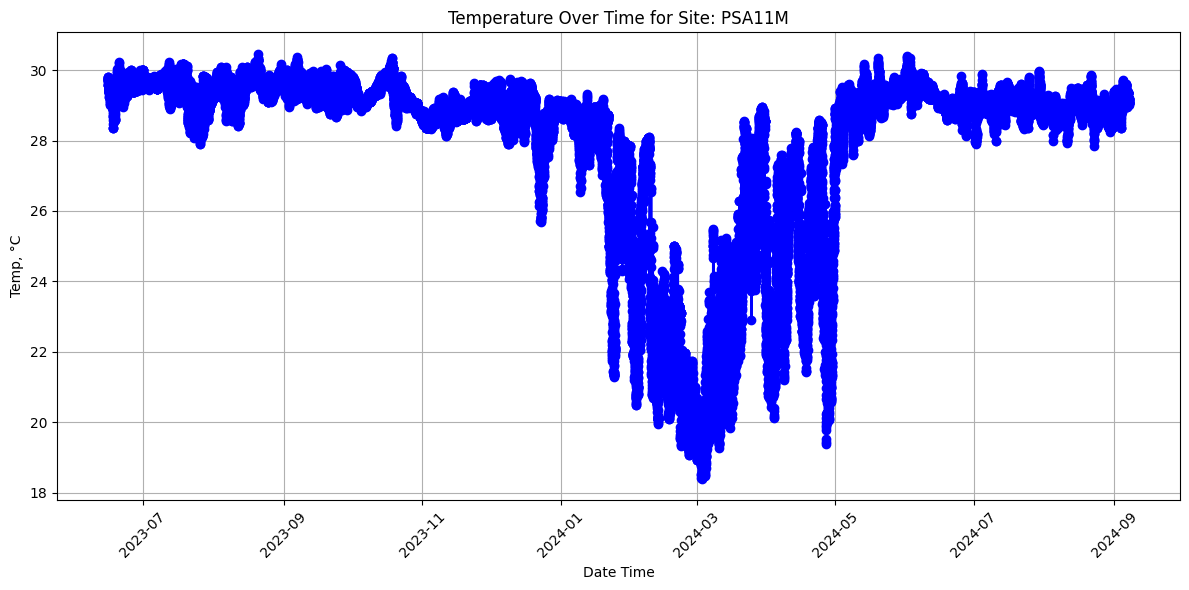

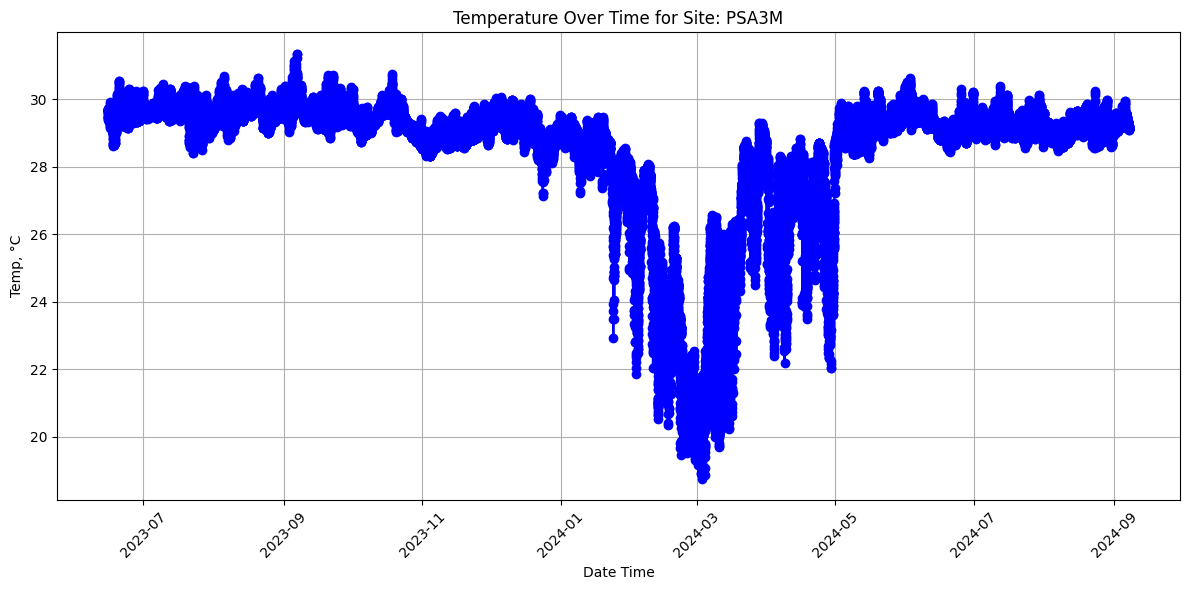

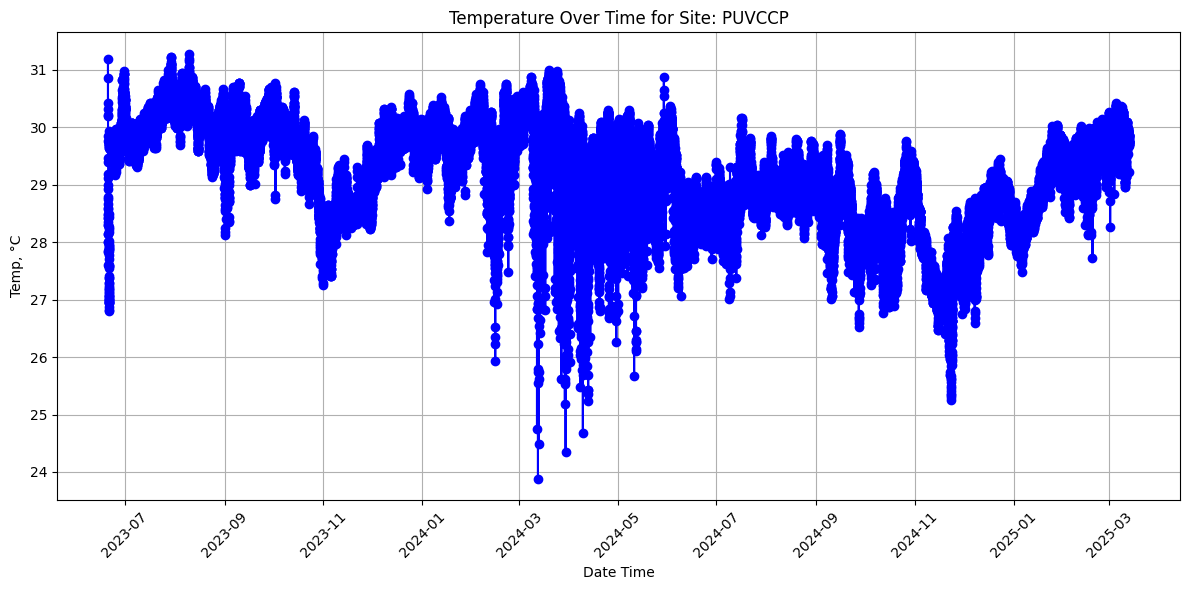

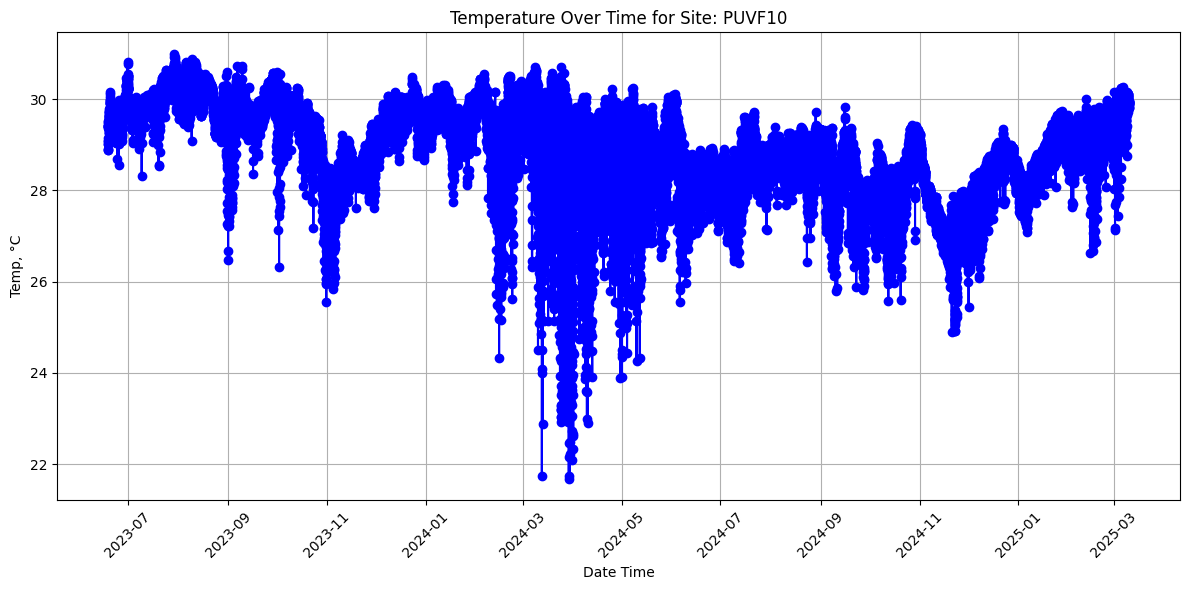

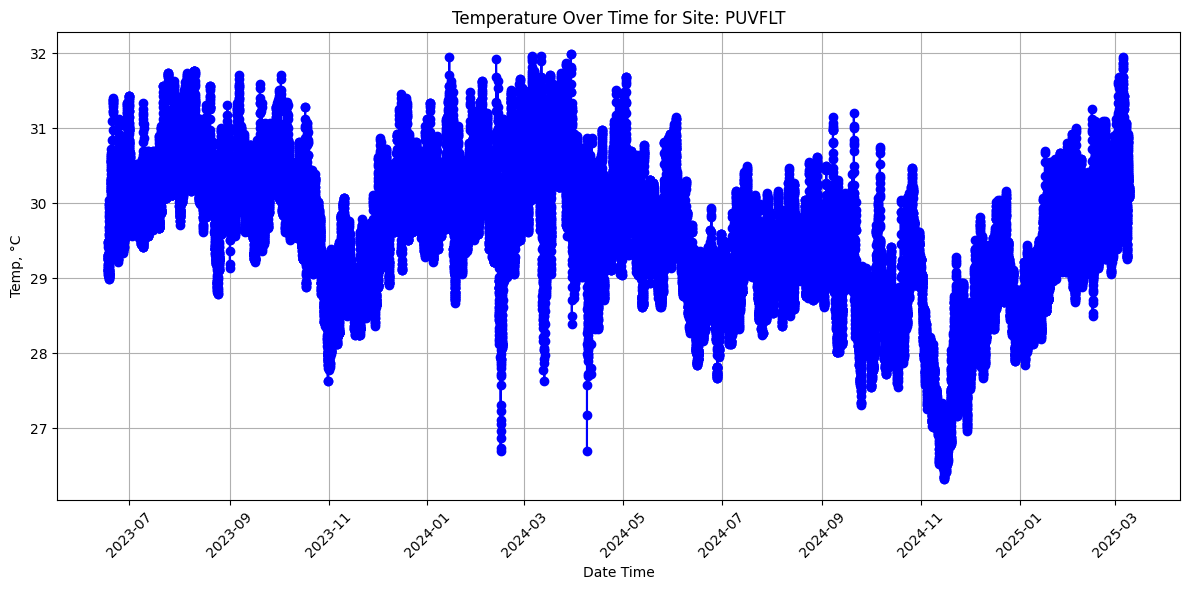

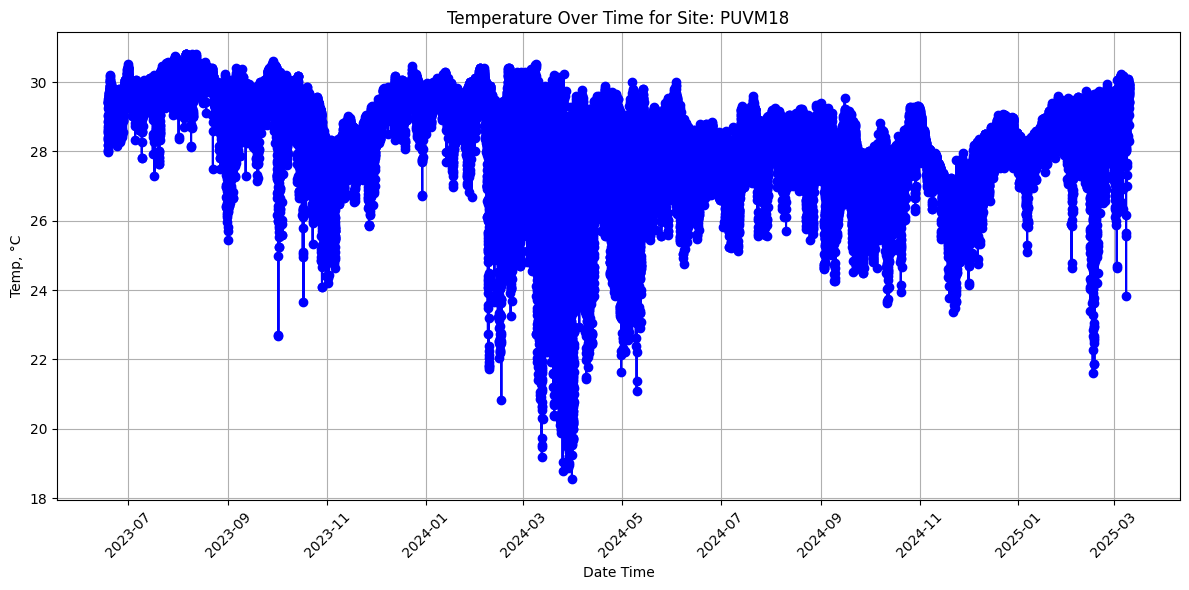

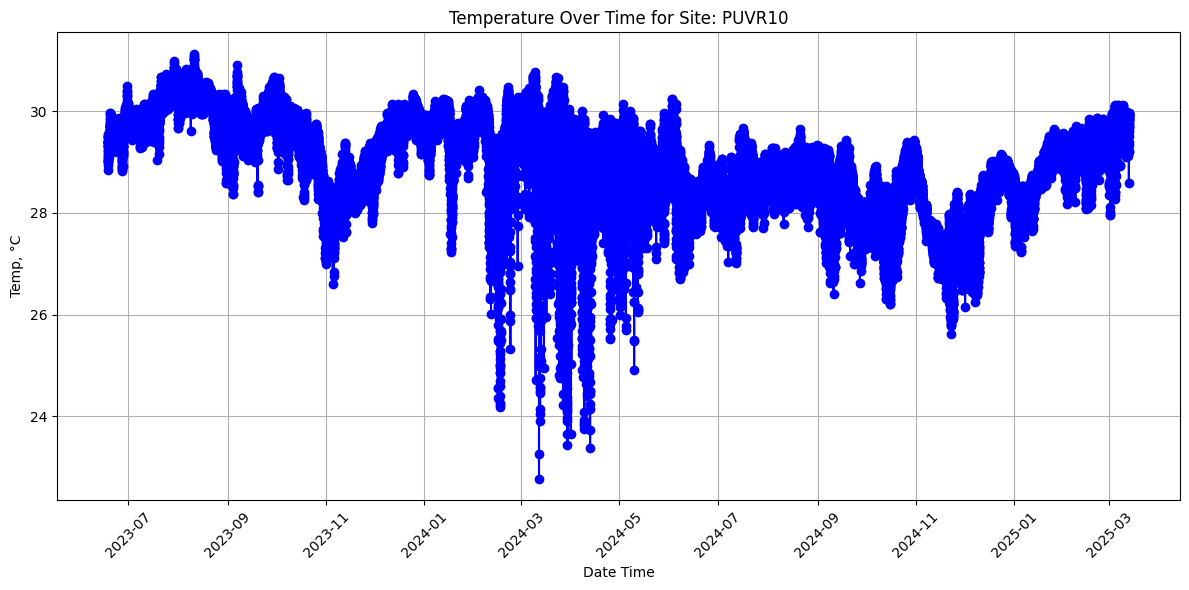

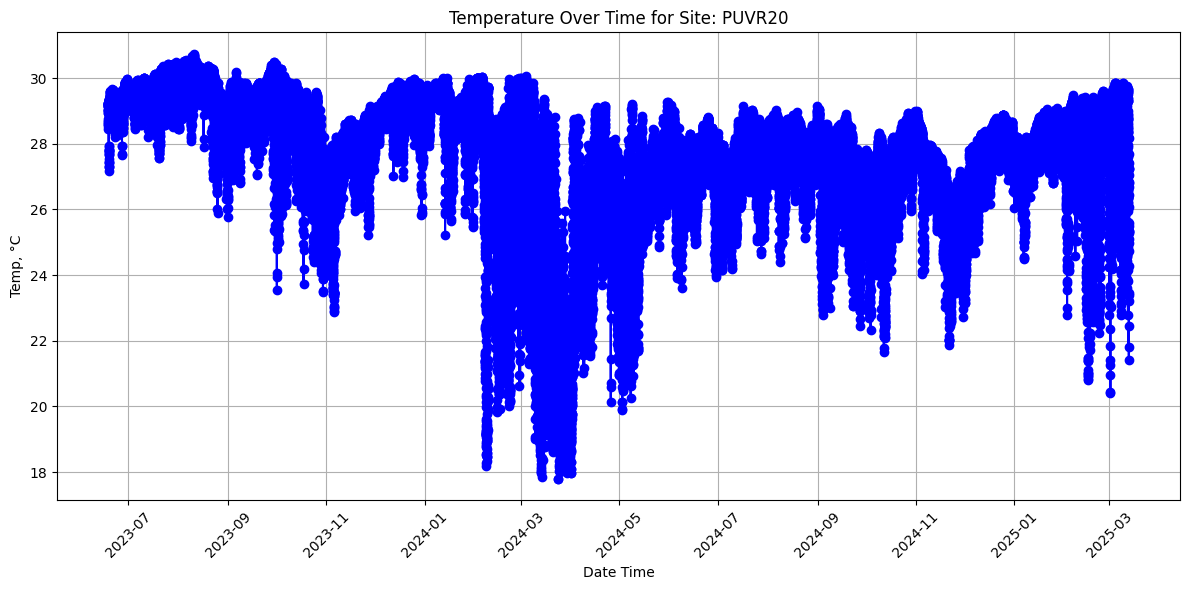

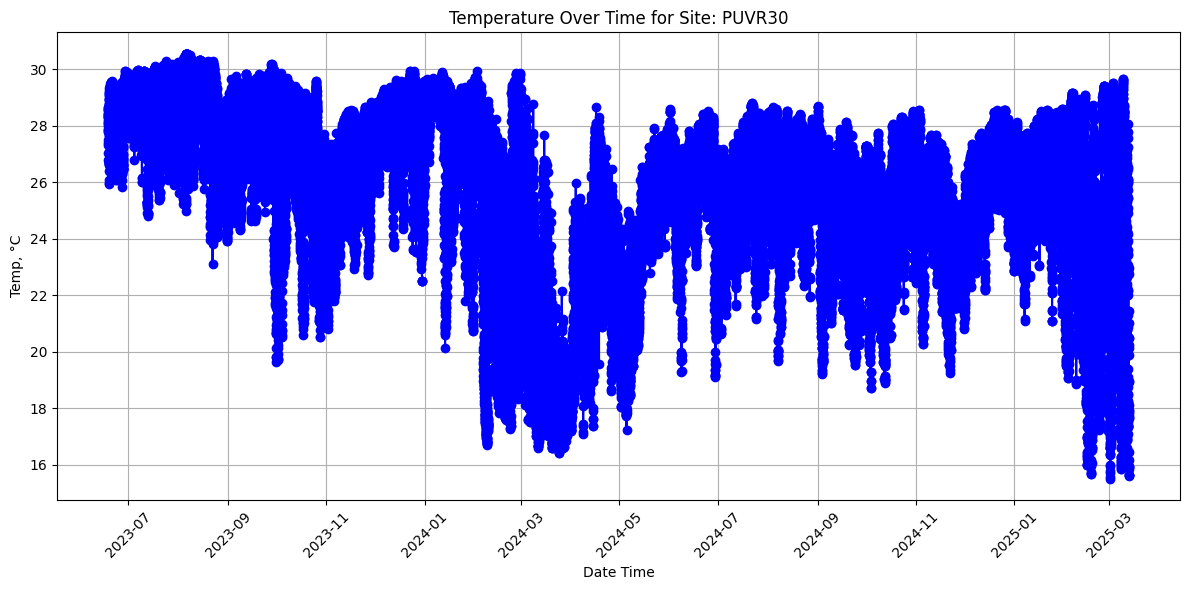

In [85]:
#%% Using new offloaded files create plots and save plots to a folder
 
exported_folder_path = r'C:\UVI\QAQC stuff\Temp_Panama_2025_output'

# Define pattern to match CSV files
file_pattern = '*.csv'

# Use glob to get a list of file paths matching the pattern set in file_pattern
exported_csv_files = glob.glob(exported_folder_path + '/' + file_pattern)

# Loop through each CSV file
for csv_file in exported_csv_files:
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(csv_file)
    
    # Determine the correct date column based on the time zone for the site
    site_code = os.path.basename(csv_file).split('_')[1]  # Assuming site code is in the second part of the file name
    
    if site_code in panama_codes:
        # If it's a Panama site, use UTC-05:00
        date_col = 'Date Time, UTC-05:00'
        new_date_col = 'Date Time, UTC-05:00'
    else:
        # Otherwise, use UTC-04:00
        date_col = 'Date Time, UTC-04:00'
        new_date_col = 'Date Time, UTC-04:00'
    
    # Check if the date column exists before renaming
    if date_col in df.columns:
        df.rename(columns={date_col: new_date_col}, inplace=True)
    else:
        print(f"Warning: {date_col} not found in DataFrame for {site_code}. Skipping rename.")

    # Ensure the column is renamed properly
    if new_date_col not in df.columns:
        print(f"Error: {new_date_col} column does not exist after renaming for {site_code}. Skipping this file.")
        continue  # Skip this file if the rename failed
    
    # Convert the 'Date Time, UTC-05:00' or 'Date Time, UTC-04:00' column to datetime format
    try:
        df[new_date_col] = pd.to_datetime(df[new_date_col], format='%Y-%m-%d %H:%M:%S')
    except Exception as e:
        print(f"Error converting date for {site_code} in file {csv_file}: {e}")
        continue  # Skip this file if the datetime conversion fails

    # Plot the data
    plt.figure(figsize=(12, 6))
    plt.plot(df[new_date_col], df['Temperature'], color='blue', marker='o', linestyle='-')
    plt.title(f'Temperature Over Time for Site: {site_code}')
    plt.xlabel('Date Time')
    plt.ylabel('Temp, °C')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Extract file name from the file path
    file_name = os.path.basename(csv_file)
    
    # Define the file name for the plot
    plot_file_name = os.path.splitext(file_name)[0] + '_plot.png'
    
    save_dir = r"C:\UVI\QAQC stuff\Temp_Panama_2023_output\graphs"
    # Create the directory if it doesn't exist
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    # Save the plot
    plt.savefig(os.path.join(save_dir, plot_file_name))
    
    # Show the plot (optional)
    plt.show()